# TODO
- make sure I understand how prior context is used in these decoding, since there are many possible paths through the task...

In [1]:
from shared.main import * 
from shared.nlp import *

from typing import Dict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# create representations

all character identity specific information (names, pronouns, etc) should be masked out now

In [2]:
from pathlib import Path
import re

XLSX_PATH = Path("social-navigation-task.xlsx")
OUTPUT_PATH = Path("semantic_features_bundle_identity_masked.pkl")

CONTEXTS = (
    "none",
    "previous_slide",
    1,
    2,
    4,
    "all",
)

HISTORY_WINDOWS = (1, 2, 4, "all")

EMBEDDING_MODEL = "openai"
NORMALIZE_EMBEDDINGS = True
OVERWRITE = False
BUNDLE_VERSION = "identity_masked_text_vs_running_mean_v1"

# Add literal names here only if a future task table contains resolved names
# that are not encoded in character_role_name.
EXTRA_IDENTITY_NAMES = ()

# =============================================================================
# IDENTITY MASKING
# =============================================================================

BRACKETED_CHARACTER_PATTERN = re.compile(
    r"\[(?P<content>[^\]]*character[^\]]*)\]",
    flags=re.IGNORECASE,
)

ROLE_PATTERN = r"(?:First|Second|Assistant|Neutral|Newcomb|Hayworth)"
PLACEHOLDER_SUFFIX_PATTERN = (
    r"(?:spouse['’]s\s+name|spouse['’]s\s+pronoun|"
    r"first\s+name|name|objective|pronoun|possessive|"
    r"guy/girl|man/woman|sir/ma['’]am|"
    r"['’]is['’]\s+contraction|['’]will['’]\s+contraction)"
)

MALFORMED_CHARACTER_PATTERN = re.compile(
    rf"(?P<content>\b(?:Mr\./Mrs\.\s+)?{ROLE_PATTERN}\s+character"
    rf"(?:\s+{PLACEHOLDER_SUFFIX_PATTERN})?)\]?",
    flags=re.IGNORECASE,
)

def clean_text(value):
    """Coerce a value to clean, single-spaced text."""
    if not isinstance(value, str):
        return ""
    return " ".join(value.split())

def _generic_placeholder(content):
    """Replace a role-specific placeholder while preserving basic grammar."""
    content = content.lower().replace("’", "'")

    if "spouse's name" in content:
        return "[RELATED_PERSON]"
    if "spouse's pronoun" in content:
        return "they"
    if "'is' contraction" in content:
        return "they're"
    if "'will' contraction" in content:
        return "they'll"
    if "possessive" in content:
        return "their"
    if "objective" in content:
        return "them"
    if "pronoun" in content:
        return "they"
    if "guy/girl" in content or "man/woman" in content:
        return "person"

    return "[CHARACTER]"

def mask_character_identity(text, literal_names=()):
    """
    Remove explicit character identifiers while retaining narrative roles.

    Ordinary role words such as boss, assistant, coworker, friend, and
    landlord are intentionally retained.
    """
    text = clean_text(text)

    text = BRACKETED_CHARACTER_PATTERN.sub(
        lambda match: _generic_placeholder(match.group("content")),
        text,
    )

    text = MALFORMED_CHARACTER_PATTERN.sub(
        lambda match: _generic_placeholder(match.group("content")),
        text,
    )

    for name in sorted(set(literal_names), key=len, reverse=True):
        name = clean_text(name)
        if not name:
            continue

        text = re.sub(
            rf"(?<!\w){re.escape(name)}(?P<possessive>['’]s)(?!\w)",
            lambda match: "[CHARACTER]" + match.group("possessive"),
            text,
            flags=re.IGNORECASE,
        )
        text = re.sub(
            rf"(?<!\w){re.escape(name)}(?!\w)",
            "[CHARACTER]",
            text,
            flags=re.IGNORECASE,
        )

    text = re.sub(
        r"(?:\[CHARACTER\](?:\s+|[,.:;!?-]+\s*)){2,}",
        "[CHARACTER] ",
        text,
    )

    return clean_text(text)

def validate_identity_masking(text_manifest, literal_names=()):
    """Raise an error if explicit identity markers remain."""
    check_text = (
        text_manifest["text"]
        .astype(str)
        .str.replace("[CHARACTER]", "", regex=False)
        .str.replace("[RELATED_PERSON]", "", regex=False)
    )

    leak_patterns = {
        "bracketed character placeholder": r"\[[^\]]*character[^\]]*\]",
        "role-specific character placeholder": (
            rf"\b(?:Mr\./Mrs\.\s+)?{ROLE_PATTERN}\s+character\b"
        ),
    }

    for label, pattern in leak_patterns.items():
        leak_mask = check_text.str.contains(
            pattern,
            case=False,
            regex=True,
            na=False,
        )
        if leak_mask.any():
            examples = text_manifest.loc[leak_mask, "text"].head(5).tolist()
            raise ValueError(
                f"Identity masking left a {label}. Examples: {examples}"
            )

    for name in literal_names:
        leak_mask = check_text.str.contains(
            rf"(?<!\w){re.escape(name)}(?!\w)",
            case=False,
            regex=True,
            na=False,
        )
        if leak_mask.any():
            examples = text_manifest.loc[leak_mask, "text"].head(5).tolist()
            raise ValueError(
                f"Identity masking left the literal name '{name}'. "
                f"Examples: {examples}"
            )

# =============================================================================
# LOAD TASK TABLE
# =============================================================================

def load_snt_choice_table(
    xlsx_path,
    sheet_name="Sheet1",
    exclude_neutral=True,
):
    """Load and organize decision rows from the task workbook."""
    slides = pd.read_excel(xlsx_path, sheet_name=sheet_name).copy()

    slides["trial_num"] = pd.to_numeric(
        slides["trial_num"],
        errors="coerce",
    )
    slides = (
        slides.loc[slides["trial_num"].notna()]
        .sort_values("trial_num")
        .reset_index(drop=True)
    )
    slides["_slide_idx"] = np.arange(len(slides))

    choices = slides.loc[
        slides["slide_type"].astype(str).str.lower().eq("decision")
    ].copy()

    if exclude_neutral:
        choices = choices.loc[
            choices["dimension"]
            .astype(str)
            .str.lower()
            .isin(["affil", "power"])
        ].copy()

    numeric_columns = [
        "decision_num",
        "trial_num",
        "character_decision_num",
        "opt1_affil",
        "opt2_affil",
        "opt1_power",
        "opt2_power",
    ]
    for column in numeric_columns:
        choices[column] = pd.to_numeric(choices[column], errors="coerce")

    choices["decision_num"] = choices["decision_num"].astype(int)
    choices["character_decision_num"] = (
        choices["character_decision_num"].astype(int)
    )
    choices["character"] = (
        choices["character_role_name"]
        .astype(str)
        .str.lower()
        .str.strip()
    )
    choices["dimension"] = (
        choices["dimension"].astype(str).str.lower().str.strip()
    )

    for column in ["text", "opt1_text", "opt2_text"]:
        choices[column] = choices[column].apply(clean_text)

    choices["previous_slide_text"] = [
        ""
        if slide_idx <= 0
        else clean_text(slides.loc[slide_idx - 1, "text"])
        for slide_idx in choices["_slide_idx"]
    ]

    choices["opt1_direction"] = np.where(
        choices["dimension"].eq("affil"),
        choices["opt1_affil"],
        choices["opt1_power"],
    ).astype(int)
    choices["opt2_direction"] = np.where(
        choices["dimension"].eq("affil"),
        choices["opt2_affil"],
        choices["opt2_power"],
    ).astype(int)

    bad = choices.loc[
        ~choices["opt1_direction"].isin([-1, 1])
        | ~choices["opt2_direction"].isin([-1, 1])
    ]
    if len(bad) > 0:
        raise ValueError(
            "Some non-neutral decisions do not have +/-1 directions:\n"
            + str(
                bad[
                    [
                        "decision_num",
                        "dimension",
                        "opt1_direction",
                        "opt2_direction",
                    ]
                ]
            )
        )

    return slides, choices.reset_index(drop=True)

def get_literal_identity_names(choices, extra_names=()):
    """Extract literal names encoded after '/' in character_role_name."""
    names = set(clean_text(name) for name in extra_names if clean_text(name))

    for role in choices["character"].dropna().astype(str).unique():
        parts = [part.strip() for part in role.split("/")]
        if len(parts) > 1:
            names.update(part for part in parts[1:] if part)

    return tuple(sorted(names))

# =============================================================================
# BUILD MASKED TEXT REPRESENTATIONS
# =============================================================================

def build_choice_text_manifest(
    choices,
    contexts=CONTEXTS,
    choice_map=None,
    literal_names=(),
):
    """
    Build identity-masked option texts.

    The text-history contexts embed the previous k same-character events and
    the current candidate response together as one text.
    """
    rows = []
    choice_map = (
        {}
        if choice_map is None
        else {int(key): int(value) for key, value in choice_map.items()}
    )

    invalid_choices = {
        decision_num: option_idx
        for decision_num, option_idx in choice_map.items()
        if option_idx not in (1, 2)
    }
    if invalid_choices:
        raise ValueError(
            "choice_map values must be 1 or 2. Invalid entries: "
            f"{invalid_choices}"
        )

    def prior_history_text(row, max_back):
        prior = choices.loc[
            choices["character"].eq(row["character"])
            & (
                choices["character_decision_num"]
                < row["character_decision_num"]
            )
        ].sort_values("character_decision_num")

        if max_back is not None:
            prior = prior.tail(max_back)

        blocks = []
        for _, previous in prior.iterrows():
            block = [
                "Earlier situation:",
                clean_text(previous["previous_slide_text"]),
            ]

            previous_decision = int(previous["decision_num"])
            if previous_decision in choice_map:
                chosen_idx = choice_map[previous_decision]
                block += [
                    "Earlier chosen response:",
                    clean_text(previous[f"opt{chosen_idx}_text"]),
                ]
            else:
                block += [
                    "Earlier response options:",
                    f"1. {clean_text(previous['opt1_text'])}",
                    f"2. {clean_text(previous['opt2_text'])}",
                ]

            blocks.append("\n".join(item for item in block if item))

        return "\n\n".join(blocks), len(prior)

    def make_text(row, option_idx, context_spec):
        option_text = clean_text(row[f"opt{option_idx}_text"])

        if context_spec == "none":
            context_name = "none"
            history_method = "local"
            history_back = 0
            n_history = 0
            text = f"Current response:\n{option_text}"

        elif context_spec == "previous_slide":
            context_name = "previous_slide"
            history_method = "local"
            history_back = 0
            n_history = 0
            text = (
                f"Current situation:\n{clean_text(row['previous_slide_text'])}\n\n"
                f"Current response:\n{option_text}"
            )

        elif context_spec == "all" or isinstance(context_spec, int):
            max_back = None if context_spec == "all" else context_spec
            label = "all" if context_spec == "all" else str(context_spec)
            context_name = f"text_history_{label}"
            history_method = "text_embedding"
            history_back = context_spec
            history, n_history = prior_history_text(row, max_back=max_back)

            parts = []
            if history:
                parts += ["Earlier same-character history:", history]
            parts += [
                "Current situation:",
                clean_text(row["previous_slide_text"]),
                "Current response:",
                option_text,
            ]
            text = "\n\n".join(part for part in parts if part)

        else:
            raise ValueError(f"Unknown context specification: {context_spec}")

        return (
            context_name,
            history_method,
            history_back,
            n_history,
            text,
        )

    for context_spec in contexts:
        for _, row in choices.iterrows():
            for option_idx in (1, 2):
                (
                    context_name,
                    history_method,
                    history_back,
                    n_history,
                    raw_text,
                ) = make_text(row, option_idx, context_spec)

                embedding_text = mask_character_identity(
                    raw_text,
                    literal_names=literal_names,
                )

                rows.append(
                    {
                        "context": context_name,
                        "history_method": history_method,
                        "history_back": history_back,
                        "n_history": n_history,
                        "decision_num": int(row["decision_num"]),
                        "trial_num": float(row["trial_num"]),
                        "character": row["character"],
                        "character_decision_num": int(
                            row["character_decision_num"]
                        ),
                        "dimension": row["dimension"],
                        "option_idx": option_idx,
                        "direction": int(row[f"opt{option_idx}_direction"]),
                        "option_text": clean_text(row[f"opt{option_idx}_text"]),
                        "text_raw": clean_text(raw_text),
                        "text": embedding_text,
                        "text_variant": "identity_masked",
                        "n_words": len(embedding_text.split()),
                        "n_chars": len(embedding_text),
                    }
                )

    manifest = pd.DataFrame(rows)
    validate_identity_masking(manifest, literal_names)
    return manifest

def embed_text_manifest(
    text_manifest,
    model="openai",
    normalize=True,
):
    """Embed each unique masked text once and add its embedding index."""
    text_manifest = text_manifest.copy()
    unique_texts = pd.Series(pd.unique(text_manifest["text"]), name="text")

    text_embeddings = np.asarray(
        get_sentence_embeddings(
            unique_texts.tolist(),
            model=model,
            normalize=normalize,
        ),
        dtype=np.float32,
    )

    if text_embeddings.ndim != 2:
        raise ValueError(
            f"Embeddings must be 2D; received {text_embeddings.shape}."
        )
    if text_embeddings.shape[0] != len(unique_texts):
        raise ValueError("Embedding row count does not match unique texts.")

    text_to_idx = {text: idx for idx, text in enumerate(unique_texts)}
    text_manifest["emb_idx"] = text_manifest["text"].map(text_to_idx)

    return text_manifest, text_embeddings

# =============================================================================
# BUILD TEXT-EMBEDDED AND RUNNING-MEAN REPRESENTATIONS
# =============================================================================

def make_choice_representations(
    text_manifest,
    text_embeddings,
    choices,
    choice_map=None,
    history_windows=HISTORY_WINDOWS,
):
    """
    Create pair-mean, option, and option-difference vectors.

    Two history integration methods are included:

    1. text_embedding
       Embed the full previous-k history plus the current candidate response
       as one text.

    2. running_mean
       Average local previous-slide choice-event embeddings across the same
       previous-k interactions plus the current candidate response.

    When choice_map is None, each prior interaction in the running mean is
    represented by the mean of its two available option embeddings. When a
    participant-specific choice_map is supplied, the actual prior chosen option
    is used instead.
    """
    rep_rows = []
    vectors = []

    choice_map = (
        {}
        if choice_map is None
        else {int(key): int(value) for key, value in choice_map.items()}
    )

    def add_representation_set(
        base,
        e1,
        e2,
        direction1,
        direction2,
        n_words1=np.nan,
        n_words2=np.nan,
        n_chars1=np.nan,
        n_chars2=np.nan,
    ):
        """Append pair-mean, option, and difference rows for two vectors."""
        rep_rows.append(
            {
                **base,
                "rep_type": "choice_pair_mean",
                "option_idx": np.nan,
                "direction": np.nan,
                "n_words": np.nanmean([n_words1, n_words2]),
                "n_chars": np.nanmean([n_chars1, n_chars2]),
            }
        )
        vectors.append((e1 + e2) / 2)

        for option_idx, embedding, direction, n_words, n_chars in (
            (1, e1, direction1, n_words1, n_chars1),
            (2, e2, direction2, n_words2, n_chars2),
        ):
            rep_rows.append(
                {
                    **base,
                    "rep_type": "option",
                    "option_idx": option_idx,
                    "direction": int(direction),
                    "n_words": n_words,
                    "n_chars": n_chars,
                }
            )
            vectors.append(embedding)

        for option_idx, difference, direction in (
            (1, e1 - e2, direction1),
            (2, e2 - e1, direction2),
        ):
            rep_rows.append(
                {
                    **base,
                    "rep_type": "option_diff",
                    "option_idx": option_idx,
                    "direction": int(direction),
                    "n_words": np.nanmean([n_words1, n_words2]),
                    "n_chars": np.nanmean([n_chars1, n_chars2]),
                }
            )
            vectors.append(difference)

    # -------------------------------------------------------------------------
    # A. Existing text-embedded representations
    # -------------------------------------------------------------------------

    group_columns = [
        column
        for column in [
            "sub_id",
            "context",
            "history_method",
            "history_back",
            "decision_num",
        ]
        if column in text_manifest.columns
    ]

    for _, group in text_manifest.groupby(group_columns, sort=False):
        group = group.sort_values("option_idx").set_index("option_idx")
        if set(group.index) != {1, 2}:
            raise ValueError("Each group must contain option 1 and option 2.")

        e1 = text_embeddings[int(group.loc[1, "emb_idx"])]
        e2 = text_embeddings[int(group.loc[2, "emb_idx"])]

        base_columns = [
            column
            for column in [
                "sub_id",
                "context",
                "history_method",
                "history_back",
                "n_history",
                "decision_num",
                "trial_num",
                "character",
                "character_decision_num",
                "dimension",
                "text_variant",
            ]
            if column in group.columns
        ]
        base = {column: group.iloc[0][column] for column in base_columns}

        add_representation_set(
            base=base,
            e1=e1,
            e2=e2,
            direction1=group.loc[1, "direction"],
            direction2=group.loc[2, "direction"],
            n_words1=group.loc[1, "n_words"],
            n_words2=group.loc[2, "n_words"],
            n_chars1=group.loc[1, "n_chars"],
            n_chars2=group.loc[2, "n_chars"],
        )

    # -------------------------------------------------------------------------
    # B. Running means of local previous-slide choice-event embeddings
    # -------------------------------------------------------------------------

    local_manifest = (
        text_manifest.loc[text_manifest["context"].eq("previous_slide")]
        .copy()
        .set_index(["decision_num", "option_idx"])
    )

    def get_local_event(decision_num, option_idx):
        row = local_manifest.loc[(int(decision_num), int(option_idx))]
        return (
            text_embeddings[int(row["emb_idx"])],
            float(row["n_words"]),
            float(row["n_chars"]),
        )

    for _, current in choices.sort_values("trial_num").iterrows():
        current_decision = int(current["decision_num"])

        prior_all = choices.loc[
            choices["character"].eq(current["character"])
            & (
                choices["character_decision_num"]
                < current["character_decision_num"]
            )
        ].sort_values("character_decision_num")

        current_e1, current_words1, current_chars1 = get_local_event(
            current_decision,
            1,
        )
        current_e2, current_words2, current_chars2 = get_local_event(
            current_decision,
            2,
        )

        for history_window in history_windows:
            prior = (
                prior_all
                if history_window == "all"
                else prior_all.tail(int(history_window))
            )

            prior_vectors = []
            prior_words = []
            prior_chars = []

            for _, previous in prior.iterrows():
                previous_decision = int(previous["decision_num"])

                if previous_decision in choice_map:
                    chosen_option = choice_map[previous_decision]
                    vector, words, chars = get_local_event(
                        previous_decision,
                        chosen_option,
                    )
                else:
                    previous_e1, words1, chars1 = get_local_event(
                        previous_decision,
                        1,
                    )
                    previous_e2, words2, chars2 = get_local_event(
                        previous_decision,
                        2,
                    )
                    vector = (previous_e1 + previous_e2) / 2
                    words = np.mean([words1, words2])
                    chars = np.mean([chars1, chars2])

                prior_vectors.append(vector)
                prior_words.append(words)
                prior_chars.append(chars)

            components1 = prior_vectors + [current_e1]
            components2 = prior_vectors + [current_e2]

            running_e1 = np.mean(np.vstack(components1), axis=0)
            running_e2 = np.mean(np.vstack(components2), axis=0)

            running_words1 = np.mean(prior_words + [current_words1])
            running_words2 = np.mean(prior_words + [current_words2])
            running_chars1 = np.mean(prior_chars + [current_chars1])
            running_chars2 = np.mean(prior_chars + [current_chars2])

            label = "all" if history_window == "all" else str(history_window)

            base = {
                "context": f"mean_history_{label}",
                "history_method": "running_mean",
                "history_back": history_window,
                "n_history": len(prior),
                "decision_num": current_decision,
                "trial_num": float(current["trial_num"]),
                "character": current["character"],
                "character_decision_num": int(
                    current["character_decision_num"]
                ),
                "dimension": current["dimension"],
                "text_variant": "identity_masked",
            }

            add_representation_set(
                base=base,
                e1=running_e1,
                e2=running_e2,
                direction1=current["opt1_direction"],
                direction2=current["opt2_direction"],
                n_words1=running_words1,
                n_words2=running_words2,
                n_chars1=running_chars1,
                n_chars2=running_chars2,
            )

    rep_manifest = pd.DataFrame(rep_rows)
    X = np.vstack(vectors).astype(np.float32)

    return rep_manifest, X

# =============================================================================
# BUILD, SAVE, OR LOAD THE MASKED BUNDLE
# =============================================================================

def build_choice_embedding_bundle(
    xlsx_path,
    sheet_name="Sheet1",
    contexts=CONTEXTS,
    choice_map=None,
    model="openai",
    normalize=True,
    extra_identity_names=EXTRA_IDENTITY_NAMES,
):
    """Build the identity-masked text and running-mean representations."""
    _, choices = load_snt_choice_table(
        xlsx_path,
        sheet_name=sheet_name,
        exclude_neutral=True,
    )

    literal_names = get_literal_identity_names(
        choices,
        extra_names=extra_identity_names,
    )

    text_manifest = build_choice_text_manifest(
        choices,
        contexts=contexts,
        choice_map=choice_map,
        literal_names=literal_names,
    )

    text_manifest, text_embeddings = embed_text_manifest(
        text_manifest,
        model=model,
        normalize=normalize,
    )

    rep_manifest, X = make_choice_representations(
        text_manifest,
        text_embeddings,
        choices=choices,
        choice_map=choice_map,
        history_windows=HISTORY_WINDOWS,
    )

    return {
        "bundle_version": BUNDLE_VERSION,
        "choices": choices,
        "text_manifest": text_manifest,
        "rep_manifest": rep_manifest,
        "X": X,
    }

def load_or_build_bundle(output_path):
    """Load the current bundle if present; otherwise rebuild and save it."""
    output_path = Path(output_path)

    if output_path.exists() and not OVERWRITE:
        cached = load_pickle(str(output_path))

        if cached.get("bundle_version") == BUNDLE_VERSION:
            print(f"Loading: {output_path}")
            return cached

        print("Existing bundle is from an older version; rebuilding.")

    print("Building identity-masked text and running-mean embeddings...")

    output = build_choice_embedding_bundle(
        xlsx_path=XLSX_PATH,
        sheet_name="Sheet1",
        contexts=CONTEXTS,
        choice_map=None,
        model=EMBEDDING_MODEL,
        normalize=NORMALIZE_EMBEDDINGS,
    )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    pickle_file(output, str(output_path))
    print(f"Saved: {output_path}")

    return output

# =============================================================================
# RUN
# =============================================================================

output = load_or_build_bundle(OUTPUT_PATH)

choices = output["choices"]
text_manifest = output["text_manifest"]
rep_manifest = output["rep_manifest"]
X = output["X"]

print(f"X: {X.shape}")
print(
    "Literal task-character names masked:",
    get_literal_identity_names(choices, EXTRA_IDENTITY_NAMES),
)

print("\nRepresentation counts:")
print(
    rep_manifest.groupby(
        ["history_method", "context", "rep_type"]
    ).size()
)


Loading: semantic_features_bundle_identity_masked.pkl
X: (3000, 1536)
Literal task-character names masked: ()

Representation counts:
history_method  context           rep_type        
local           none              choice_pair_mean     60
                                  option              120
                                  option_diff         120
                previous_slide    choice_pair_mean     60
                                  option              120
                                  option_diff         120
running_mean    mean_history_1    choice_pair_mean     60
                                  option              120
                                  option_diff         120
                mean_history_2    choice_pair_mean     60
                                  option              120
                                  option_diff         120
                mean_history_4    choice_pair_mean     60
                                  option              120
   

<h1 align=center> Decode task structure from task embeddings </h1>

In [3]:
C_GRID = np.logspace(-4, 2, 7)

REPRESENTATION_ORDER = [
    "choice_pair_mean",
    "option",
    "option_diff",
]

CONTEXT_ORDER = [
    "none",
    "previous_slide",
    "text_history_1",
    "text_history_2",
    "text_history_4",
    "text_history_all",
    "mean_history_1",
    "mean_history_2",
    "mean_history_4",
    "mean_history_all",
]

REPRESENTATION_LABELS = {
    "choice_pair_mean": "Both choices",
    "option": "Single choice",
    "option_diff": "Choice difference",
}

CONTEXT_LABELS = {
    "none": "None",
    "previous_slide": "Previous\nslide",
    "text_history_1": "Last 1\ninteraction\nembedded",
    "text_history_2": "Last 2\ninteractions\nembedded",
    "text_history_4": "Last 4\ninteractions\nembedded",
    "text_history_all": "All prior\ninteractions\nembedded",
    "mean_history_1": "Last 1\ninteraction\nrunning-mean",
    "mean_history_2": "Last 2\ninteractions\nrunning-mean",
    "mean_history_4": "Last 4\ninteractions\nrunning-mean",
    "mean_history_all": "All prior\ninteractions\nrunning-mean",
}

## scenes

Intro: 1
Meet First character: 7
Meet Second character: 10
Lunch at Flying Biscuit 1: 26
Scene change: 4
Travel to dinner party: 19
Dinner party: 19
Newcomb 1-on-1: 10
Leave party: 9
Lunch at Flying Biscuit 2: 26
Meeting at Hayworth industries: 6
Elevator with Assistant: 6
Golfing: 9
Head to restaurant: 5
Dinner with Hayworth: 15
Flying biscuit: 11
Hayworth makes a request: 8
City Hall: 18
Leave work: 6
Conclusion: 1
nan: 1
Mean off-diagonal cosine similarity subtracted: 0.528


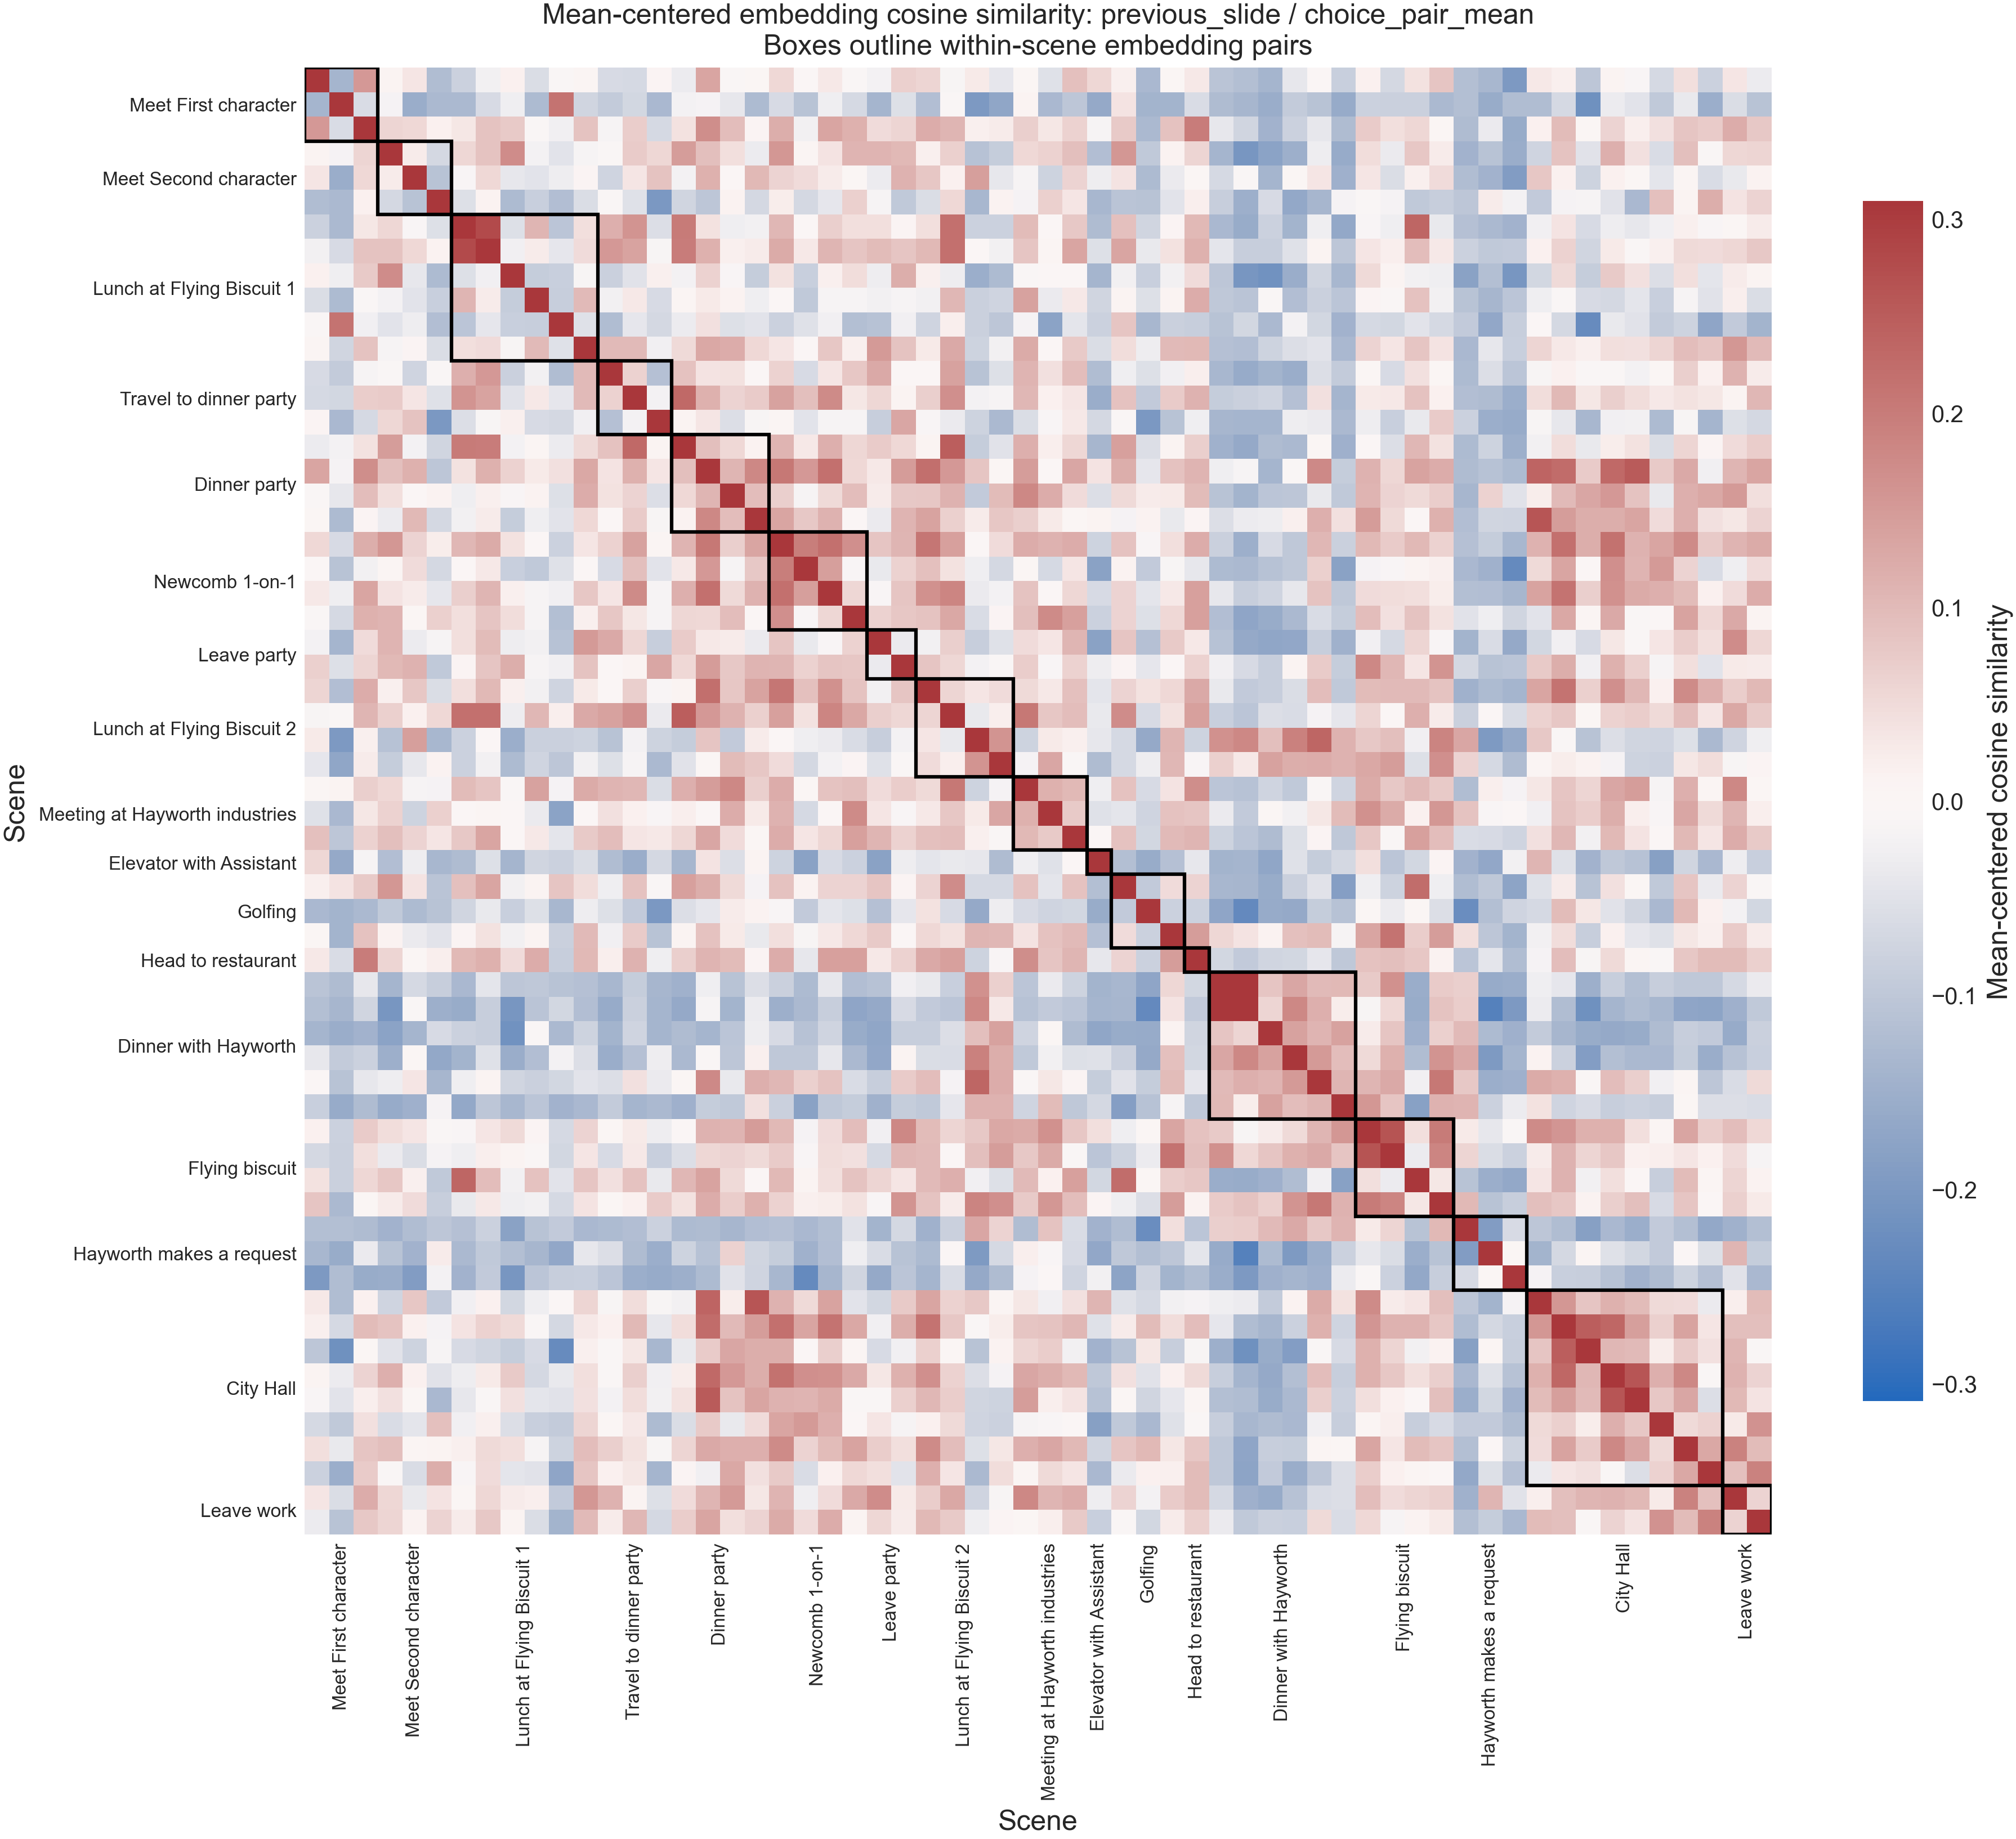

In [27]:
from matplotlib.patches import Rectangle
from sklearn.metrics.pairwise import cosine_similarity

# Print scene row counts in first-appearance order.
scene_counts = snt_df.groupby("scene", sort=False, dropna=False).size()
for scene, n_rows in scene_counts.items():
    print(f"{scene}: {n_rows}")

# Use one identity-masked embedding per decision, ordered as in the task.
SIMILARITY_CONTEXT = "previous_slide"
SIMILARITY_REP_TYPE = "choice_pair_mean"

similarity_mask = (
    rep_manifest["context"].eq(SIMILARITY_CONTEXT)
    & rep_manifest["rep_type"].eq(SIMILARITY_REP_TYPE)
)
similarity_manifest = rep_manifest.loc[similarity_mask].copy()
similarity_embeddings = X[similarity_mask.to_numpy()]

# Keep the manifest, embeddings, and scene labels in the same task order.
task_order = np.argsort(
    similarity_manifest["trial_num"].to_numpy(),
    kind="stable",
)
similarity_manifest = similarity_manifest.iloc[task_order].reset_index(drop=True)
similarity_embeddings = similarity_embeddings[task_order]
scene_by_trial = (
    snt_df.dropna(subset=["trial_num"])
    .drop_duplicates("trial_num")
    .set_index("trial_num")["scene"]
)
similarity_manifest["scene"] = similarity_manifest["trial_num"].map(
    scene_by_trial
)

if similarity_manifest["scene"].isna().any():
    raise ValueError("Some embeddings could not be matched to a scene.")

cosine_similarity_matrix = cosine_similarity(similarity_embeddings)

# Mean-center using only unique off-diagonal pairs so self-similarity
# values of 1 do not inflate the reference mean.
off_diagonal_mask = ~np.eye(
    cosine_similarity_matrix.shape[0],
    dtype=bool,
)
mean_off_diagonal_similarity = cosine_similarity_matrix[
    off_diagonal_mask
].mean()
mean_centered_similarity_matrix = (
    cosine_similarity_matrix - mean_off_diagonal_similarity
)

# Use symmetric limits based on the centered off-diagonal values.
# The diagonal may saturate, keeping the meaningful pairwise variation visible.
color_limit = np.abs(
    mean_centered_similarity_matrix[off_diagonal_mask]
).max()
print(
    "Mean off-diagonal cosine similarity subtracted: "
    f"{mean_off_diagonal_similarity:.3f}"
)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    mean_centered_similarity_matrix,
    ax=ax,
    cmap="vlag",
    vmin=-color_limit,
    vmax=color_limit,
    center=0,
    square=True,
    xticklabels=False,
    yticklabels=False,
    cbar_kws={
        "label": "Mean-centered cosine similarity",
        "shrink": 0.8,
    },
)

# Find contiguous scene runs and outline all within-scene pairs.
scene_labels = similarity_manifest["scene"].astype(str).to_numpy()
scene_starts = np.flatnonzero(
    np.r_[True, scene_labels[1:] != scene_labels[:-1]]
)
scene_ends = np.r_[scene_starts[1:], len(scene_labels)]
scene_centers = (scene_starts + scene_ends) / 2
scene_run_labels = scene_labels[scene_starts]

for start, end in zip(scene_starts, scene_ends):
    width = end - start
    ax.add_patch(
        Rectangle(
            (start, start),
            width,
            width,
            fill=False,
            edgecolor="black",
            linewidth=1.5,
        )
    )

ax.set_xticks(scene_centers)
ax.set_yticks(scene_centers)
ax.set_xticklabels(scene_run_labels, rotation=90, fontsize=8)
ax.set_yticklabels(scene_run_labels, rotation=0, fontsize=8)
ax.set_xlabel("Scene")
ax.set_ylabel("Scene")
ax.set_title(
    f"Mean-centered embedding cosine similarity: {SIMILARITY_CONTEXT} / "
    f"{SIMILARITY_REP_TYPE}\n"
    "Boxes outline within-scene embedding pairs"
)
plt.tight_layout()
plt.show()

# decode dimension

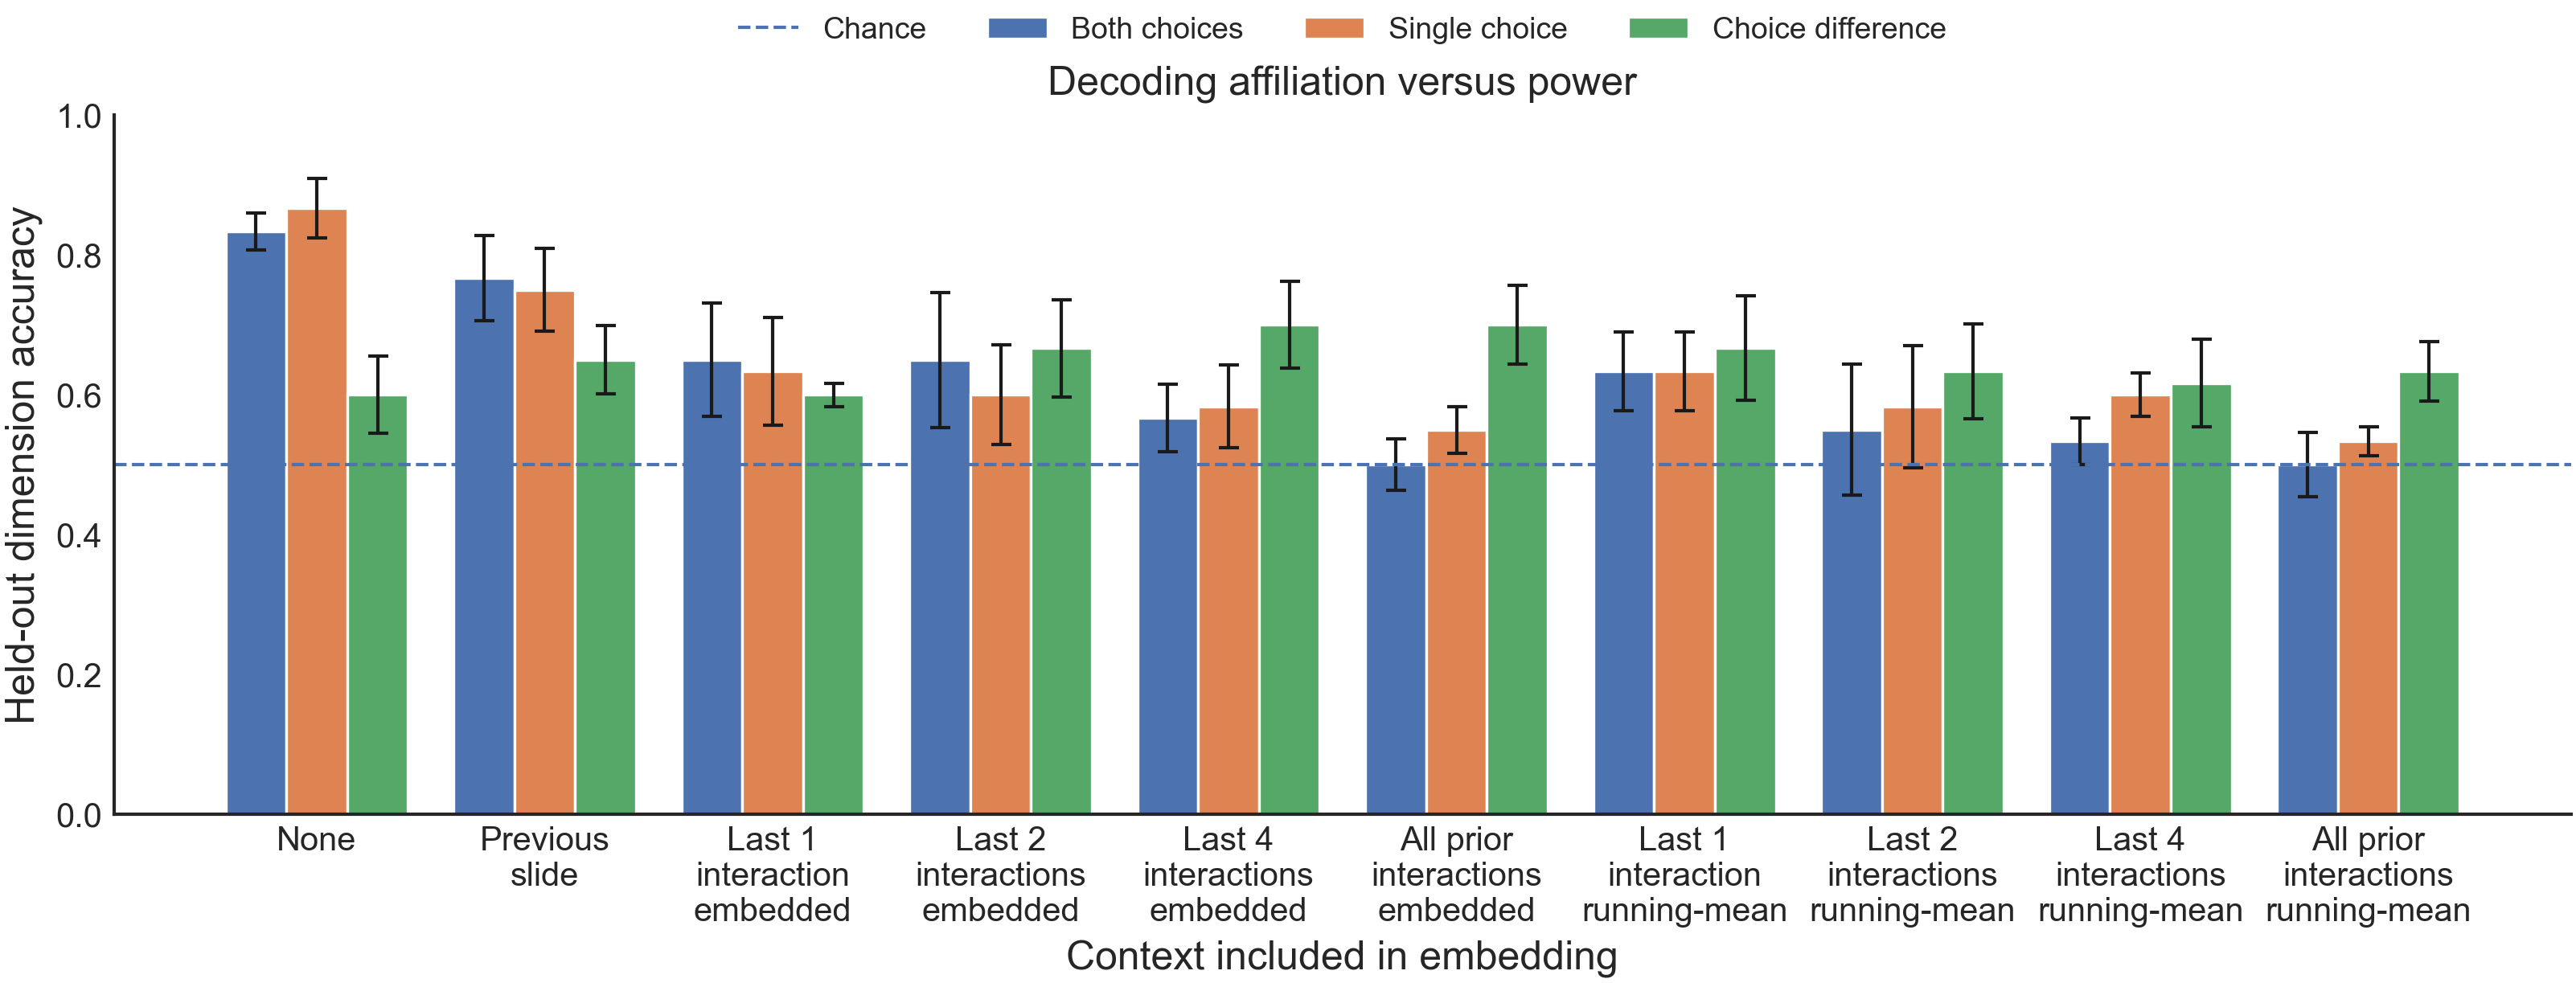

In [4]:
from sklearn.model_selection import LeaveOneGroupOut

# ---------------------------------------------------------------------
# Prepare one representation × context dataset
# ---------------------------------------------------------------------

def get_dimension_decoding_data(
    rep_manifest,
    X,
    rep_type,
    context,
):
    """
    Select one representation and context for affiliation-vs-power
    decoding.

    For option_diff, retain one canonical vector per decision:
    positive option minus negative option.
    """
    if len(rep_manifest) != X.shape[0]:
        raise ValueError(
            "rep_manifest rows must align exactly with rows of X."
        )

    mask = (
        rep_manifest["rep_type"].eq(rep_type)
        & rep_manifest["context"].eq(context)
    )

    # The current representation table contains both d and -d.
    # For dimension decoding, keep only:
    # positive option embedding - negative option embedding.
    if rep_type == "option_diff":
        mask &= rep_manifest["direction"].eq(1)

    meta = (
        rep_manifest
        .loc[mask]
        .reset_index(drop=True)
    )

    X_rep = np.asarray(X)[mask.to_numpy()]

    if len(meta) == 0:
        raise ValueError(
            f"No rows found for rep_type={rep_type}, context={context}."
        )

    observed_dimensions = set(meta["dimension"].dropna())

    if observed_dimensions != {"affil", "power"}:
        raise ValueError(
            f"Unexpected dimension labels: {observed_dimensions}"
        )

    # 0 = affiliation, 1 = power
    y = (
        meta["dimension"]
        .eq("power")
        .astype(int)
        .to_numpy()
    )

    decision_num = (
        meta["decision_num"]
        .astype(int)
        .to_numpy()
    )

    character = (
        meta["character"]
        .astype(str)
        .to_numpy()
    )

    # Basic checks on the expected structure.
    rows_per_decision = (
        meta
        .groupby("decision_num")
        .size()
    )

    expected_rows = 2 if rep_type == "option" else 1

    if not np.all(
        rows_per_decision.to_numpy() == expected_rows
    ):
        raise ValueError(
            f"{rep_type} should contain {expected_rows} row(s) "
            "per decision."
        )

    return X_rep, y, decision_num, character

# ---------------------------------------------------------------------
# Model and decision-level scoring
# ---------------------------------------------------------------------

def make_dimension_model(C):
    """
    Standardized L2-regularized logistic regression.
    """
    return Pipeline([
        (
            "scale",
            StandardScaler(),
        ),
        (
            "logistic",
            LogisticRegression(
                C=C,
                penalty="l2",
                solver="liblinear",
                max_iter=5000,
            ),
        ),
    ])

def decision_level_accuracy(
    y,
    power_probability,
    decision_num,
):
    """
    Calculate accuracy after averaging predictions within decision.

    This matters for the single-option representation, which has two
    rows per decision. All representations are therefore evaluated on
    the same unit: the decision.
    """
    prediction_df = pd.DataFrame({
        "decision_num": decision_num,
        "y": y,
        "power_probability": power_probability,
    })

    label_counts = (
        prediction_df
        .groupby("decision_num")["y"]
        .nunique()
    )

    if label_counts.max() != 1:
        raise ValueError(
            "Each decision must have one dimension label."
        )

    decision_predictions = (
        prediction_df
        .groupby("decision_num", as_index=False)
        .agg(
            y=("y", "first"),
            power_probability=(
                "power_probability",
                "mean",
            ),
        )
    )

    predicted_y = (
        decision_predictions["power_probability"]
        >= 0.5
    ).astype(int)

    return accuracy_score(
        decision_predictions["y"],
        predicted_y,
    )

# ---------------------------------------------------------------------
# Nested cross-validation
# ---------------------------------------------------------------------

def run_dimension_decoding(
    rep_manifest,
    X,
    contexts=CONTEXT_ORDER,
    rep_types=REPRESENTATION_ORDER,
    c_grid=C_GRID,
):
    """
    Decode affiliation versus power for every representation × context.

    Outer CV
    --------
    Leave one character out. With five characters, this gives five
    outer folds.

    Inner CV
    --------
    Three-fold grouped CV over the remaining characters to select C.

    Returns
    -------
    fold_results : DataFrame
        One row per outer fold.

    summary : DataFrame
        Mean accuracy and SEM across the five held-out characters.
    """
    c_grid = np.sort(
        np.asarray(c_grid, dtype=float)
    )

    result_rows = []

    for context in contexts:

        for rep_type in rep_types:

            (
                X_rep,
                y,
                decision_num,
                character,
            ) = get_dimension_decoding_data(
                rep_manifest=rep_manifest,
                X=X,
                rep_type=rep_type,
                context=context,
            )

            outer_cv = LeaveOneGroupOut()

            outer_splits = list(
                outer_cv.split(
                    X_rep,
                    y,
                    groups=character,
                )
            )

            if len(outer_splits) != 5:
                print(
                    f"Warning: expected 5 character folds, "
                    f"found {len(outer_splits)}."
                )

            for outer_fold, (
                train_idx,
                test_idx,
            ) in enumerate(
                outer_splits,
                start=1,
            ):

                X_train = X_rep[train_idx]
                y_train = y[train_idx]

                train_decisions = decision_num[train_idx]
                train_characters = character[train_idx]

                X_test = X_rep[test_idx]
                y_test = y[test_idx]

                test_decisions = decision_num[test_idx]
                test_characters = character[test_idx]

                held_out_character = np.unique(
                    test_characters
                )

                if len(held_out_character) != 1:
                    raise ValueError(
                        "Each outer fold should hold out exactly "
                        "one character."
                    )

                held_out_character = (
                    held_out_character[0]
                )

                # Inner three-fold CV over the four training characters.
                inner_cv = GroupKFold(
                    n_splits=3
                )

                inner_splits = list(
                    inner_cv.split(
                        X_train,
                        y_train,
                        groups=train_characters,
                    )
                )

                best_C = None
                best_inner_accuracy = -np.inf

                for C in c_grid:

                    inner_accuracies = []

                    for (
                        inner_train_idx,
                        inner_valid_idx,
                    ) in inner_splits:

                        model = make_dimension_model(C)

                        model.fit(
                            X_train[inner_train_idx],
                            y_train[inner_train_idx],
                        )

                        valid_probability = (
                            model.predict_proba(
                                X_train[inner_valid_idx]
                            )[:, 1]
                        )

                        inner_accuracy = (
                            decision_level_accuracy(
                                y=y_train[
                                    inner_valid_idx
                                ],
                                power_probability=(
                                    valid_probability
                                ),
                                decision_num=(
                                    train_decisions[
                                        inner_valid_idx
                                    ]
                                ),
                            )
                        )

                        inner_accuracies.append(
                            inner_accuracy
                        )

                    mean_inner_accuracy = np.mean(
                        inner_accuracies
                    )

                    # C_GRID is sorted, so ties retain the smaller C.
                    if (
                        mean_inner_accuracy
                        > best_inner_accuracy
                    ):
                        best_inner_accuracy = (
                            mean_inner_accuracy
                        )
                        best_C = C

                # Refit using the chosen regularization strength.
                final_model = make_dimension_model(
                    best_C
                )

                final_model.fit(
                    X_train,
                    y_train,
                )

                test_probability = (
                    final_model.predict_proba(
                        X_test
                    )[:, 1]
                )

                test_accuracy = (
                    decision_level_accuracy(
                        y=y_test,
                        power_probability=test_probability,
                        decision_num=test_decisions,
                    )
                )

                result_rows.append({
                    "context": context,
                    "rep_type": rep_type,
                    "outer_fold": outer_fold,
                    "held_out_character": (
                        held_out_character
                    ),
                    "accuracy": test_accuracy,
                    "best_C": best_C,
                    "best_inner_accuracy": (
                        best_inner_accuracy
                    ),
                    "n_train_decisions": len(
                        np.unique(train_decisions)
                    ),
                    "n_test_decisions": len(
                        np.unique(test_decisions)
                    ),
                })

    fold_results = pd.DataFrame(
        result_rows
    )

    summary = (
        fold_results
        .groupby(
            ["context", "rep_type"],
            as_index=False,
        )
        .agg(
            mean_accuracy=("accuracy", "mean"),
            sd_accuracy=("accuracy", "std"),
            n_folds=("accuracy", "count"),
            median_best_C=("best_C", "median"),
        )
    )

    summary["sem_accuracy"] = (
        summary["sd_accuracy"]
        / np.sqrt(summary["n_folds"])
    )

    context_rank = {
        context: index
        for index, context in enumerate(contexts)
    }

    representation_rank = {
        rep_type: index
        for index, rep_type in enumerate(rep_types)
    }

    summary["_context_rank"] = (
        summary["context"].map(context_rank)
    )

    summary["_representation_rank"] = (
        summary["rep_type"].map(
            representation_rank
        )
    )

    summary = (
        summary
        .sort_values(
            [
                "_context_rank",
                "_representation_rank",
            ]
        )
        .drop(
            columns=[
                "_context_rank",
                "_representation_rank",
            ]
        )
        .reset_index(drop=True)
    )

    return fold_results, summary

# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

def plot_dimension_decoding(
    summary,
    contexts=CONTEXT_ORDER,
    rep_types=REPRESENTATION_ORDER,
):
    """
    Grouped bar plot of mean held-out dimension-decoding accuracy.
    Error bars are SEM across the five held-out characters.
    """
    x = np.arange(
        len(contexts)
    )

    n_rep_types = len(rep_types)
    bar_width = 0.8 / n_rep_types

    fig, ax = plt.subplots(
        figsize=(11, 4.5)
    )

    for rep_index, rep_type in enumerate(
        rep_types
    ):
        rep_summary = (
            summary
            .loc[
                summary["rep_type"] == rep_type
            ]
            .set_index("context")
            .reindex(contexts)
        )

        offset = (
            rep_index
            - (n_rep_types - 1) / 2
        ) * bar_width

        ax.bar(
            x + offset,
            rep_summary[
                "mean_accuracy"
            ].to_numpy(),
            width=bar_width,
            yerr=rep_summary[
                "sem_accuracy"
            ].to_numpy(),
            capsize=3,
            label=REPRESENTATION_LABELS.get(
                rep_type,
                rep_type,
            ),
        )

    ax.axhline(
        0.5,
        linestyle="--",
        linewidth=1,
        label="Chance",
    )

    ax.set_xticks(
        x,
        [
            CONTEXT_LABELS.get(
                context,
                context,
            )
            for context in contexts
        ],
    )

    ax.set_ylim(0, 1)

    ax.set_ylabel(
        "Held-out dimension accuracy"
    )

    ax.set_xlabel(
        "Context included in embedding"
    )

    ax.set_title(
        "Decoding affiliation versus power"
    )

    ax.legend(
        frameon=False,
        ncol=4,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.18),
    )

    fig.tight_layout()
    plt.show()

# ---------------------------------------------------------------------
# Run
# ---------------------------------------------------------------------

dimension_fold_results, dimension_summary = (
    run_dimension_decoding(
        rep_manifest=rep_manifest,
        X=X,
    )
)

plot_dimension_decoding(
    dimension_summary
)

# decode choice direction

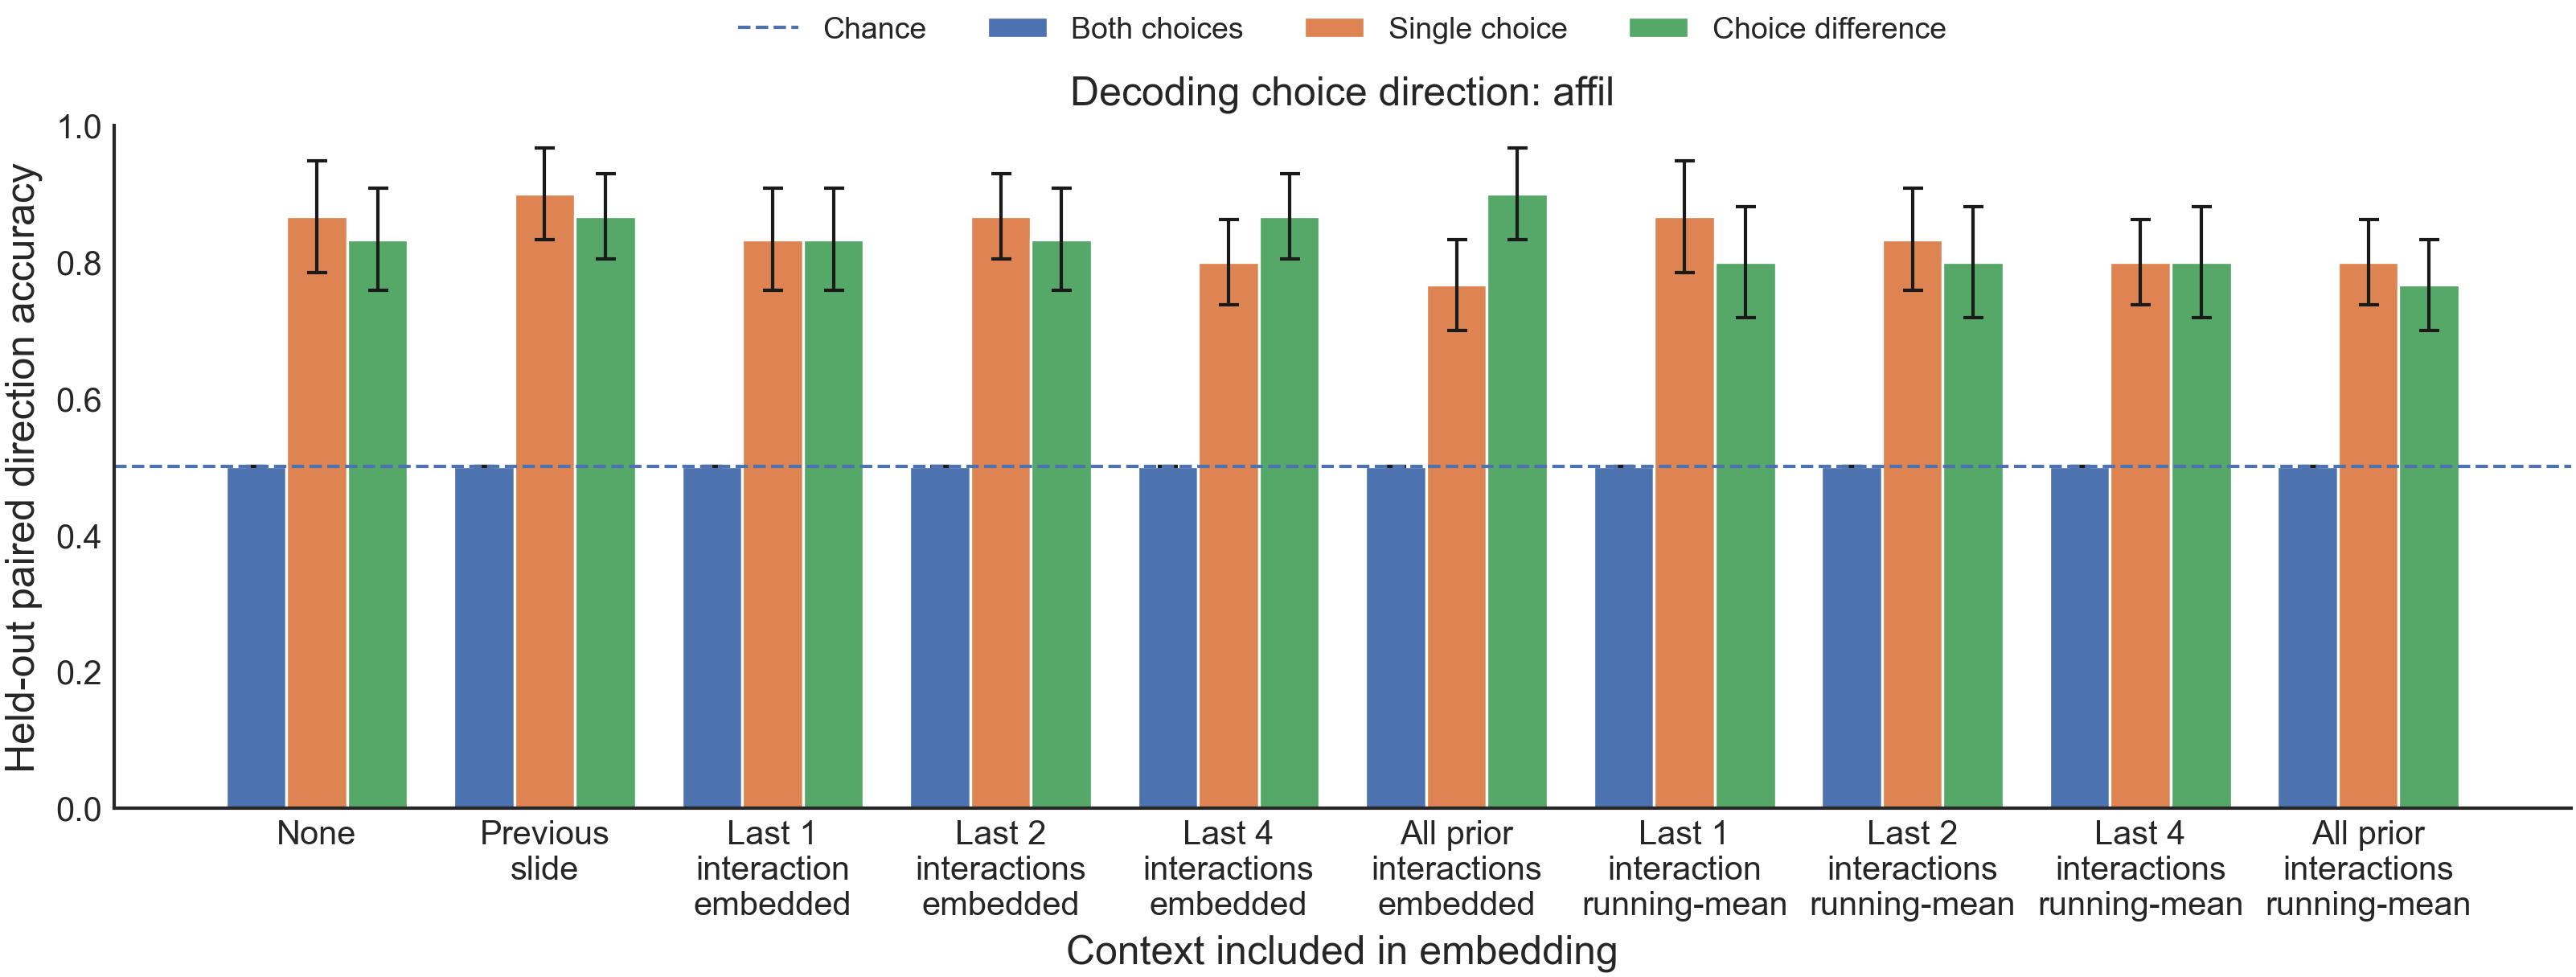

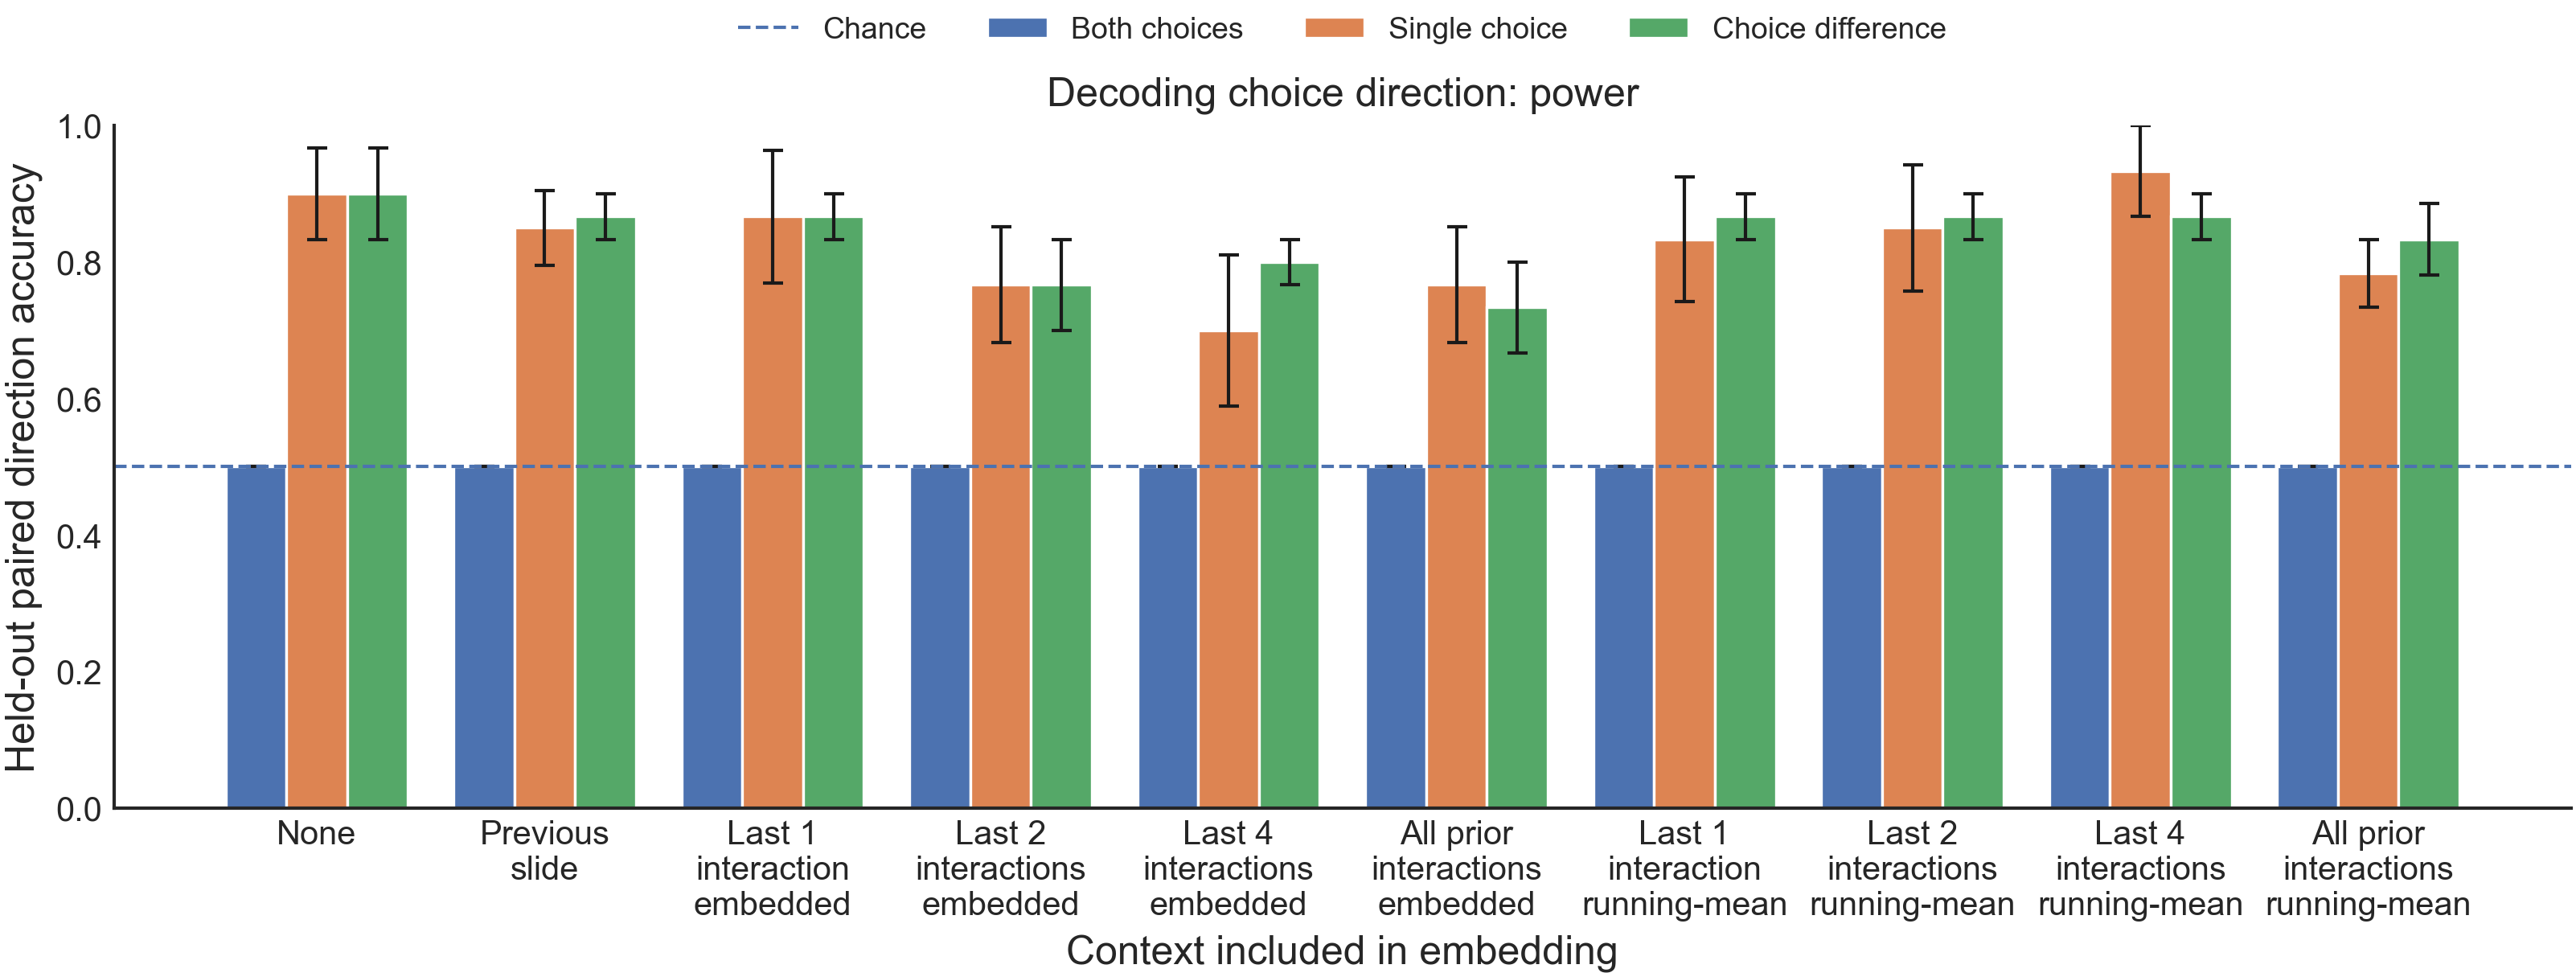

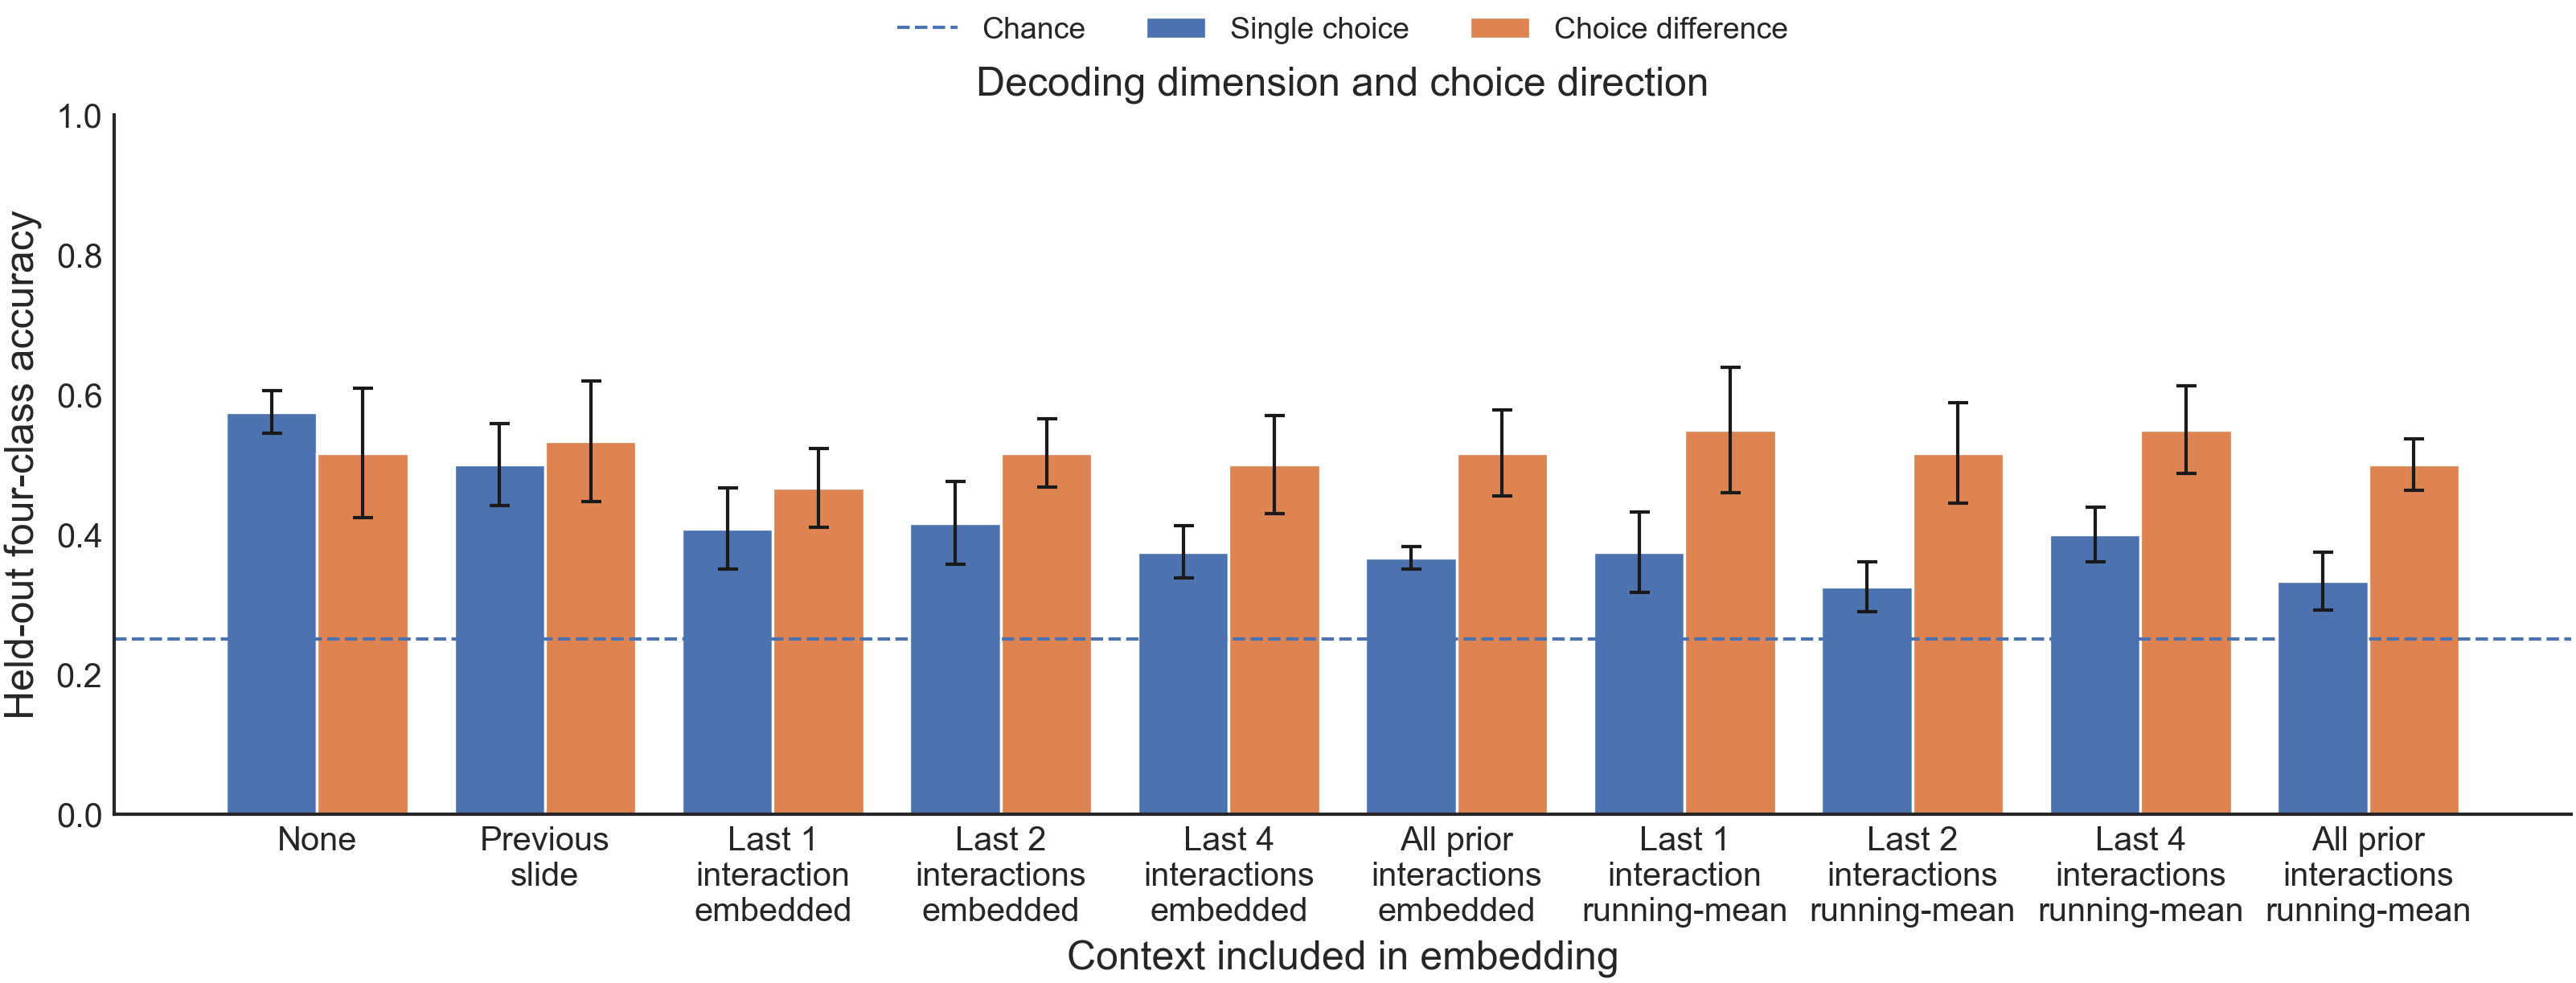

In [5]:
# Select one representation × context dataset
def get_direction_decoding_data(
    rep_manifest,
    X,
    rep_type,
    context,
    dimension=None,
):
    """
    Prepare data for decoding +1 versus -1 choice direction.

    Parameters
    ----------
    rep_manifest : DataFrame
        Metadata aligned row-for-row with X.

    X : ndarray
        Embedding representation matrix.

    rep_type : str
        One of:
            choice_pair_mean
            option
            option_diff

    context : str
        One context name, such as:
            none
            previous_slide
            samechar_1
            samechar_2
            samechar_4
            samechar_all

    dimension : str or None
        None uses both affiliation and power decisions.
        Alternatively use "affil" or "power".

    Notes
    -----
    choice_pair_mean has one vector per decision and no direction label.
    To include it as a negative control, the same vector is assigned once
    to +1 and once to -1. It therefore cannot exceed chance.
    """
    X = np.asarray(X)

    if len(rep_manifest) != X.shape[0]:
        raise ValueError(
            "rep_manifest must contain exactly one row per row of X."
        )

    mask = (
        rep_manifest["rep_type"].eq(rep_type)
        & rep_manifest["context"].eq(context)
    )

    if dimension is not None:
        if dimension not in {"affil", "power"}:
            raise ValueError(
                "dimension must be None, 'affil', or 'power'."
            )

        mask &= rep_manifest["dimension"].eq(dimension)

    base_meta = (
        rep_manifest
        .loc[mask]
        .copy()
        .reset_index(drop=True)
    )

    base_X = X[mask.to_numpy()]

    if len(base_meta) == 0:
        raise ValueError(
            f"No rows found for representation={rep_type}, "
            f"context={context}, dimension={dimension}."
        )

    # -------------------------------------------------------------
    # Pair mean: duplicate each decision vector and assign both
    # directions. This is a deliberate chance-level control.
    # -------------------------------------------------------------
    if rep_type == "choice_pair_mean":

        positive_meta = base_meta.copy()
        positive_meta["direction"] = 1
        positive_meta["option_idx"] = "positive"

        negative_meta = base_meta.copy()
        negative_meta["direction"] = -1
        negative_meta["option_idx"] = "negative"

        meta = pd.concat(
            [positive_meta, negative_meta],
            ignore_index=True,
        )

        X_rep = np.vstack([
            base_X,
            base_X,
        ])

    # -------------------------------------------------------------
    # Single option and option difference already contain one row
    # for each direction.
    # -------------------------------------------------------------
    else:
        meta = base_meta
        X_rep = base_X

    meta["direction"] = pd.to_numeric(
        meta["direction"],
        errors="coerce",
    )

    if not meta["direction"].isin([-1, 1]).all():
        invalid = meta.loc[
            ~meta["direction"].isin([-1, 1]),
            ["decision_num", "direction"],
        ]

        raise ValueError(
            "Direction labels must be -1 or +1:\n"
            f"{invalid.head()}"
        )

    # Binary target:
    # 0 = negative direction
    # 1 = positive direction
    y = (
        meta["direction"]
        .eq(1)
        .astype(int)
        .to_numpy()
    )

    # A unit is one participant × decision when sub_id exists,
    # otherwise simply one task decision.
    if "sub_id" in meta.columns:
        meta["unit_id"] = (
            meta["sub_id"].astype(str)
            + "__"
            + meta["decision_num"].astype(int).astype(str)
        )
    else:
        meta["unit_id"] = (
            meta["decision_num"]
            .astype(int)
            .astype(str)
        )

    unit_id = meta["unit_id"].to_numpy()

    character = (
        meta["character"]
        .astype(str)
        .to_numpy()
    )

    # Every decision should contribute exactly one +1 and one -1 row.
    unit_check = (
        meta
        .groupby("unit_id")["direction"]
        .agg(["count", "nunique", "sum"])
    )

    valid_units = (
        unit_check["count"].eq(2)
        & unit_check["nunique"].eq(2)
        & unit_check["sum"].eq(0)
    )

    if not valid_units.all():
        raise ValueError(
            "Each decision must contribute exactly one +1 and one -1 "
            "representation.\n"
            f"{unit_check.loc[~valid_units].head()}"
        )

    return (
        X_rep,
        y,
        unit_id,
        character,
        meta,
    )

# Model
def make_direction_model(C):
    """
    Standardized L2-regularized logistic regression.
    """
    return Pipeline([
        (
            "scale",
            StandardScaler(),
        ),
        (
            "logistic",
            LogisticRegression(
                C=C,
                penalty="l2",
                solver="liblinear",
                max_iter=5000,
                random_state=42,
            ),
        ),
    ])

# Direction scoring
def paired_direction_accuracy(
    y,
    positive_probability,
    unit_id,
    tie_tolerance=1e-12,
):
    """
    For each decision, test whether the positive option receives a
    higher predicted P(direction=+1) than the negative option.

    Returns
    -------
    accuracy : float
        1 when the positive option is ranked above the negative option,
        0 when ranked below, and 0.5 for an exact tie.

    pair_results : DataFrame
        One row per decision.
    """
    prediction_df = pd.DataFrame({
        "unit_id": unit_id,
        "y": y,
        "positive_probability": positive_probability,
    })

    pair_df = (
        prediction_df
        .groupby(
            ["unit_id", "y"],
            as_index=False,
        )
        .agg(
            positive_probability=(
                "positive_probability",
                "mean",
            )
        )
        .pivot(
            index="unit_id",
            columns="y",
            values="positive_probability",
        )
    )

    if 0 not in pair_df.columns or 1 not in pair_df.columns:
        raise ValueError(
            "Each decision must have one positive and one negative option."
        )

    pair_df = pair_df.rename(
        columns={
            0: "negative_option_probability",
            1: "positive_option_probability",
        }
    )

    pair_df["probability_difference"] = (
        pair_df["positive_option_probability"]
        - pair_df["negative_option_probability"]
    )

    difference = pair_df[
        "probability_difference"
    ].to_numpy()

    pair_df["correct"] = np.where(
        difference > tie_tolerance,
        1.0,
        np.where(
            difference < -tie_tolerance,
            0.0,
            0.5,
        ),
    )

    accuracy = pair_df["correct"].mean()

    return float(accuracy), pair_df.reset_index()

# Nested cross-validation
def run_direction_decoding(
    rep_manifest,
    X,
    contexts=CONTEXT_ORDER,
    rep_types=REPRESENTATION_ORDER,
    c_grid=C_GRID,
    dimension=None,
):
    """
    Decode positive versus negative choice direction for each
    representation × context.

    Outer CV
    --------
    Leave one character out, producing five outer folds.

    Inner CV
    --------
    Three-fold grouped CV over the remaining characters to select C.

    Primary metric
    --------------
    Decision-pair accuracy: whether the model ranks the +1 option above
    the -1 option for each held-out decision.
    """
    c_grid = np.sort(
        np.asarray(c_grid, dtype=float)
    )

    result_rows = []

    for context in contexts:

        for rep_type in rep_types:

            (
                X_rep,
                y,
                unit_id,
                character,
                meta,
            ) = get_direction_decoding_data(
                rep_manifest=rep_manifest,
                X=X,
                rep_type=rep_type,
                context=context,
                dimension=dimension,
            )

            outer_cv = LeaveOneGroupOut()

            outer_splits = list(
                outer_cv.split(
                    X_rep,
                    y,
                    groups=character,
                )
            )

            for outer_fold, (
                train_idx,
                test_idx,
            ) in enumerate(
                outer_splits,
                start=1,
            ):

                X_train = X_rep[train_idx]
                y_train = y[train_idx]

                train_units = unit_id[train_idx]
                train_characters = character[train_idx]

                X_test = X_rep[test_idx]
                y_test = y[test_idx]

                test_units = unit_id[test_idx]
                test_characters = character[test_idx]

                held_out_characters = np.unique(
                    test_characters
                )

                if len(held_out_characters) != 1:
                    raise ValueError(
                        "Each outer fold should hold out one character."
                    )

                held_out_character = (
                    held_out_characters[0]
                )

                # Three-fold CV among the four remaining characters.
                inner_cv = GroupKFold(
                    n_splits=3
                )

                inner_splits = list(
                    inner_cv.split(
                        X_train,
                        y_train,
                        groups=train_characters,
                    )
                )

                best_C = None
                best_inner_accuracy = -np.inf

                for C in c_grid:

                    inner_accuracies = []

                    for (
                        inner_train_idx,
                        inner_valid_idx,
                    ) in inner_splits:

                        model = make_direction_model(C)

                        model.fit(
                            X_train[inner_train_idx],
                            y_train[inner_train_idx],
                        )

                        valid_probability = (
                            model.predict_proba(
                                X_train[inner_valid_idx]
                            )[:, 1]
                        )

                        inner_accuracy, _ = (
                            paired_direction_accuracy(
                                y=y_train[inner_valid_idx],
                                positive_probability=(
                                    valid_probability
                                ),
                                unit_id=train_units[
                                    inner_valid_idx
                                ],
                            )
                        )

                        inner_accuracies.append(
                            inner_accuracy
                        )

                    mean_inner_accuracy = float(
                        np.mean(inner_accuracies)
                    )

                    # Because C_GRID is sorted, a tie retains
                    # the smaller and more regularized C.
                    if (
                        mean_inner_accuracy
                        > best_inner_accuracy
                    ):
                        best_inner_accuracy = (
                            mean_inner_accuracy
                        )
                        best_C = float(C)

                # Refit on all four training characters.
                final_model = make_direction_model(
                    best_C
                )

                final_model.fit(
                    X_train,
                    y_train,
                )

                test_probability = (
                    final_model.predict_proba(
                        X_test
                    )[:, 1]
                )

                pair_accuracy, pair_results = (
                    paired_direction_accuracy(
                        y=y_test,
                        positive_probability=(
                            test_probability
                        ),
                        unit_id=test_units,
                    )
                )

                # Conventional row-level accuracy is retained
                # only as a secondary descriptive metric.
                test_prediction = (
                    test_probability >= 0.5
                ).astype(int)

                row_accuracy = accuracy_score(
                    y_test,
                    test_prediction,
                )

                result_rows.append({
                    "context": context,
                    "rep_type": rep_type,
                    "dimension_subset": (
                        "both"
                        if dimension is None
                        else dimension
                    ),
                    "outer_fold": outer_fold,
                    "held_out_character": (
                        held_out_character
                    ),
                    "pair_accuracy": pair_accuracy,
                    "row_accuracy": row_accuracy,
                    "best_C": best_C,
                    "best_inner_accuracy": (
                        best_inner_accuracy
                    ),
                    "n_train_decisions": len(
                        np.unique(train_units)
                    ),
                    "n_test_decisions": len(
                        np.unique(test_units)
                    ),
                })

    fold_results = pd.DataFrame(
        result_rows
    )

    summary = (
        fold_results
        .groupby(
            [
                "dimension_subset",
                "context",
                "rep_type",
            ],
            as_index=False,
        )
        .agg(
            mean_accuracy=(
                "pair_accuracy",
                "mean",
            ),
            sd_accuracy=(
                "pair_accuracy",
                "std",
            ),
            mean_row_accuracy=(
                "row_accuracy",
                "mean",
            ),
            n_folds=(
                "pair_accuracy",
                "count",
            ),
            median_best_C=(
                "best_C",
                "median",
            ),
        )
    )

    summary["sem_accuracy"] = (
        summary["sd_accuracy"]
        / np.sqrt(summary["n_folds"])
    )

    context_rank = {
        context: index
        for index, context in enumerate(contexts)
    }

    representation_rank = {
        rep_type: index
        for index, rep_type in enumerate(rep_types)
    }

    summary["_context_rank"] = (
        summary["context"].map(context_rank)
    )

    summary["_representation_rank"] = (
        summary["rep_type"].map(
            representation_rank
        )
    )

    summary = (
        summary
        .sort_values(
            [
                "_context_rank",
                "_representation_rank",
            ]
        )
        .drop(
            columns=[
                "_context_rank",
                "_representation_rank",
            ]
        )
        .reset_index(drop=True)
    )

    return fold_results, summary

# Plot
def plot_direction_decoding(
    summary,
    contexts=CONTEXT_ORDER,
    rep_types=REPRESENTATION_ORDER,
):
    """
    Grouped bar plot of held-out direction decoding accuracy.

    Error bars are SEM across the five held-out characters.
    """
    x = np.arange(
        len(contexts)
    )

    n_rep_types = len(rep_types)
    bar_width = 0.8 / n_rep_types

    fig, ax = plt.subplots(
        figsize=(11, 4.5)
    )

    for rep_index, rep_type in enumerate(
        rep_types
    ):

        rep_summary = (
            summary
            .loc[
                summary["rep_type"].eq(rep_type)
            ]
            .set_index("context")
            .reindex(contexts)
        )

        offset = (
            rep_index
            - (n_rep_types - 1) / 2
        ) * bar_width

        ax.bar(
            x + offset,
            rep_summary[
                "mean_accuracy"
            ].to_numpy(),
            width=bar_width,
            yerr=rep_summary[
                "sem_accuracy"
            ].to_numpy(),
            capsize=3,
            label=(
                REPRESENTATION_LABELS.get(
                    rep_type,
                    rep_type,
                )
            ),
        )

    ax.axhline(
        0.5,
        linestyle="--",
        linewidth=1,
        label="Chance",
    )

    ax.set_xticks(
        x,
        [
            CONTEXT_LABELS.get(
                context,
                context,
            )
            for context in contexts
        ],
    )

    ax.set_ylim(0, 1)

    ax.set_ylabel(
        "Held-out paired direction accuracy"
    )

    ax.set_xlabel(
        "Context included in embedding"
    )

    dimension_subset = (
        summary["dimension_subset"].iloc[0]
    )

    if dimension_subset == "both":
        title = (
            "Decoding positive versus negative choice direction"
        )
    else:
        title = (
            "Decoding choice direction: "
            f"{dimension_subset}"
        )

    ax.set_title(title)

    ax.legend(
        frameon=False,
        ncol=4,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.20),
    )

    fig.tight_layout()
    plt.show()


# =====================================================================
# 1. Decode direction separately within affiliation and power
# =====================================================================

# These calls reuse the run_direction_decoding() and
# plot_direction_decoding() functions from the previous block.

affil_direction_folds, affil_direction_summary = (
    run_direction_decoding(
        rep_manifest=rep_manifest,
        X=X,
        dimension="affil",
    )
)

power_direction_folds, power_direction_summary = (
    run_direction_decoding(
        rep_manifest=rep_manifest,
        X=X,
        dimension="power",
    )
)

plot_direction_decoding(affil_direction_summary)
plot_direction_decoding(power_direction_summary)

# Combined fold-level dataframe, useful for later comparison.
direction_by_dimension_folds = pd.concat(
    [
        affil_direction_folds,
        power_direction_folds,
    ],
    ignore_index=True,
)

direction_by_dimension_summary = pd.concat(
    [
        affil_direction_summary,
        power_direction_summary,
    ],
    ignore_index=True,
)


# =====================================================================
# 2. Four-class decoding:
#
#    0 = negative affiliation
#    1 = positive affiliation
#    2 = negative power
#    3 = positive power
#
# Pair means are excluded because they contain both directions and
# therefore cannot be assigned a unique four-class label.
# =====================================================================

FOUR_CLASS_REPRESENTATION_ORDER = [
    rep_type
    for rep_type in REPRESENTATION_ORDER
    if rep_type != "choice_pair_mean"
]

FOUR_CLASS_LABELS = {
    ("affil", -1): 0,
    ("affil",  1): 1,
    ("power", -1): 2,
    ("power",  1): 3,
}

FOUR_CLASS_NAMES = {
    0: "Affiliation −",
    1: "Affiliation +",
    2: "Power −",
    3: "Power +",
}

def make_four_class_model(C):
    """
    Standardized L2-regularized multinomial logistic regression.
    """
    return Pipeline([
        (
            "scale",
            StandardScaler(),
        ),
        (
            "logistic",
            LogisticRegression(
                C=C,
                penalty="l2",
                solver="lbfgs",
                max_iter=5000,
                random_state=42,
            ),
        ),
    ])

def run_four_class_decoding(
    rep_manifest,
    X,
    contexts=CONTEXT_ORDER,
    rep_types=FOUR_CLASS_REPRESENTATION_ORDER,
    c_grid=C_GRID,
):
    """
    Decode the four combinations of dimension and direction.

    Outer CV
    --------
    Leave one character out: five outer folds.

    Inner CV
    --------
    Three-fold grouped CV over the remaining characters to select C.

    Metric
    ------
    Balanced accuracy across the four classes.
    """
    X = np.asarray(X)

    if len(rep_manifest) != X.shape[0]:
        raise ValueError(
            "rep_manifest must contain exactly one row per row of X."
        )

    c_grid = np.sort(
        np.asarray(c_grid, dtype=float)
    )

    result_rows = []

    for context in contexts:

        for rep_type in rep_types:

            mask = (
                rep_manifest["context"].eq(context)
                & rep_manifest["rep_type"].eq(rep_type)
            )

            meta = (
                rep_manifest
                .loc[mask]
                .copy()
                .reset_index(drop=True)
            )

            X_rep = X[mask.to_numpy()]

            if len(meta) == 0:
                raise ValueError(
                    f"No rows found for context={context}, "
                    f"rep_type={rep_type}."
                )

            meta["direction"] = pd.to_numeric(
                meta["direction"],
                errors="coerce",
            )

            valid = (
                meta["dimension"].isin(["affil", "power"])
                & meta["direction"].isin([-1, 1])
            )

            meta = (
                meta
                .loc[valid]
                .reset_index(drop=True)
            )

            X_rep = X_rep[
                valid.to_numpy()
            ]

            y = np.array([
                FOUR_CLASS_LABELS[
                    (
                        row.dimension,
                        int(row.direction),
                    )
                ]
                for row in meta.itertuples()
            ])

            character = (
                meta["character"]
                .astype(str)
                .to_numpy()
            )

            decision_num = (
                meta["decision_num"]
                .astype(int)
                .to_numpy()
            )

            # Check that all four classes are represented.
            observed_classes = set(
                np.unique(y)
            )

            if observed_classes != {0, 1, 2, 3}:
                raise ValueError(
                    f"Expected four classes, found {observed_classes}."
                )

            outer_cv = LeaveOneGroupOut()

            outer_splits = list(
                outer_cv.split(
                    X_rep,
                    y,
                    groups=character,
                )
            )

            for outer_fold, (
                train_idx,
                test_idx,
            ) in enumerate(
                outer_splits,
                start=1,
            ):

                X_train = X_rep[train_idx]
                y_train = y[train_idx]

                train_characters = character[
                    train_idx
                ]

                X_test = X_rep[test_idx]
                y_test = y[test_idx]

                test_characters = character[
                    test_idx
                ]

                held_out_characters = np.unique(
                    test_characters
                )

                if len(held_out_characters) != 1:
                    raise ValueError(
                        "Each outer fold should hold out exactly "
                        "one character."
                    )

                held_out_character = (
                    held_out_characters[0]
                )

                # -----------------------------------------------------
                # Inner three-fold grouped CV
                # -----------------------------------------------------

                inner_cv = GroupKFold(
                    n_splits=3
                )

                inner_splits = list(
                    inner_cv.split(
                        X_train,
                        y_train,
                        groups=train_characters,
                    )
                )

                best_C = None
                best_inner_accuracy = -np.inf

                for C in c_grid:

                    inner_accuracies = []

                    for (
                        inner_train_idx,
                        inner_valid_idx,
                    ) in inner_splits:

                        model = make_four_class_model(
                            C
                        )

                        model.fit(
                            X_train[
                                inner_train_idx
                            ],
                            y_train[
                                inner_train_idx
                            ],
                        )

                        valid_prediction = model.predict(
                            X_train[
                                inner_valid_idx
                            ]
                        )

                        inner_accuracy = (
                            balanced_accuracy_score(
                                y_train[
                                    inner_valid_idx
                                ],
                                valid_prediction,
                            )
                        )

                        inner_accuracies.append(
                            inner_accuracy
                        )

                    mean_inner_accuracy = float(
                        np.mean(
                            inner_accuracies
                        )
                    )

                    # c_grid is sorted, so ties retain the smaller C.
                    if (
                        mean_inner_accuracy
                        > best_inner_accuracy
                    ):
                        best_inner_accuracy = (
                            mean_inner_accuracy
                        )

                        best_C = float(C)

                # -----------------------------------------------------
                # Refit on all training characters
                # -----------------------------------------------------

                final_model = make_four_class_model(
                    best_C
                )

                final_model.fit(
                    X_train,
                    y_train,
                )

                test_prediction = final_model.predict(
                    X_test
                )

                test_accuracy = (
                    balanced_accuracy_score(
                        y_test,
                        test_prediction,
                    )
                )

                result_rows.append({
                    "context": context,
                    "rep_type": rep_type,
                    "outer_fold": outer_fold,
                    "held_out_character": (
                        held_out_character
                    ),
                    "accuracy": test_accuracy,
                    "best_C": best_C,
                    "best_inner_accuracy": (
                        best_inner_accuracy
                    ),
                    "n_train_rows": len(
                        train_idx
                    ),
                    "n_test_rows": len(
                        test_idx
                    ),
                    "n_train_decisions": len(
                        np.unique(
                            decision_num[
                                train_idx
                            ]
                        )
                    ),
                    "n_test_decisions": len(
                        np.unique(
                            decision_num[
                                test_idx
                            ]
                        )
                    ),
                })

    fold_results = pd.DataFrame(
        result_rows
    )

    summary = (
        fold_results
        .groupby(
            [
                "context",
                "rep_type",
            ],
            as_index=False,
        )
        .agg(
            mean_accuracy=(
                "accuracy",
                "mean",
            ),
            sd_accuracy=(
                "accuracy",
                "std",
            ),
            n_folds=(
                "accuracy",
                "count",
            ),
            median_best_C=(
                "best_C",
                "median",
            ),
        )
    )

    summary["sem_accuracy"] = (
        summary["sd_accuracy"]
        / np.sqrt(
            summary["n_folds"]
        )
    )

    context_rank = {
        context: index
        for index, context in enumerate(
            contexts
        )
    }

    representation_rank = {
        rep_type: index
        for index, rep_type in enumerate(
            rep_types
        )
    }

    summary["_context_rank"] = (
        summary["context"].map(
            context_rank
        )
    )

    summary["_representation_rank"] = (
        summary["rep_type"].map(
            representation_rank
        )
    )

    summary = (
        summary
        .sort_values(
            [
                "_context_rank",
                "_representation_rank",
            ]
        )
        .drop(
            columns=[
                "_context_rank",
                "_representation_rank",
            ]
        )
        .reset_index(drop=True)
    )

    return fold_results, summary

def plot_four_class_decoding(
    summary,
    contexts=CONTEXT_ORDER,
    rep_types=FOUR_CLASS_REPRESENTATION_ORDER,
):
    """
    Grouped bar plot of four-class decoding accuracy.

    Error bars are SEM across the five held-out characters.
    Chance is 0.25.
    """
    x = np.arange(
        len(contexts)
    )

    n_rep_types = len(
        rep_types
    )

    bar_width = (
        0.8 / n_rep_types
    )

    fig, ax = plt.subplots(
        figsize=(11, 4.5)
    )

    for rep_index, rep_type in enumerate(
        rep_types
    ):

        rep_summary = (
            summary
            .loc[
                summary["rep_type"].eq(
                    rep_type
                )
            ]
            .set_index("context")
            .reindex(contexts)
        )

        offset = (
            rep_index
            - (n_rep_types - 1) / 2
        ) * bar_width

        ax.bar(
            x + offset,
            rep_summary[
                "mean_accuracy"
            ].to_numpy(),
            width=bar_width,
            yerr=rep_summary[
                "sem_accuracy"
            ].to_numpy(),
            capsize=3,
            label=(
                REPRESENTATION_LABELS.get(
                    rep_type,
                    rep_type,
                )
            ),
        )

    ax.axhline(
        0.25,
        linestyle="--",
        linewidth=1,
        label="Chance",
    )

    ax.set_xticks(
        x,
        [
            CONTEXT_LABELS.get(
                context,
                context,
            )
            for context in contexts
        ],
    )

    ax.set_ylim(
        0,
        1,
    )

    ax.set_ylabel(
        "Held-out four-class accuracy"
    )

    ax.set_xlabel(
        "Context included in embedding"
    )

    ax.set_title(
        "Decoding dimension and choice direction"
    )

    ax.legend(
        frameon=False,
        ncol=3,
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            1.18,
        ),
    )

    fig.tight_layout()
    plt.show()

four_class_folds, four_class_summary = (
    run_four_class_decoding(
        rep_manifest=rep_manifest,
        X=X,
    )
)

plot_four_class_decoding(
    four_class_summary
)

## decode character identity
 
we can decode decently, even when masked: likely, this is b/c the social situation correlates with the character identity

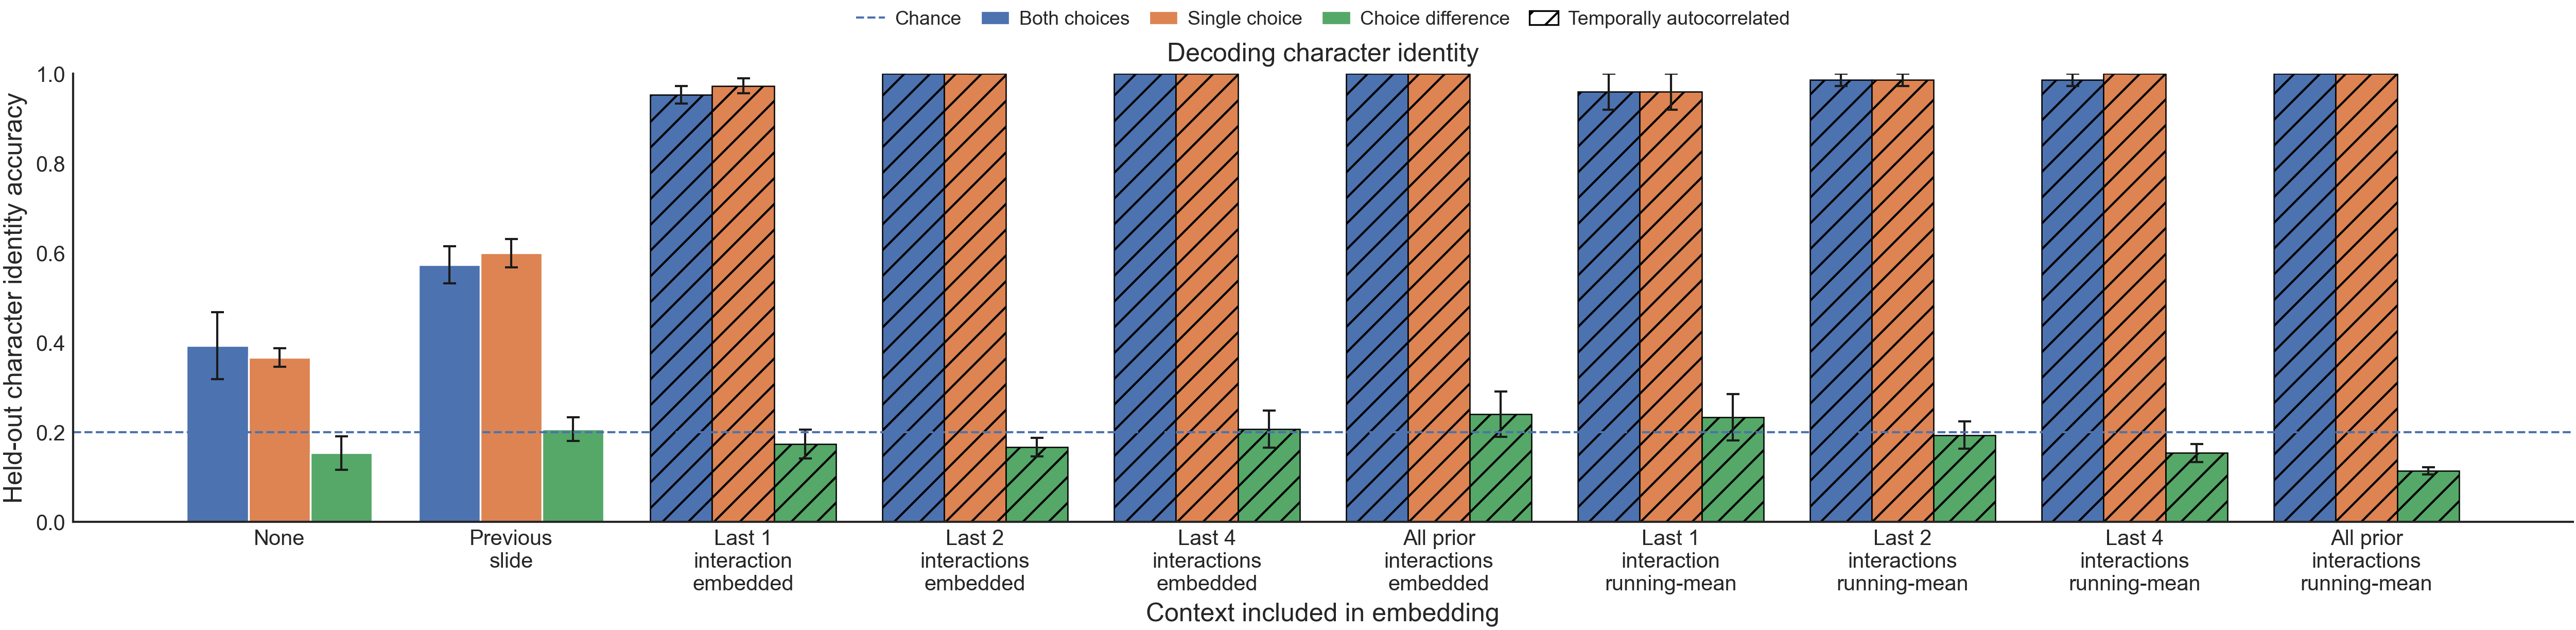

In [ ]:
from matplotlib.patches import Patch


# Select one representation × context
def get_character_decoding_data(
    rep_manifest,
    X,
    rep_type,
    context,
):
    """
    Prepare one representation × context dataset for decoding
    five-character identity.

    For option_diff, retain one canonical vector per decision:
    positive-option embedding minus negative-option embedding.
    """
    X = np.asarray(X)

    if len(rep_manifest) != X.shape[0]:
        raise ValueError(
            "rep_manifest must have exactly one row per row of X."
        )

    mask = (
        rep_manifest["rep_type"].eq(rep_type)
        & rep_manifest["context"].eq(context)
    )

    # The representation table contains both d and -d.
    # Retain positive minus negative as the canonical difference.
    if rep_type == "option_diff":
        mask &= rep_manifest["direction"].eq(1)

    meta = (
        rep_manifest
        .loc[mask]
        .copy()
        .reset_index(drop=True)
    )

    X_rep = X[mask.to_numpy()]

    if len(meta) == 0:
        raise ValueError(
            f"No rows found for rep_type={rep_type}, "
            f"context={context}."
        )

    required_columns = {
        "character",
        "character_decision_num",
        "decision_num",
    }

    missing_columns = (
        required_columns
        - set(meta.columns)
    )

    if missing_columns:
        raise ValueError(
            f"Missing metadata columns: {sorted(missing_columns)}"
        )

    # Two rows per decision for individual options;
    # one row for the other representations.
    expected_rows_per_decision = (
        2 if rep_type == "option" else 1
    )

    rows_per_decision = (
        meta
        .groupby("decision_num")
        .size()
    )

    if not np.all(
        rows_per_decision.to_numpy()
        == expected_rows_per_decision
    ):
        raise ValueError(
            f"{rep_type} should have "
            f"{expected_rows_per_decision} row(s) per decision."
        )

    y = (
        meta["character"]
        .astype(str)
        .to_numpy()
    )

    decision_num = (
        meta["decision_num"]
        .astype(int)
        .to_numpy()
    )

    # CV grouping variable:
    # hold out the same relationship stages across all characters.
    relationship_stage = (
        meta["character_decision_num"]
        .astype(int)
        .to_numpy()
    )

    # Confirm that every relationship stage contains all characters.
    decision_meta = (
        meta[
            [
                "decision_num",
                "character",
                "character_decision_num",
            ]
        ]
        .drop_duplicates("decision_num")
    )

    n_characters = (
        decision_meta["character"].nunique()
    )

    characters_per_stage = (
        decision_meta
        .groupby("character_decision_num")[
            "character"
        ]
        .nunique()
    )

    if not np.all(
        characters_per_stage.to_numpy()
        == n_characters
    ):
        raise ValueError(
            "Each character_decision_num should contain one "
            "decision from every character."
        )

    return (
        X_rep,
        y,
        decision_num,
        relationship_stage,
        meta,
    )

# Model
def make_character_model(C):
    """
    Standardized L2-regularized multinomial logistic regression.
    """
    return Pipeline([
        (
            "scale",
            StandardScaler(),
        ),
        (
            "logistic",
            LogisticRegression(
                C=C,
                penalty="l2",
                solver="lbfgs",
                max_iter=5000,
                random_state=42,
            ),
        ),
    ])

# Decision-level scoring
def decision_level_character_accuracy(
    y,
    class_probabilities,
    decision_num,
    class_labels,
):
    """
    Average predictions across rows belonging to the same decision.

    This puts all representations on the same evaluation unit:
    one predicted character per decision.
    """
    class_probabilities = np.asarray(
        class_probabilities,
        dtype=float,
    )

    class_labels = np.asarray(
        class_labels
    )

    score_df = pd.DataFrame({
        "decision_num": decision_num,
        "character": y,
    })

    probability_columns = []

    for class_index in range(
        class_probabilities.shape[1]
    ):
        column = f"probability_{class_index}"
        probability_columns.append(column)

        score_df[column] = (
            class_probabilities[
                :,
                class_index,
            ]
        )

    label_counts = (
        score_df
        .groupby("decision_num")["character"]
        .nunique()
    )

    if label_counts.max() != 1:
        raise ValueError(
            "Every decision must have exactly one character label."
        )

    aggregation = {
        "character": "first",
    }

    aggregation.update({
        column: "mean"
        for column in probability_columns
    })

    decision_predictions = (
        score_df
        .groupby(
            "decision_num",
            as_index=False,
        )
        .agg(aggregation)
    )

    mean_probabilities = (
        decision_predictions[
            probability_columns
        ]
        .to_numpy()
    )

    predicted_class_indices = (
        np.argmax(
            mean_probabilities,
            axis=1,
        )
    )

    predicted_characters = (
        class_labels[
            predicted_class_indices
        ]
    )

    accuracy = balanced_accuracy_score(
        decision_predictions["character"],
        predicted_characters,
    )

    return float(accuracy)

# Nested cross-validation
def run_character_decoding(
    rep_manifest,
    X,
    contexts=CONTEXT_ORDER,
    rep_types=REPRESENTATION_ORDER,
    c_grid=C_GRID,
):
    """
    Decode five-character identity for each representation × context.

    Outer CV
    --------
    Five-fold GroupKFold by character_decision_num.

    The same relationship stages are held out for all characters,
    so every test fold contains all five character classes.

    Inner CV
    --------
    Three-fold GroupKFold over the remaining relationship stages
    to select regularization strength C.

    Metric
    ------
    Decision-level balanced accuracy.
    """
    c_grid = np.sort(
        np.asarray(
            c_grid,
            dtype=float,
        )
    )

    result_rows = []

    for context in contexts:

        for rep_type in rep_types:

            (
                X_rep,
                y,
                decision_num,
                relationship_stage,
                meta,
            ) = get_character_decoding_data(
                rep_manifest=rep_manifest,
                X=X,
                rep_type=rep_type,
                context=context,
            )

            n_characters = len(
                np.unique(y)
            )

            chance_accuracy = (
                1.0 / n_characters
            )

            outer_cv = GroupKFold(
                n_splits=5
            )

            outer_splits = list(
                outer_cv.split(
                    X_rep,
                    y,
                    groups=relationship_stage,
                )
            )

            for outer_fold, (
                train_idx,
                test_idx,
            ) in enumerate(
                outer_splits,
                start=1,
            ):

                X_train = X_rep[
                    train_idx
                ]

                y_train = y[
                    train_idx
                ]

                train_decisions = decision_num[
                    train_idx
                ]

                train_stages = relationship_stage[
                    train_idx
                ]

                X_test = X_rep[
                    test_idx
                ]

                y_test = y[
                    test_idx
                ]

                test_decisions = decision_num[
                    test_idx
                ]

                test_stages = relationship_stage[
                    test_idx
                ]

                held_out_stages = sorted(
                    np.unique(
                        test_stages
                    ).tolist()
                )

                # -----------------------------------------------------
                # Inner three-fold CV for selecting C
                # -----------------------------------------------------

                inner_cv = GroupKFold(
                    n_splits=3
                )

                inner_splits = list(
                    inner_cv.split(
                        X_train,
                        y_train,
                        groups=train_stages,
                    )
                )

                best_C = None
                best_inner_accuracy = -np.inf

                for C in c_grid:

                    inner_accuracies = []

                    for (
                        inner_train_idx,
                        inner_valid_idx,
                    ) in inner_splits:

                        model = make_character_model(
                            C
                        )

                        model.fit(
                            X_train[
                                inner_train_idx
                            ],
                            y_train[
                                inner_train_idx
                            ],
                        )

                        valid_probabilities = (
                            model.predict_proba(
                                X_train[
                                    inner_valid_idx
                                ]
                            )
                        )

                        class_labels = (
                            model
                            .named_steps["logistic"]
                            .classes_
                        )

                        inner_accuracy = (
                            decision_level_character_accuracy(
                                y=y_train[
                                    inner_valid_idx
                                ],
                                class_probabilities=(
                                    valid_probabilities
                                ),
                                decision_num=(
                                    train_decisions[
                                        inner_valid_idx
                                    ]
                                ),
                                class_labels=(
                                    class_labels
                                ),
                            )
                        )

                        inner_accuracies.append(
                            inner_accuracy
                        )

                    mean_inner_accuracy = float(
                        np.mean(
                            inner_accuracies
                        )
                    )

                    # c_grid is sorted, so ties keep the smaller C.
                    if (
                        mean_inner_accuracy
                        > best_inner_accuracy
                    ):
                        best_inner_accuracy = (
                            mean_inner_accuracy
                        )

                        best_C = float(C)

                # -----------------------------------------------------
                # Refit on all training stages and score held-out stages
                # -----------------------------------------------------

                final_model = make_character_model(
                    best_C
                )

                final_model.fit(
                    X_train,
                    y_train,
                )

                test_probabilities = (
                    final_model.predict_proba(
                        X_test
                    )
                )

                class_labels = (
                    final_model
                    .named_steps["logistic"]
                    .classes_
                )

                test_accuracy = (
                    decision_level_character_accuracy(
                        y=y_test,
                        class_probabilities=(
                            test_probabilities
                        ),
                        decision_num=test_decisions,
                        class_labels=class_labels,
                    )
                )

                result_rows.append({
                    "context": context,
                    "rep_type": rep_type,
                    "outer_fold": outer_fold,
                    "held_out_stages": ",".join(
                        map(
                            str,
                            held_out_stages,
                        )
                    ),
                    "accuracy": test_accuracy,
                    "chance_accuracy": (
                        chance_accuracy
                    ),
                    "best_C": best_C,
                    "best_inner_accuracy": (
                        best_inner_accuracy
                    ),
                    "n_train_decisions": len(
                        np.unique(
                            train_decisions
                        )
                    ),
                    "n_test_decisions": len(
                        np.unique(
                            test_decisions
                        )
                    ),
                })

    fold_results = pd.DataFrame(
        result_rows
    )

    summary = (
        fold_results
        .groupby(
            [
                "context",
                "rep_type",
            ],
            as_index=False,
        )
        .agg(
            mean_accuracy=(
                "accuracy",
                "mean",
            ),
            sd_accuracy=(
                "accuracy",
                "std",
            ),
            n_folds=(
                "accuracy",
                "count",
            ),
            chance_accuracy=(
                "chance_accuracy",
                "first",
            ),
            median_best_C=(
                "best_C",
                "median",
            ),
        )
    )

    summary["sem_accuracy"] = (
        summary["sd_accuracy"]
        / np.sqrt(
            summary["n_folds"]
        )
    )

    context_rank = {
        context: index
        for index, context in enumerate(
            contexts
        )
    }

    representation_rank = {
        rep_type: index
        for index, rep_type in enumerate(
            rep_types
        )
    }

    summary["_context_rank"] = (
        summary["context"].map(
            context_rank
        )
    )

    summary["_representation_rank"] = (
        summary["rep_type"].map(
            representation_rank
        )
    )

    summary = (
        summary
        .sort_values(
            [
                "_context_rank",
                "_representation_rank",
            ]
        )
        .drop(
            columns=[
                "_context_rank",
                "_representation_rank",
            ]
        )
        .reset_index(drop=True)
    )

    return fold_results, summary

# Plot
def plot_character_decoding(
    summary,
    contexts=CONTEXT_ORDER,
    rep_types=REPRESENTATION_ORDER,
):
    """
    Grouped bar plot of held-out character-identity accuracy.

    Error bars are SEM across the five outer folds.
    """
    x = np.arange(
        len(contexts)
    )

    n_rep_types = len(
        rep_types
    )

    bar_width = (
        0.8 / n_rep_types
    )

    # Scale the canvas to the number of context groups. This preserves
    # the standard grouped-bar proportions without excess white space.
    figure_width = (
        2 + 1.5 * len(contexts)
    )

    fig, ax = plt.subplots(
        figsize=(figure_width, 4.5)
    )

    for rep_index, rep_type in enumerate(
        rep_types
    ):

        rep_summary = (
            summary
            .loc[
                summary["rep_type"].eq(
                    rep_type
                )
            ]
            .set_index("context")
            .reindex(contexts)
        )

        offset = (
            rep_index
            - (n_rep_types - 1) / 2
        ) * bar_width

        bars = ax.bar(
            x + offset,
            rep_summary[
                "mean_accuracy"
            ].to_numpy(),
            width=bar_width,
            yerr=rep_summary[
                "sem_accuracy"
            ].to_numpy(),
            capsize=3,
            label=(
                REPRESENTATION_LABELS.get(
                    rep_type,
                    rep_type,
                )
            ),
        )

        for bar, context in zip(
            bars,
            contexts,
        ):
            if context.startswith((
                "text_history_",
                "mean_history_",
            )):
                bar.set_hatch("//")
                bar.set_edgecolor("black")
                bar.set_linewidth(0.6)

    chance_accuracy = float(
        summary[
            "chance_accuracy"
        ].iloc[0]
    )

    ax.axhline(
        chance_accuracy,
        linestyle="--",
        linewidth=1,
        label="Chance",
    )

    ax.set_xticks(
        x,
        [
            CONTEXT_LABELS.get(
                context,
                context,
            )
            for context in contexts
        ],
    )

    ax.set_ylim(
        0,
        1,
    )

    ax.set_ylabel(
        "Held-out character identity accuracy"
    )

    ax.set_xlabel(
        "Context included in embedding"
    )

    ax.set_title(
        "Decoding character identity"
    )

    legend_handles, _ = (
        ax.get_legend_handles_labels()
    )
    legend_handles.append(
        Patch(
            facecolor="white",
            edgecolor="black",
            hatch="//",
            label="Temporally autocorrelated",
        )
    )

    ax.legend(
        handles=legend_handles,
        frameon=False,
        ncols=5,
        fontsize=9,
        columnspacing=1.0,
        handlelength=1.5,
        handletextpad=0.5,
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            1.18,
        ),
    )

    fig.tight_layout()
    plt.show()

character_fold_results, character_summary = (
    run_character_decoding(
        rep_manifest=rep_manifest,
        X=X,
    )
)

plot_character_decoding(
    character_summary
)

<h1 align=center> RSA decomposition with interpretable features </h1>

Q: What latent variables best explain the geometry of this embedding space?

In [9]:
snt_df.columns

Index(['slide_num', 'trial_num', 'cogent_ref', 'onset', 'offset', 'duration',
       'narrative_num', 'decision_num', 'slide_type', 'first', 'second',
       'assistant', 'powerful', 'boss', 'neutral', 'character_role_name',
       'character_role_num', 'character_decision_num', 'dimension', 'scene',
       'text', 'opt1_text', 'opt2_text', 'opt1_affil', 'opt2_affil',
       'opt1_power', 'opt2_power', 'notes'],
      dtype='object')

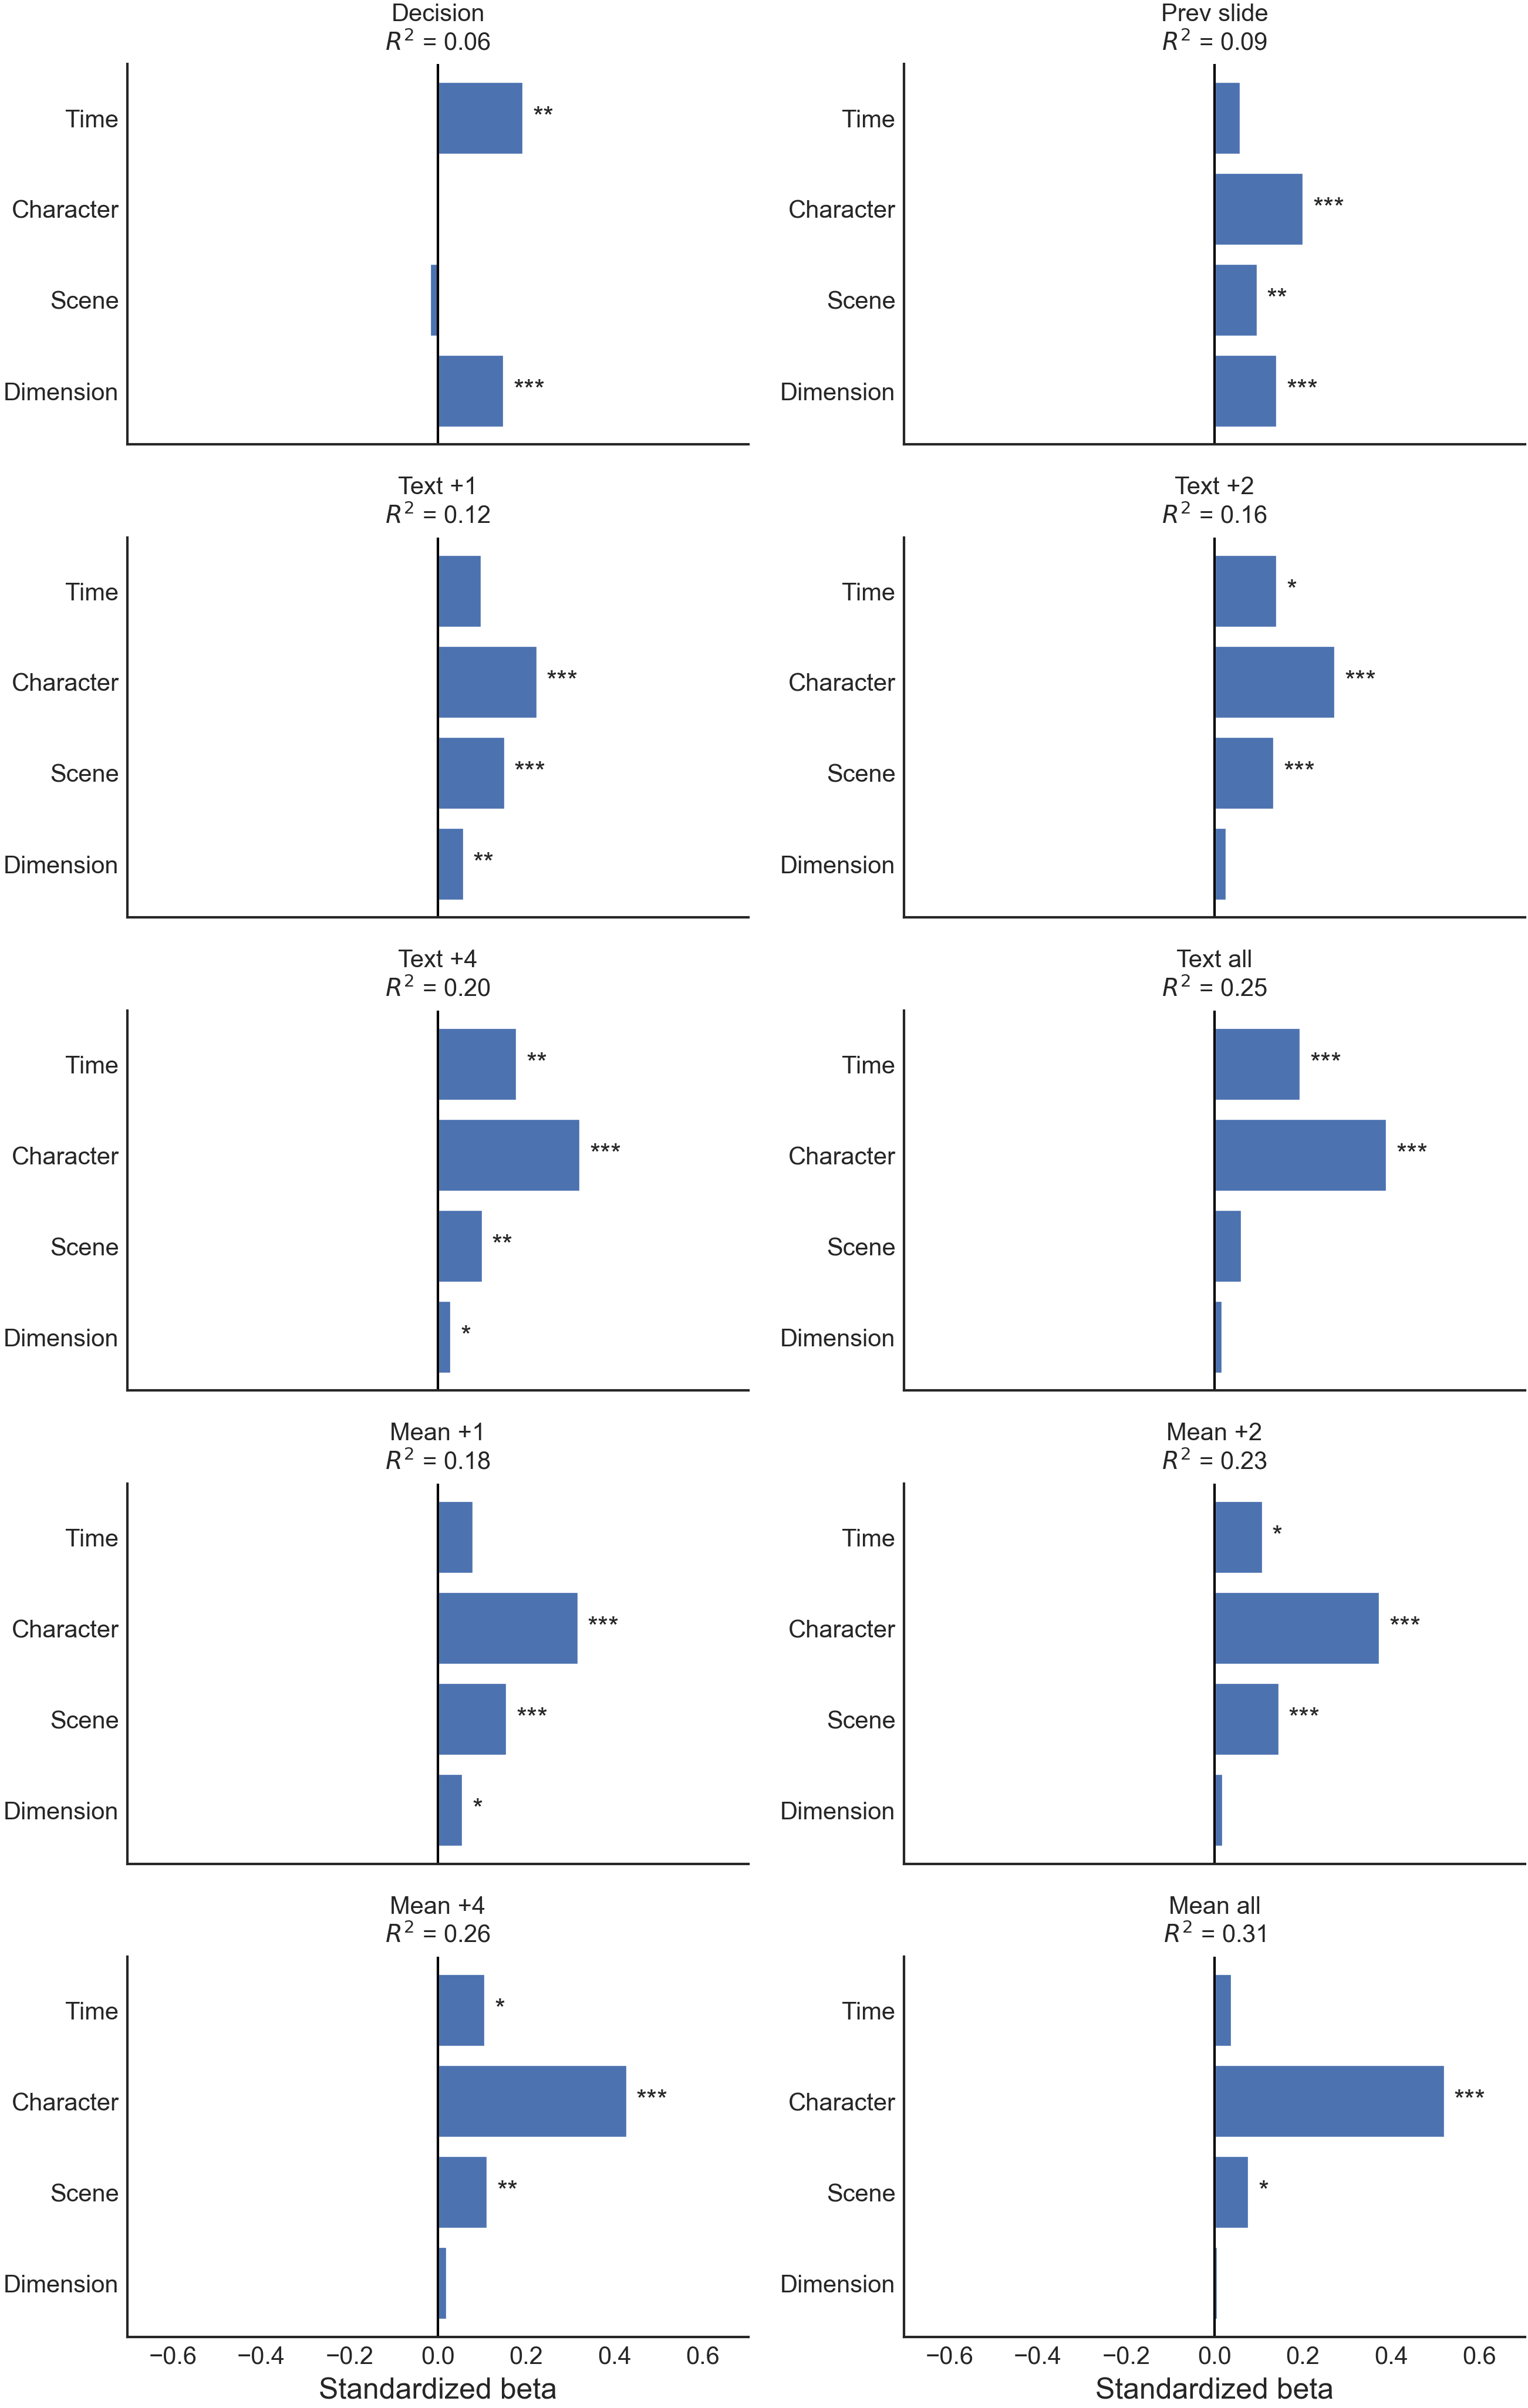

,representation,predictor,beta,p,R2
0,Decision,Time,0.1931,0.0020,0.0571
1,Decision,Character,0.0002,0.9908,0.0571
2,Decision,Scene,-0.0187,0.6139,0.0571
3,Decision,Dimension,0.1495,0.0002,0.0571
4,Prev slide,Time,0.0589,0.2611,0.0895
5,Prev slide,Character,0.2013,0.0002,0.0895
6,Prev slide,Scene,0.0965,0.0028,0.0895
7,Prev slide,Dimension,0.1411,0.0002,0.0895
8,Text +1,Time,0.0980,0.0694,0.1217
9,Text +1,Character,0.2246,0.0002,0.1217


In [11]:
# =============================================================================
# Regression RSA across embedding representations
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist, squareform

# =============================================================================
# Settings
# =============================================================================

REP_TYPE = "choice_pair_mean"

REPRESENTATIONS = [
    ("none",              "Decision"),
    ("previous_slide",    "Prev slide"),
    ("text_history_1",    "Text +1"),
    ("text_history_2",    "Text +2"),
    ("text_history_4",    "Text +4"),
    ("text_history_all",  "Text all"),
    ("mean_history_1",    "Mean +1"),
    ("mean_history_2",    "Mean +2"),
    ("mean_history_4",    "Mean +4"),
    ("mean_history_all",  "Mean all"),
]

TIME_COL = "decision_num"

N_PERMUTATIONS = 5000
RANDOM_SEED = 1

# =============================================================================
# Helpers
# =============================================================================

def zscore(x):
    x = np.asarray(x, float)
    return (x - x.mean()) / x.std(ddof=1)


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


# =============================================================================
# Build trial table
# =============================================================================

trial_df = (
    choices
    .sort_values("decision_num")
    .reset_index(drop=True)
)

n_trials = len(trial_df)

ii, jj = np.triu_indices(n_trials, k=1)

# =============================================================================
# Model RDVs (same for every representation)
# =============================================================================

time = trial_df[TIME_COL].to_numpy(float)

character = trial_df["character"].astype(str).to_numpy()

scene = trial_df["scene"].astype(str).to_numpy()

dimension = trial_df["dimension"].astype(str).to_numpy()

predictors = {
    "Time":
        np.abs(time[ii] - time[jj]),

    "Character":
        (character[ii] != character[jj]).astype(float),

    "Scene":
        (scene[ii] != scene[jj]).astype(float),

    "Dimension":
        (dimension[ii] != dimension[jj]).astype(float),
}

X_design = np.column_stack(
    [
        zscore(v)
        for v in predictors.values()
    ]
)

X_design = np.column_stack(
    [
        np.ones(len(X_design)),
        X_design,
    ]
)

pinv = np.linalg.pinv(X_design)

# =============================================================================
# Permutations (shared across representations)
# =============================================================================

rng = np.random.default_rng(RANDOM_SEED)

permutations = [
    rng.permutation(n_trials)
    for _ in range(N_PERMUTATIONS)
]

# =============================================================================
# Run regression RSA
# =============================================================================

summary = []

betas_all = []

pvals_all = []

r2_all = []

for context, label in REPRESENTATIONS:

    mask = (
        (rep_manifest["context"] == context)
        &
        (rep_manifest["rep_type"] == REP_TYPE)
    )

    manifest = rep_manifest.loc[mask].copy()

    embeddings = X[mask.to_numpy()]

    manifest = (
        manifest
        .sort_values("decision_num")
        .reset_index(drop=True)
    )

    embeddings = embeddings[
        np.argsort(
            manifest["decision_num"].to_numpy(),
            kind="stable",
        )
    ]

    # -------------------------------------------------------------------------
    # Safety check
    # -------------------------------------------------------------------------

    if not np.all(
        manifest["decision_num"].to_numpy()
        ==
        trial_df["decision_num"].to_numpy()
    ):
        raise ValueError(
            f"{context}: decision ordering mismatch."
        )

    # -------------------------------------------------------------------------
    # Semantic DSM
    # -------------------------------------------------------------------------

    dsm = squareform(
        pdist(
            embeddings,
            metric="cosine",
        )
    )

    y = zscore(
        dsm[ii, jj]
    )

    coef = pinv @ y

    beta = coef[1:]

    yhat = X_design @ coef

    r2 = (
        1
        -
        np.sum((y - yhat) ** 2)
        /
        np.sum((y - y.mean()) ** 2)
    )

    # -------------------------------------------------------------------------
    # Permutations
    # -------------------------------------------------------------------------

    null_beta = np.zeros(
        (
            N_PERMUTATIONS,
            len(beta),
        )
    )

    for p, perm in enumerate(permutations):

        y_perm = zscore(
            dsm[np.ix_(perm, perm)][ii, jj]
        )

        coef_perm = pinv @ y_perm

        null_beta[p] = coef_perm[1:]

    pvals = (
        1
        +
        np.sum(
            np.abs(null_beta)
            >=
            np.abs(beta),
            axis=0,
        )
    ) / (N_PERMUTATIONS + 1)

    summary.append(
        pd.DataFrame(
            {
                "representation": label,
                "predictor": list(predictors.keys()),
                "beta": beta,
                "p": pvals,
                "R2": r2,
            }
        )
    )

    betas_all.append(beta)
    pvals_all.append(pvals)
    r2_all.append(r2)

summary = pd.concat(summary, ignore_index=True)

# =============================================================================
# Plot
# =============================================================================

fig, axes = plt.subplots(
    5,
    2,
    figsize=(9, 14),
    sharex=True,
)

axes = axes.ravel()

xlim = np.max(np.abs(summary["beta"])) * 1.35
xlim = max(xlim, 0.15)

for ax, (context, label), beta, pvals, r2 in zip(
    axes,
    REPRESENTATIONS,
    betas_all,
    pvals_all,
    r2_all,
):

    y = np.arange(len(beta))[::-1]

    ax.barh(
        y,
        beta,
    )

    ax.axvline(
        0,
        color="black",
        linewidth=1,
    )

    ax.set_xlim(
        -xlim,
        xlim,
    )

    ax.set_yticks(y)

    ax.set_yticklabels(
        list(predictors.keys())
    )

    ax.set_title(
        f"{label}\n$R^2$ = {r2:.2f}",
        fontsize=10,
    )

    for yy, b, p in zip(
        y,
        beta,
        pvals,
    ):

        if b >= 0:
            xpos = b + xlim * 0.03
            ha = "left"
        else:
            xpos = b - xlim * 0.03
            ha = "right"

        ax.text(
            xpos,
            yy,
            p_to_stars(p),
            va="center",
            ha=ha,
            fontsize=11,
        )

axes[-2].set_xlabel("Standardized beta")
axes[-1].set_xlabel("Standardized beta")

plt.tight_layout()

plt.show()

# =============================================================================
# Summary table
# =============================================================================

display(
    summary.round(4)
)

<h1 align=center> Project embeddings into social subspace </h1>

## Can we recover our most important assumptions in semantic space?

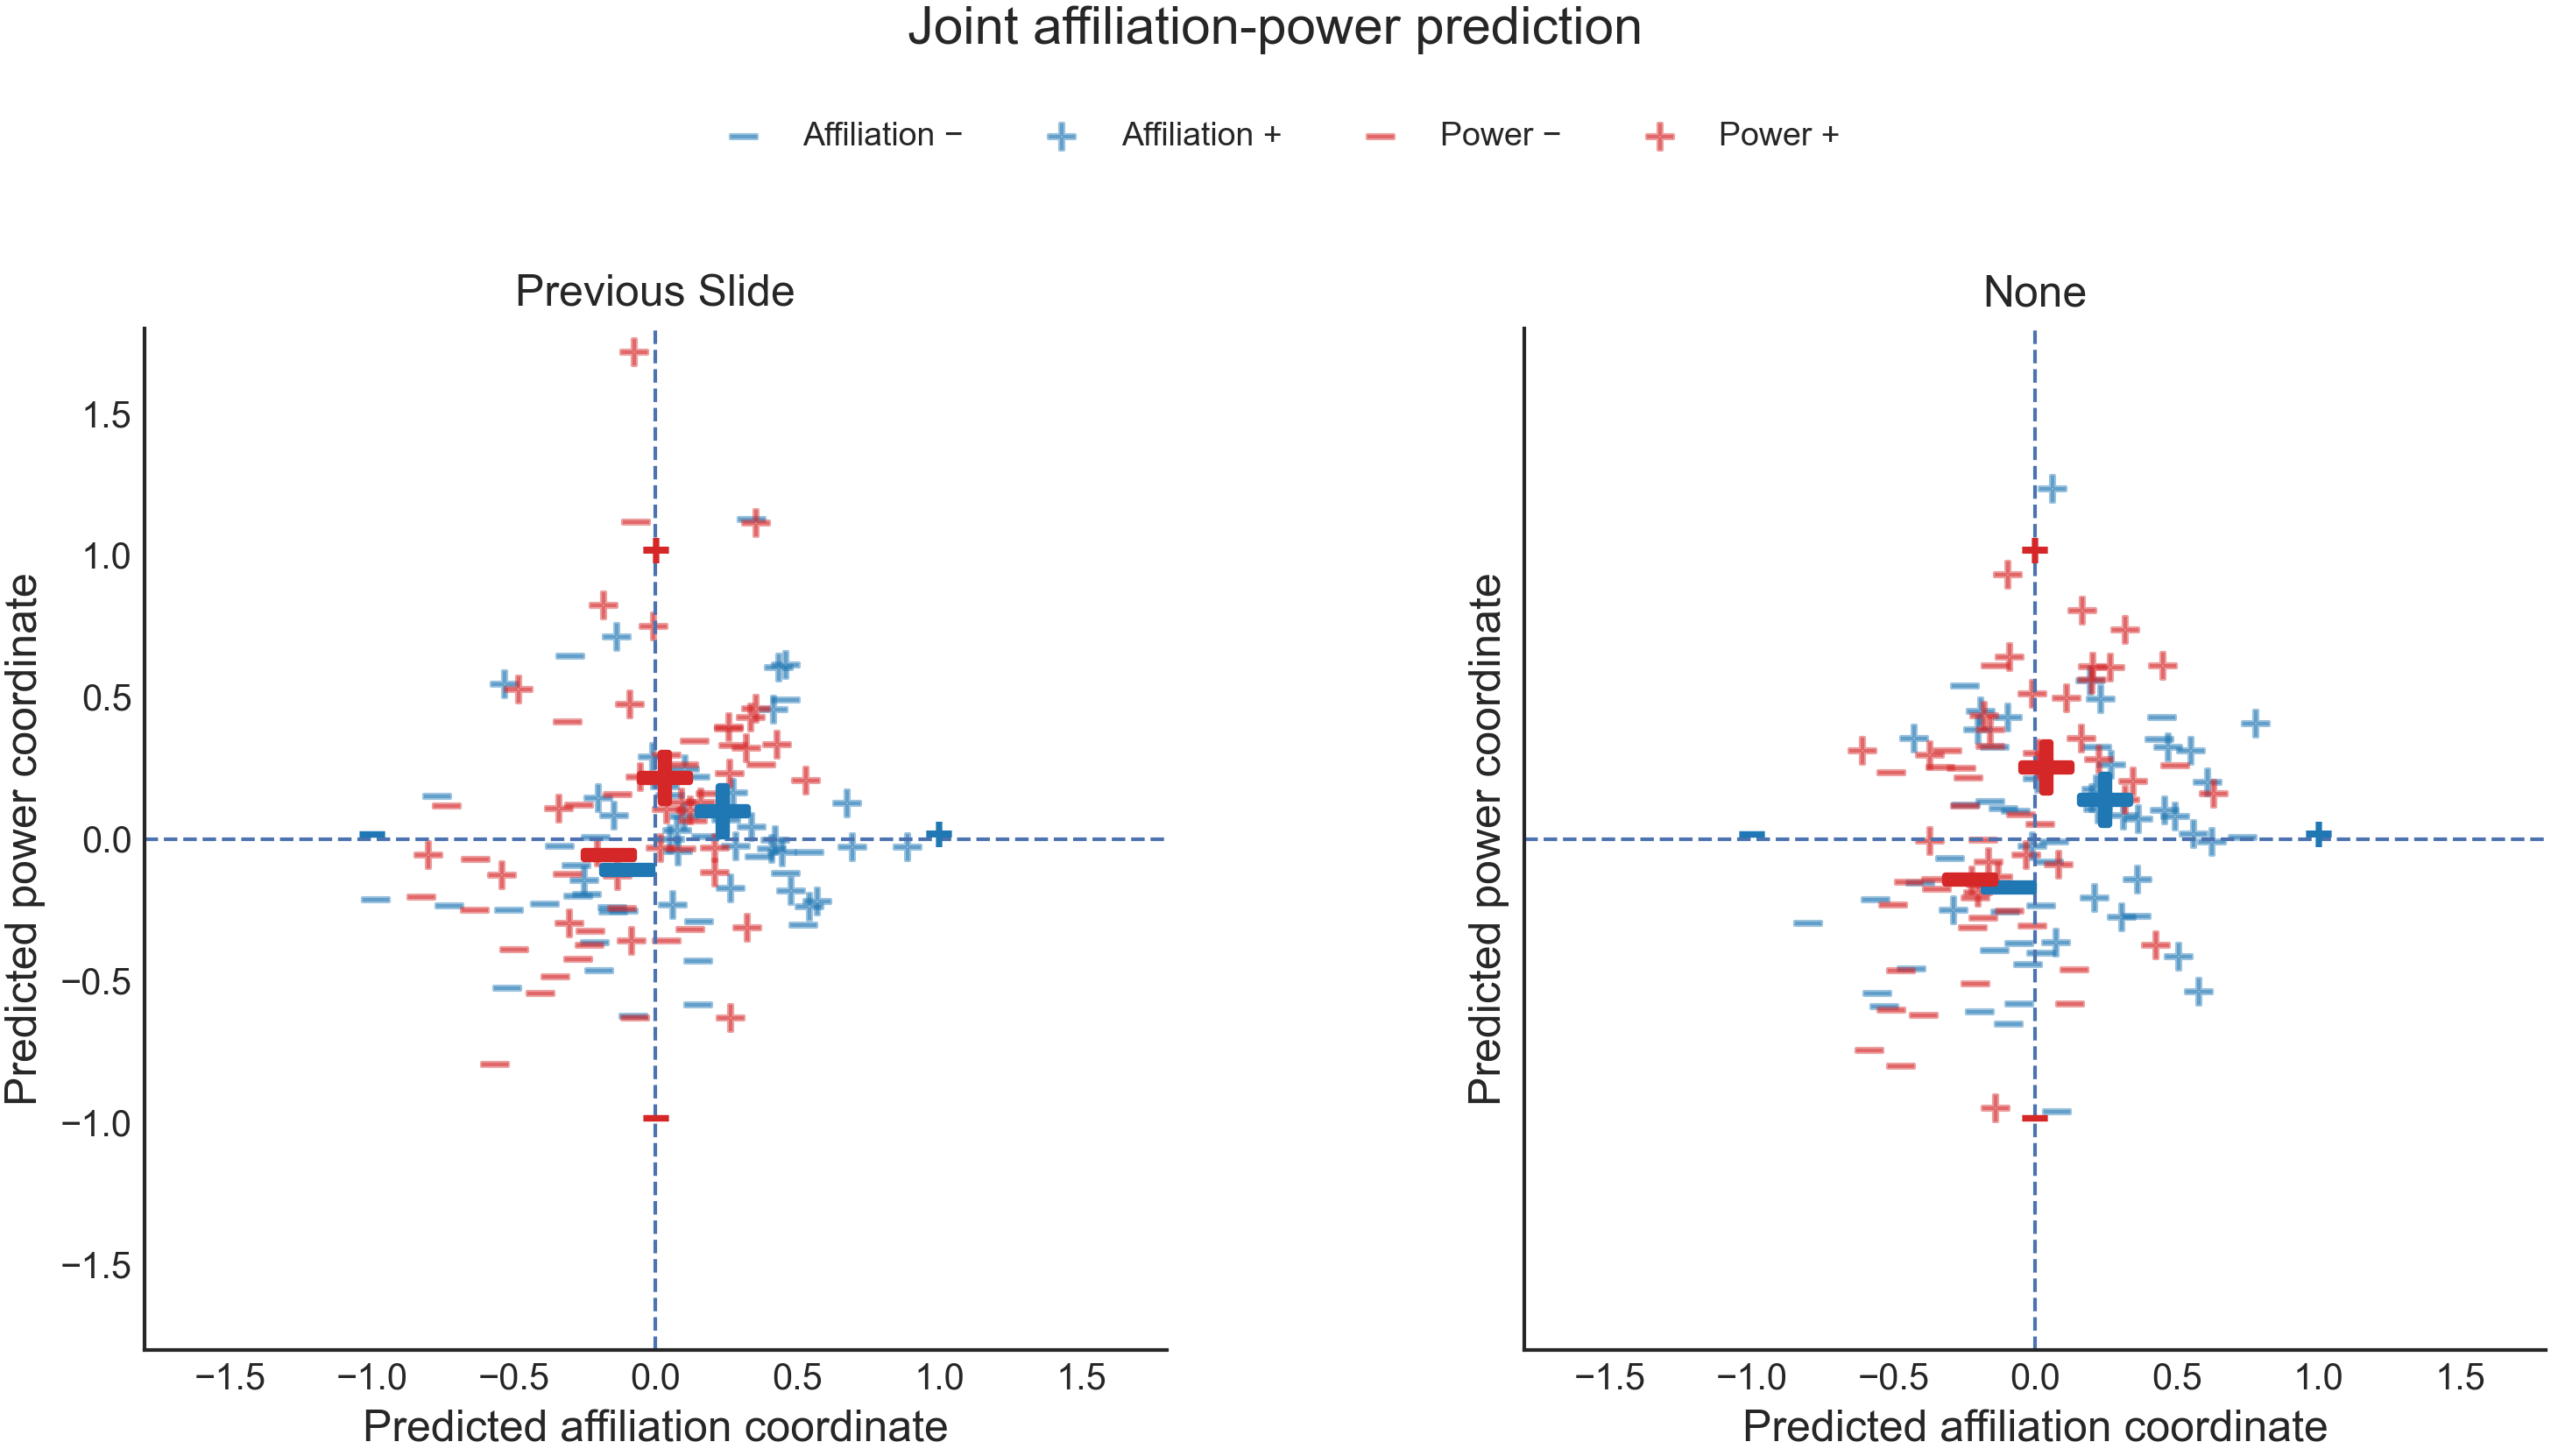

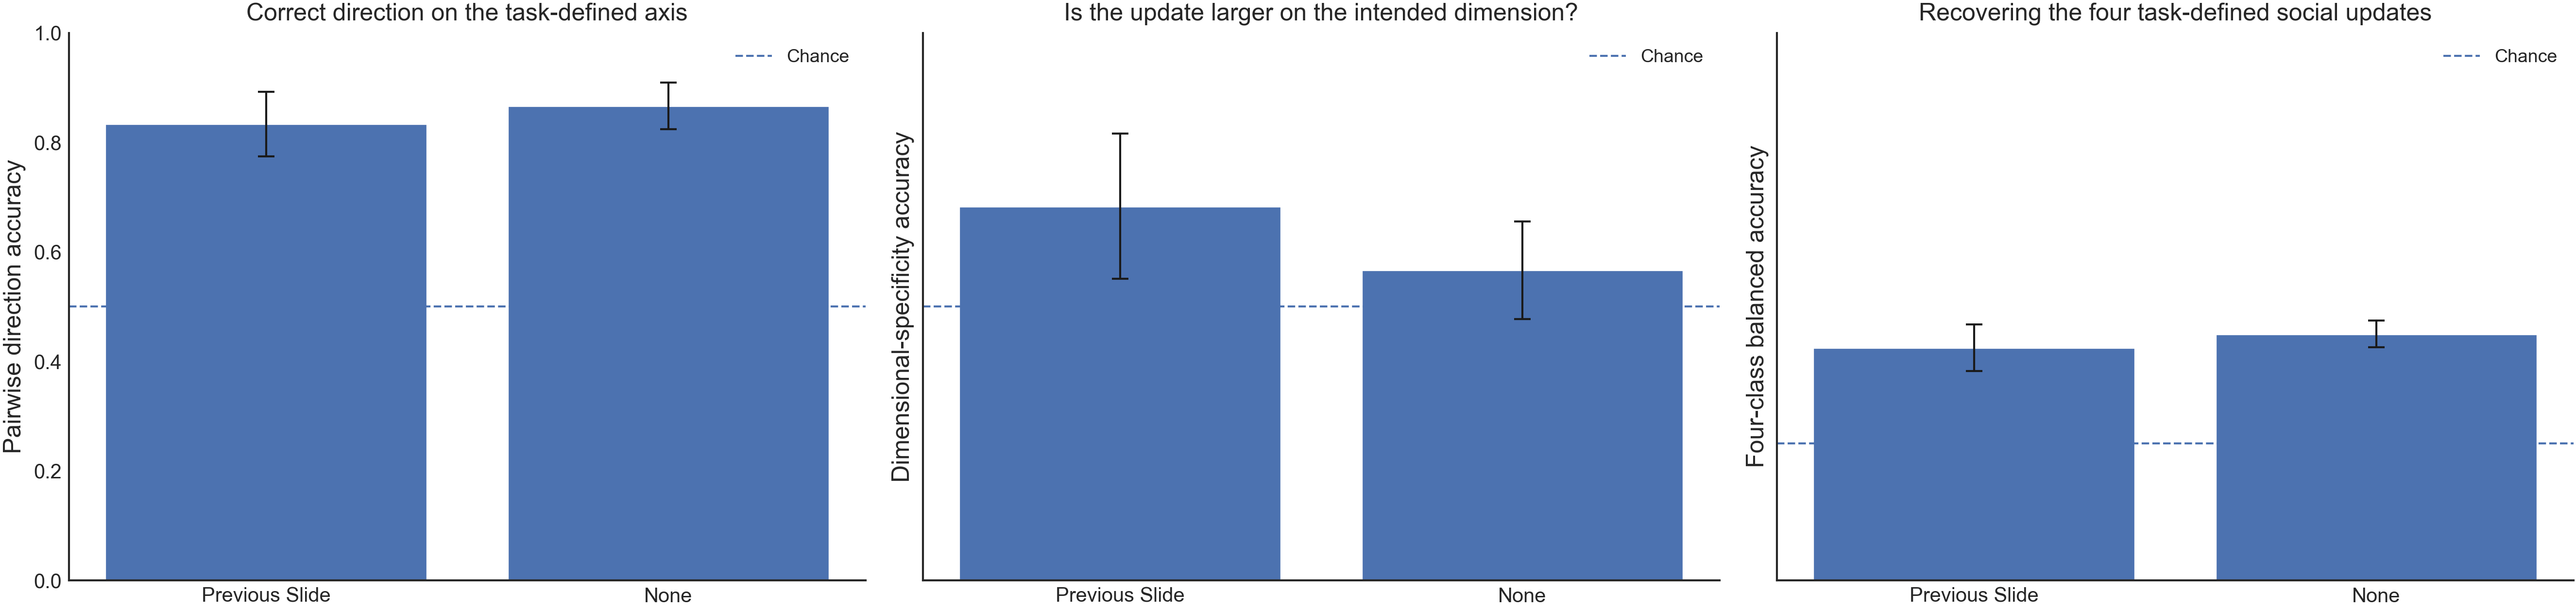

In [20]:
from itertools import combinations
from sklearn.linear_model import Ridge
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# =============================================================================
# SETTINGS
# =============================================================================

SOCIAL_SPACE_CONTEXTS = (
    "previous_slide",  # primary
    "none",            # sensitivity analysis
)

RIDGE_ALPHA_GRID = np.logspace(
    -4,
    4,
    17,
)

CLASS_NAMES = np.array([
    "affiliation_negative",
    "affiliation_positive",
    "power_negative",
    "power_positive",
])

CLASS_PROTOTYPES = np.array([
    [-1.0,  0.0],
    [ 1.0,  0.0],
    [ 0.0, -1.0],
    [ 0.0,  1.0],
])


# =============================================================================
# PREPARE INDIVIDUAL-CHOICE EMBEDDINGS AND TARGET COORDINATES
# =============================================================================

def prepare_social_space_data(
    rep_manifest,
    X,
    context,
):
    """
    Select identity-masked individual-option embeddings and assign
    their task-defined affiliation and power targets.

    Returns
    -------
    X_context : ndarray, shape (n_options, embedding_dim)

    metadata : DataFrame
        One row per individual option.

    targets : ndarray, shape (n_options, 2)
        Columns are:
            0 = affiliation target
            1 = power target

    groups : ndarray
        Character identity used for grouped cross-validation.
    """
    X = np.asarray(X)

    if len(rep_manifest) != X.shape[0]:
        raise ValueError(
            "rep_manifest must align row-for-row with X."
        )

    required_columns = {
        "context",
        "rep_type",
        "decision_num",
        "character",
        "dimension",
        "option_idx",
        "direction",
    }

    missing = required_columns - set(
        rep_manifest.columns
    )

    if missing:
        raise ValueError(
            f"Missing rep_manifest columns: {sorted(missing)}"
        )

    mask = (
        rep_manifest["context"].eq(context)
        & rep_manifest["rep_type"].eq("option")
    )

    selected_rows = np.flatnonzero(
        mask.to_numpy()
    )

    metadata = (
        rep_manifest
        .loc[mask]
        .copy()
    )

    metadata["_x_row"] = selected_rows

    metadata = (
        metadata
        .sort_values(
            [
                "character",
                "character_decision_num",
                "decision_num",
                "option_idx",
            ]
        )
        .reset_index(drop=True)
    )

    X_context = X[
        metadata["_x_row"].to_numpy()
    ]

    if len(metadata) == 0:
        raise ValueError(
            f"No individual-option embeddings found for '{context}'."
        )

    # Ensure that only masked embeddings are being analyzed.
    if "text_variant" in metadata.columns:

        variants = set(
            metadata["text_variant"]
            .dropna()
            .astype(str)
        )

        if variants != {"identity_masked"}:
            raise ValueError(
                "The selected embeddings are not exclusively "
                f"identity-masked: {variants}"
            )

    metadata["direction"] = pd.to_numeric(
        metadata["direction"],
        errors="coerce",
    )

    if set(metadata["dimension"].unique()) != {
        "affil",
        "power",
    }:
        raise ValueError(
            "Expected only 'affil' and 'power' dimensions."
        )

    if set(metadata["direction"].unique()) != {
        -1,
        1,
    }:
        raise ValueError(
            "Expected direction labels -1 and +1."
        )

    # Each decision should contribute exactly two options.
    rows_per_decision = (
        metadata
        .groupby("decision_num")
        .size()
    )

    if not rows_per_decision.eq(2).all():
        raise ValueError(
            "Each decision must contribute exactly two options."
        )

    targets = np.zeros(
        (len(metadata), 2),
        dtype=float,
    )

    affiliation_mask = (
        metadata["dimension"]
        .eq("affil")
        .to_numpy()
    )

    power_mask = (
        metadata["dimension"]
        .eq("power")
        .to_numpy()
    )

    direction = (
        metadata["direction"]
        .to_numpy(dtype=float)
    )

    targets[
        affiliation_mask,
        0,
    ] = direction[
        affiliation_mask
    ]

    targets[
        power_mask,
        1,
    ] = direction[
        power_mask
    ]

    metadata["target_affil"] = (
        targets[:, 0]
    )

    metadata["target_power"] = (
        targets[:, 1]
    )

    metadata["true_class"] = np.select(
        [
            metadata["dimension"].eq("affil")
            & metadata["direction"].eq(-1),

            metadata["dimension"].eq("affil")
            & metadata["direction"].eq(1),

            metadata["dimension"].eq("power")
            & metadata["direction"].eq(-1),

            metadata["dimension"].eq("power")
            & metadata["direction"].eq(1),
        ],
        CLASS_NAMES,
        default="unknown",
    )

    groups = (
        metadata["character"]
        .astype(str)
        .to_numpy()
    )

    return (
        X_context,
        metadata,
        targets,
        groups,
    )


# =============================================================================
# MODEL
# =============================================================================

def make_social_space_model(alpha):
    """
    Two-output ridge regression:

        embedding -> [affiliation, power]
    """
    return Pipeline([
        (
            "scale",
            StandardScaler(),
        ),
        (
            "ridge",
            Ridge(
                alpha=float(alpha),
                fit_intercept=True,
            ),
        ),
    ])


def mean_euclidean_error(
    true_coordinates,
    predicted_coordinates,
):
    """
    Mean Euclidean distance in affiliation-power space.
    """
    return float(
        np.mean(
            np.linalg.norm(
                predicted_coordinates
                - true_coordinates,
                axis=1,
            )
        )
    )


def choose_ridge_alpha(
    X_train,
    y_train,
    character_groups,
    alpha_grid=RIDGE_ALPHA_GRID,
    n_inner_folds=3,
):
    """
    Select ridge regularization using grouped inner cross-validation.

    The validation objective is mean Euclidean coordinate error.
    """
    unique_groups = np.unique(
        character_groups
    )

    if len(unique_groups) < n_inner_folds:
        raise ValueError(
            "Not enough character groups for the requested "
            "number of inner folds."
        )

    inner_cv = GroupKFold(
        n_splits=n_inner_folds
    )

    alpha_rows = []

    best_alpha = None
    best_error = np.inf

    for alpha in np.sort(
        np.asarray(
            alpha_grid,
            dtype=float,
        )
    ):

        fold_errors = []

        for (
            inner_train_index,
            inner_valid_index,
        ) in inner_cv.split(
            X_train,
            y_train,
            groups=character_groups,
        ):

            model = make_social_space_model(
                alpha
            )

            model.fit(
                X_train[inner_train_index],
                y_train[inner_train_index],
            )

            prediction = model.predict(
                X_train[inner_valid_index]
            )

            error = mean_euclidean_error(
                y_train[inner_valid_index],
                prediction,
            )

            fold_errors.append(
                error
            )

        mean_error = float(
            np.mean(fold_errors)
        )

        alpha_rows.append({
            "alpha": float(alpha),
            "mean_inner_error": mean_error,
        })

        # If errors are effectively tied, choose the more regularized model.
        if (
            mean_error < best_error - 1e-12
            or (
                np.isclose(
                    mean_error,
                    best_error,
                )
                and (
                    best_alpha is None
                    or alpha > best_alpha
                )
            )
        ):
            best_error = mean_error
            best_alpha = float(alpha)

    return (
        best_alpha,
        best_error,
        pd.DataFrame(alpha_rows),
    )


# =============================================================================
# AXIS EXTRACTION
# =============================================================================

def extract_effective_axes(model):
    """
    Convert pipeline coefficients back into the original embedding space.

    This permits comparison of learned affiliation and power directions
    across folds despite fold-specific feature standardization.
    """
    scaler = model.named_steps[
        "scale"
    ]

    ridge = model.named_steps[
        "ridge"
    ]

    coefficients = np.asarray(
        ridge.coef_,
        dtype=float,
    )

    scale = np.asarray(
        scaler.scale_,
        dtype=float,
    ).copy()

    scale[
        np.isclose(scale, 0)
    ] = 1.0

    effective_coefficients = (
        coefficients
        / scale[None, :]
    )

    axis_norms = np.linalg.norm(
        effective_coefficients,
        axis=1,
        keepdims=True,
    )

    if np.any(
        np.isclose(axis_norms, 0)
    ):
        raise ValueError(
            "A fitted semantic axis has zero length."
        )

    normalized_axes = (
        effective_coefficients
        / axis_norms
    )

    original_intercept = (
        np.asarray(
            ridge.intercept_,
            dtype=float,
        )
        - (
            scaler.mean_
            / scale
        )
        @ coefficients.T
    )

    return {
        "affil_axis": normalized_axes[0],
        "power_axis": normalized_axes[1],
        "affil_intercept": float(
            original_intercept[0]
        ),
        "power_intercept": float(
            original_intercept[1]
        ),
    }


# =============================================================================
# ANNOTATE OUT-OF-FOLD PREDICTIONS
# =============================================================================

def annotate_social_space_predictions(
    metadata,
    predictions,
):
    """
    Add predicted coordinates, dimensional-specificity scores, and
    four-class predictions.
    """
    output = metadata.copy()

    predictions = np.asarray(
        predictions,
        dtype=float,
    )

    output["pred_affil"] = (
        predictions[:, 0]
    )

    output["pred_power"] = (
        predictions[:, 1]
    )

    true_coordinates = output[
        [
            "target_affil",
            "target_power",
        ]
    ].to_numpy(dtype=float)

    output["euclidean_error"] = (
        np.linalg.norm(
            predictions
            - true_coordinates,
            axis=1,
        )
    )

    affiliation_rows = (
        output["dimension"]
        .eq("affil")
        .to_numpy()
    )

    output["active_prediction"] = np.where(
        affiliation_rows,
        output["pred_affil"],
        output["pred_power"],
    )

    output["off_axis_prediction"] = np.where(
        affiliation_rows,
        output["pred_power"],
        output["pred_affil"],
    )

    output["signed_active_margin"] = (
        output["direction"]
        * output["active_prediction"]
    )

    output["row_direction_correct"] = np.where(
        output["signed_active_margin"] > 1e-12,
        1.0,
        np.where(
            output["signed_active_margin"] < -1e-12,
            0.0,
            0.5,
        ),
    )

    output["specificity_margin"] = (
        np.abs(
            output["active_prediction"]
        )
        - np.abs(
            output["off_axis_prediction"]
        )
    )

    output["row_specificity_correct"] = np.where(
        output["specificity_margin"] > 1e-12,
        1.0,
        np.where(
            output["specificity_margin"] < -1e-12,
            0.0,
            0.5,
        ),
    )

    distances_to_classes = np.linalg.norm(
        predictions[:, None, :]
        - CLASS_PROTOTYPES[None, :, :],
        axis=2,
    )

    predicted_class_index = np.argmin(
        distances_to_classes,
        axis=1,
    )

    output["predicted_class"] = (
        CLASS_NAMES[
            predicted_class_index
        ]
    )

    output["four_class_correct"] = (
        output["predicted_class"]
        == output["true_class"]
    ).astype(float)

    return output


# =============================================================================
# PAIR-LEVEL VALIDATION
# =============================================================================

def make_choice_pair_table(
    prediction_df,
):
    """
    Compare the positive and negative option for every decision.

    Core assumptions tested
    -----------------------
    1. The positive option lies above the negative option on the
       task-labeled dimension.

    2. The option contrast is larger on the target dimension than on
       the off-axis dimension.
    """
    pair_rows = []

    group_columns = [
        "context",
        "fold",
        "held_out_character",
        "character",
        "decision_num",
    ]

    for keys, group in prediction_df.groupby(
        group_columns,
        sort=False,
    ):

        if (
            len(group) != 2
            or set(group["direction"]) != {-1, 1}
        ):
            raise ValueError(
                "Each decision must contain exactly one positive "
                "and one negative option."
            )

        positive = (
            group.loc[
                group["direction"].eq(1)
            ]
            .iloc[0]
        )

        negative = (
            group.loc[
                group["direction"].eq(-1)
            ]
            .iloc[0]
        )

        dimension = (
            group["dimension"]
            .iloc[0]
        )

        delta_affil = float(
            positive["pred_affil"]
            - negative["pred_affil"]
        )

        delta_power = float(
            positive["pred_power"]
            - negative["pred_power"]
        )

        if dimension == "affil":

            active_delta = (
                delta_affil
            )

            off_axis_delta = (
                delta_power
            )

        else:

            active_delta = (
                delta_power
            )

            off_axis_delta = (
                delta_affil
            )

        specificity_margin = (
            abs(active_delta)
            - abs(off_axis_delta)
        )

        delta_norm = np.sqrt(
            delta_affil ** 2
            + delta_power ** 2
        )

        alignment_cosine = (
            active_delta / delta_norm
            if delta_norm > 0
            else np.nan
        )

        pair_rows.append({
            **dict(
                zip(
                    group_columns,
                    keys,
                )
            ),

            "dimension": dimension,

            "delta_affil": delta_affil,
            "delta_power": delta_power,

            "active_delta": (
                active_delta
            ),

            "off_axis_delta": (
                off_axis_delta
            ),

            "direction_correct": float(
                active_delta > 0
            ),

            "specificity_margin": (
                specificity_margin
            ),

            "specificity_correct": float(
                specificity_margin > 0
            ),

            "alignment_cosine": (
                alignment_cosine
            ),
        })

    return pd.DataFrame(
        pair_rows
    )


# =============================================================================
# NESTED CROSS-VALIDATION
# =============================================================================

def run_joint_social_space_validation(
    rep_manifest,
    X,
    contexts=SOCIAL_SPACE_CONTEXTS,
    alpha_grid=RIDGE_ALPHA_GRID,
):
    """
    Fit affiliation and power jointly with nested grouped CV.

    Outer CV
    --------
    Leave one character out.

    Inner CV
    --------
    Three-fold GroupKFold over the four remaining characters.

    Returns
    -------
    prediction_df
        Out-of-fold option-level predictions.

    pair_df
        One row per decision with direction and specificity diagnostics.

    fold_metrics
        One row per context x held-out character.

    axis_records
        Fold-specific learned affiliation and power axes.

    full_models
        Final full-data models for later participant-level projection.
    """
    prediction_parts = []
    axis_rows = []
    full_models = {}

    for context in contexts:

        (
            X_context,
            metadata,
            targets,
            character_groups,
        ) = prepare_social_space_data(
            rep_manifest=rep_manifest,
            X=X,
            context=context,
        )

        outer_cv = LeaveOneGroupOut()

        for fold, (
            train_index,
            test_index,
        ) in enumerate(
            outer_cv.split(
                X_context,
                targets,
                groups=character_groups,
            ),
            start=1,
        ):

            X_train = (
                X_context[
                    train_index
                ]
            )

            y_train = (
                targets[
                    train_index
                ]
            )

            training_characters = (
                character_groups[
                    train_index
                ]
            )

            X_test = (
                X_context[
                    test_index
                ]
            )

            test_metadata = (
                metadata
                .iloc[test_index]
                .copy()
                .reset_index(drop=True)
            )

            held_out_characters = np.unique(
                character_groups[
                    test_index
                ]
            )

            if len(
                held_out_characters
            ) != 1:
                raise ValueError(
                    "Each outer fold must hold out exactly "
                    "one character."
                )

            held_out_character = (
                held_out_characters[0]
            )

            (
                best_alpha,
                best_inner_error,
                _,
            ) = choose_ridge_alpha(
                X_train=X_train,
                y_train=y_train,
                character_groups=(
                    training_characters
                ),
                alpha_grid=alpha_grid,
                n_inner_folds=3,
            )

            model = make_social_space_model(
                best_alpha
            )

            model.fit(
                X_train,
                y_train,
            )

            predictions = model.predict(
                X_test
            )

            test_metadata["context"] = (
                context
            )

            test_metadata["fold"] = (
                fold
            )

            test_metadata[
                "held_out_character"
            ] = held_out_character

            test_metadata["best_alpha"] = (
                best_alpha
            )

            test_metadata[
                "best_inner_error"
            ] = best_inner_error

            annotated = (
                annotate_social_space_predictions(
                    test_metadata,
                    predictions,
                )
            )

            prediction_parts.append(
                annotated
            )

            axes = extract_effective_axes(
                model
            )

            axis_rows.append({
                "context": context,
                "fold": fold,
                "held_out_character": (
                    held_out_character
                ),
                "best_alpha": best_alpha,
                "affil_axis": axes[
                    "affil_axis"
                ],
                "power_axis": axes[
                    "power_axis"
                ],
                "cross_axis_cosine": float(
                    axes["affil_axis"]
                    @ axes["power_axis"]
                ),
            })

        # -------------------------------------------------------------
        # Full-data model for later participant-specific projections
        # -------------------------------------------------------------

        (
            full_alpha,
            full_inner_error,
            full_alpha_table,
        ) = choose_ridge_alpha(
            X_train=X_context,
            y_train=targets,
            character_groups=(
                character_groups
            ),
            alpha_grid=alpha_grid,
            n_inner_folds=3,
        )

        full_model = make_social_space_model(
            full_alpha
        )

        full_model.fit(
            X_context,
            targets,
        )

        full_axes = extract_effective_axes(
            full_model
        )

        full_models[context] = {
            "model": full_model,
            "alpha": full_alpha,
            "inner_error": (
                full_inner_error
            ),
            "alpha_table": (
                full_alpha_table
            ),
            "affil_axis": (
                full_axes["affil_axis"]
            ),
            "power_axis": (
                full_axes["power_axis"]
            ),
            "cross_axis_cosine": float(
                full_axes["affil_axis"]
                @ full_axes["power_axis"]
            ),
        }

    prediction_df = pd.concat(
        prediction_parts,
        ignore_index=True,
    )

    pair_df = make_choice_pair_table(
        prediction_df
    )

    axis_records = pd.DataFrame(
        axis_rows
    )

    fold_metrics = (
        compute_social_space_fold_metrics(
            prediction_df,
            pair_df,
        )
    )

    return (
        prediction_df,
        pair_df,
        fold_metrics,
        axis_records,
        full_models,
    )


# =============================================================================
# METRICS
# =============================================================================

def safe_correlation(x, y):
    """
    Pearson correlation that returns NaN for constant variables.
    """
    x = np.asarray(
        x,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=float,
    )

    if (
        len(x) < 2
        or np.isclose(
            np.std(x),
            0,
        )
        or np.isclose(
            np.std(y),
            0,
        )
    ):
        return np.nan

    return float(
        np.corrcoef(
            x,
            y,
        )[0, 1]
    )


def compute_social_space_fold_metrics(
    prediction_df,
    pair_df,
):
    """
    Calculate validation metrics separately for every held-out character.
    """
    metric_rows = []

    group_columns = [
        "context",
        "fold",
        "held_out_character",
    ]

    for keys, fold_data in prediction_df.groupby(
        group_columns,
        sort=False,
    ):

        context, fold, held_out = keys

        fold_pairs = pair_df.loc[
            pair_df["context"].eq(context)
            & pair_df["fold"].eq(fold)
            & pair_df[
                "held_out_character"
            ].eq(held_out)
        ]

        true_coordinates = fold_data[
            [
                "target_affil",
                "target_power",
            ]
        ].to_numpy(dtype=float)

        predicted_coordinates = fold_data[
            [
                "pred_affil",
                "pred_power",
            ]
        ].to_numpy(dtype=float)

        four_class_accuracy = (
            balanced_accuracy_score(
                fold_data["true_class"],
                fold_data[
                    "predicted_class"
                ],
            )
        )

        metric_rows.append({
            "context": context,
            "fold": fold,
            "held_out_character": (
                held_out
            ),

            "affil_r": safe_correlation(
                fold_data["target_affil"],
                fold_data["pred_affil"],
            ),

            "power_r": safe_correlation(
                fold_data["target_power"],
                fold_data["pred_power"],
            ),

            "affil_rmse": float(
                np.sqrt(
                    np.mean(
                        (
                            fold_data[
                                "pred_affil"
                            ]
                            - fold_data[
                                "target_affil"
                            ]
                        ) ** 2
                    )
                )
            ),

            "power_rmse": float(
                np.sqrt(
                    np.mean(
                        (
                            fold_data[
                                "pred_power"
                            ]
                            - fold_data[
                                "target_power"
                            ]
                        ) ** 2
                    )
                )
            ),

            "mean_euclidean_error": (
                mean_euclidean_error(
                    true_coordinates,
                    predicted_coordinates,
                )
            ),

            "row_direction_accuracy": float(
                fold_data[
                    "row_direction_correct"
                ].mean()
            ),

            "row_specificity_accuracy": float(
                fold_data[
                    "row_specificity_correct"
                ].mean()
            ),

            "mean_abs_off_axis": float(
                np.abs(
                    fold_data[
                        "off_axis_prediction"
                    ]
                ).mean()
            ),

            "mean_specificity_margin": float(
                fold_data[
                    "specificity_margin"
                ].mean()
            ),

            "pair_direction_accuracy": float(
                fold_pairs[
                    "direction_correct"
                ].mean()
            ),

            "pair_specificity_accuracy": float(
                fold_pairs[
                    "specificity_correct"
                ].mean()
            ),

            "mean_pair_alignment_cosine": float(
                fold_pairs[
                    "alignment_cosine"
                ].mean()
            ),

            "four_class_balanced_accuracy": float(
                four_class_accuracy
            ),
        })

    return pd.DataFrame(
        metric_rows
    )


def summarize_social_space_metrics(
    fold_metrics,
):
    """
    Mean and SEM across the five held-out-character folds.
    """
    metric_columns = [
        column
        for column in fold_metrics.columns
        if column not in {
            "context",
            "fold",
            "held_out_character",
        }
    ]

    long_df = (
        fold_metrics
        .melt(
            id_vars=[
                "context",
                "fold",
                "held_out_character",
            ],
            value_vars=metric_columns,
            var_name="metric",
            value_name="value",
        )
    )

    summary = (
        long_df
        .groupby(
            [
                "context",
                "metric",
            ],
            as_index=False,
        )
        .agg(
            mean=("value", "mean"),
            sd=("value", "std"),
            n_folds=("value", "count"),
        )
    )

    summary["sem"] = (
        summary["sd"]
        / np.sqrt(
            summary["n_folds"]
        )
    )

    return summary


# =============================================================================
# AXIS STABILITY
# =============================================================================

def summarize_axis_stability(
    axis_records,
    full_models,
):
    """
    Quantify whether the learned semantic directions are stable across
    held-out-character folds.
    """
    detail_rows = []
    summary_rows = []

    for context, records in axis_records.groupby(
        "context",
        sort=False,
    ):

        records = records.reset_index(
            drop=True
        )

        affil_axes = records[
            "affil_axis"
        ].tolist()

        power_axes = records[
            "power_axis"
        ].tolist()

        affil_pairwise_cosines = []

        power_pairwise_cosines = []

        for index_a, index_b in combinations(
            range(len(records)),
            2,
        ):

            affil_cosine = float(
                affil_axes[index_a]
                @ affil_axes[index_b]
            )

            power_cosine = float(
                power_axes[index_a]
                @ power_axes[index_b]
            )

            affil_pairwise_cosines.append(
                affil_cosine
            )

            power_pairwise_cosines.append(
                power_cosine
            )

            detail_rows.append({
                "context": context,
                "comparison": (
                    "fold_to_fold"
                ),
                "axis": "affiliation",
                "fold_a": int(
                    records.loc[
                        index_a,
                        "fold",
                    ]
                ),
                "fold_b": int(
                    records.loc[
                        index_b,
                        "fold",
                    ]
                ),
                "cosine": affil_cosine,
            })

            detail_rows.append({
                "context": context,
                "comparison": (
                    "fold_to_fold"
                ),
                "axis": "power",
                "fold_a": int(
                    records.loc[
                        index_a,
                        "fold",
                    ]
                ),
                "fold_b": int(
                    records.loc[
                        index_b,
                        "fold",
                    ]
                ),
                "cosine": power_cosine,
            })

        full_affil_axis = full_models[
            context
        ]["affil_axis"]

        full_power_axis = full_models[
            context
        ]["power_axis"]

        affil_fold_to_full = [
            float(
                axis
                @ full_affil_axis
            )
            for axis in affil_axes
        ]

        power_fold_to_full = [
            float(
                axis
                @ full_power_axis
            )
            for axis in power_axes
        ]

        cross_axis_cosines = records[
            "cross_axis_cosine"
        ].to_numpy(dtype=float)

        summary_rows.append({
            "context": context,

            "affil_mean_fold_to_fold_cosine": float(
                np.mean(
                    affil_pairwise_cosines
                )
            ),

            "affil_min_fold_to_fold_cosine": float(
                np.min(
                    affil_pairwise_cosines
                )
            ),

            "power_mean_fold_to_fold_cosine": float(
                np.mean(
                    power_pairwise_cosines
                )
            ),

            "power_min_fold_to_fold_cosine": float(
                np.min(
                    power_pairwise_cosines
                )
            ),

            "affil_mean_fold_to_full_cosine": float(
                np.mean(
                    affil_fold_to_full
                )
            ),

            "power_mean_fold_to_full_cosine": float(
                np.mean(
                    power_fold_to_full
                )
            ),

            "mean_abs_cross_axis_cosine": float(
                np.mean(
                    np.abs(
                        cross_axis_cosines
                    )
                )
            ),

            "mean_cross_axis_angle_degrees": float(
                np.mean(
                    np.degrees(
                        np.arccos(
                            np.clip(
                                np.abs(
                                    cross_axis_cosines
                                ),
                                0,
                                1,
                            )
                        )
                    )
                )
            ),
        })

    return (
        pd.DataFrame(summary_rows),
        pd.DataFrame(detail_rows),
    )


# =============================================================================
# INSPECT FAILED AND EXTREME ITEMS
# =============================================================================

def inspect_social_space_items(
    prediction_df,
    pair_df,
    choices,
    context="previous_slide",
    top_n=15,
):
    """
    Return the decisions that most strongly violate the intended geometry.
    """
    decision_info = choices[
        [
            "decision_num",
            "character",
            "dimension",
            "character_decision_num",
            "previous_slide_text",
            "opt1_text",
            "opt2_text",
        ]
    ].drop_duplicates(
        "decision_num"
    )

    pair_details = (
        pair_df
        .loc[
            pair_df["context"]
            .eq(context)
        ]
        .merge(
            decision_info,
            on=[
                "decision_num",
                "character",
                "dimension",
            ],
            how="left",
            validate="many_to_one",
        )
    )

    option_lookup = pd.concat(
        [
            choices[
                [
                    "decision_num",
                    "previous_slide_text",
                    "opt1_text",
                ]
            ]
            .rename(
                columns={
                    "opt1_text": (
                        "option_text"
                    )
                }
            )
            .assign(option_idx=1),

            choices[
                [
                    "decision_num",
                    "previous_slide_text",
                    "opt2_text",
                ]
            ]
            .rename(
                columns={
                    "opt2_text": (
                        "option_text"
                    )
                }
            )
            .assign(option_idx=2),
        ],
        ignore_index=True,
    )

    option_details = (
        prediction_df
        .loc[
            prediction_df["context"]
            .eq(context)
        ]
        .merge(
            option_lookup,
            on=[
                "decision_num",
                "option_idx",
            ],
            how="left",
            validate="many_to_one",
        )
    )

    wrong_direction = (
        pair_details
        .sort_values(
            "active_delta",
            ascending=True,
        )
        .head(top_n)
    )

    weakest_specificity = (
        pair_details
        .sort_values(
            "specificity_margin",
            ascending=True,
        )
        .head(top_n)
    )

    largest_coordinate_errors = (
        option_details
        .sort_values(
            "euclidean_error",
            ascending=False,
        )
        .head(top_n)
    )

    option_details[
        "max_abs_coordinate"
    ] = np.maximum(
        np.abs(
            option_details[
                "pred_affil"
            ]
        ),
        np.abs(
            option_details[
                "pred_power"
            ]
        ),
    )

    most_extreme_coordinates = (
        option_details
        .sort_values(
            "max_abs_coordinate",
            ascending=False,
        )
        .head(top_n)
    )

    return {
        "wrong_direction":
            wrong_direction,

        "weakest_specificity":
            weakest_specificity,

        "largest_coordinate_errors":
            largest_coordinate_errors,

        "most_extreme_coordinates":
            most_extreme_coordinates,
    }


# =============================================================================
# PLOTS
# =============================================================================

def plot_joint_social_space_predictions(
    prediction_df,
    contexts=SOCIAL_SPACE_CONTEXTS,
):
    """
    Plot held-out predicted coordinates in one panel per context.
    """
    class_order = [
        "affiliation_negative",
        "affiliation_positive",
        "power_negative",
        "power_positive",
    ]

    class_labels = {
        "affiliation_negative":
            "Affiliation −",

        "affiliation_positive":
            "Affiliation +",

        "power_negative":
            "Power −",

        "power_positive":
            "Power +",
    }

    class_colors = {
        "affiliation_negative": "tab:blue",
        "affiliation_positive": "tab:blue",
        "power_negative": "tab:red",
        "power_positive": "tab:red",
    }

    class_markers = {
        "affiliation_negative": "$-$",
        "affiliation_positive": "$+$",
        "power_negative": "$-$",
        "power_positive": "$+$",
    }

    plot_data = prediction_df.loc[
        prediction_df["context"]
        .isin(contexts)
    ]

    coordinates = plot_data[
        [
            "pred_affil",
            "pred_power",
        ]
    ].to_numpy()

    limit = max(
        1.2,
        float(
            np.nanmax(
                np.abs(
                    coordinates
                )
            )
        ) * 1.05,
    )

    fig, axes = plt.subplots(
        1,
        len(contexts),
        figsize=(
            5.5 * len(contexts),
            5.5,
        ),
        sharex=True,
        sharey=True,
        squeeze=False,
    )

    axes = axes.ravel()

    for ax, context in zip(
        axes,
        contexts,
    ):

        data = prediction_df.loc[
            prediction_df["context"]
            .eq(context)
        ]

        for class_name in class_order:

            subset = data.loc[
                data["true_class"]
                .eq(class_name)
            ]

            ax.scatter(
                subset["pred_affil"],
                subset["pred_power"],
                alpha=0.45,
                color=(
                    class_colors[
                        class_name
                    ]
                ),
                marker=(
                    class_markers[
                        class_name
                    ]
                ),
                s=55,
                linewidths=1.0,
                label=(
                    class_labels[
                        class_name
                    ]
                ),
            )

            if len(subset) > 0:

                ax.scatter(
                    subset[
                        "pred_affil"
                    ].mean(),
                    subset[
                        "pred_power"
                    ].mean(),
                    color=(
                        class_colors[
                            class_name
                        ]
                    ),
                    marker=(
                        class_markers[
                            class_name
                        ]
                    ),
                    s=180,
                    linewidths=2.0,
                    zorder=3,
                )

        # Target coordinates.
        for prototype, label, color in zip(
            CLASS_PROTOTYPES,
            [
                "−",
                "+",
                "−",
                "+",
            ],
            [
                "tab:blue",
                "tab:blue",
                "tab:red",
                "tab:red",
            ],
        ):

            ax.text(
                prototype[0],
                prototype[1],
                label,
                ha="center",
                va="center",
                fontweight="bold",
                color=color,
                fontsize=14,
            )

        ax.axhline(
            0,
            linestyle="--",
            linewidth=1,
        )

        ax.axvline(
            0,
            linestyle="--",
            linewidth=1,
        )

        ax.set_xlim(
            -limit,
            limit,
        )

        ax.set_ylim(
            -limit,
            limit,
        )

        ax.set_aspect(
            "equal",
            adjustable="box",
        )

        ax.set_xlabel(
            "Predicted affiliation coordinate"
        )

        ax.set_ylabel(
            "Predicted power coordinate"
        )

        ax.set_title(
            context
            .replace("_", " ")
            .title()
        )

    handles, labels = (
        axes[0]
        .get_legend_handles_labels()
    )

    fig.legend(
        handles,
        labels,
        frameon=False,
        ncol=4,
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            0.94,
        ),
    )

    fig.suptitle(
        "Joint affiliation-power prediction",
        y=1.0,
    )

    fig.tight_layout(
        rect=(
            0,
            0,
            1,
            0.88,
        )
    )

    plt.show()


def plot_social_space_metric(
    metric_summary,
    metric,
    title,
    ylabel,
    chance=None,
    contexts=SOCIAL_SPACE_CONTEXTS,
    ax=None,
):
    """
    Plot one cross-validated metric with SEM on the supplied axes.
    """
    owns_figure = (
        ax is None
    )

    if owns_figure:
        fig, ax = plt.subplots(
            figsize=(7, 4.5)
        )

    subset = (
        metric_summary
        .loc[
            metric_summary["metric"]
            .eq(metric)
        ]
        .set_index("context")
        .reindex(contexts)
    )

    x = np.arange(
        len(contexts)
    )

    ax.bar(
        x,
        subset["mean"],
        yerr=subset["sem"],
        capsize=4,
    )

    if chance is not None:

        ax.axhline(
            chance,
            linestyle="--",
            linewidth=1,
            label="Chance",
        )

        ax.legend(
            frameon=False
        )

    ax.set_xticks(
        x,
        [
            context
            .replace("_", " ")
            .title()
            for context in contexts
        ],
    )

    ax.set_ylim(
        0,
        1,
    )

    ax.set_ylabel(
        ylabel
    )

    ax.set_title(
        title
    )

    if owns_figure:
        fig.tight_layout()
        plt.show()

    return ax


# =============================================================================
# HELPER FOR LATER PARTICIPANT-SPECIFIC PROJECTION
# =============================================================================

def project_with_full_social_model(
    embeddings,
    full_models,
    context="previous_slide",
):
    """
    Project new option embeddings into the learned affiliation-power space.
    """
    embeddings = np.asarray(
        embeddings
    )

    return (
        full_models[
            context
        ]["model"]
        .predict(
            embeddings
        )
    )


# =============================================================================
# RUN THE VALIDATION
# =============================================================================

(
    social_prediction_df,
    social_pair_df,
    social_fold_metrics,
    social_axis_records,
    full_social_models,
) = run_joint_social_space_validation(
    rep_manifest=rep_manifest,
    X=X,
    contexts=(
        "previous_slide",
        "none",
    ),
)


social_metric_summary = (
    summarize_social_space_metrics(
        social_fold_metrics
    )
)



# =============================================================================
# PLOT RESULTS
# =============================================================================

plot_joint_social_space_predictions(
    social_prediction_df,
    contexts=(
        "previous_slide",
        "none",
    ),
)


fig, metric_axes = plt.subplots(
    1,
    3,
    figsize=(18, 4.5),
    sharey=True,
)


plot_social_space_metric(
    metric_summary=(
        social_metric_summary
    ),
    metric=(
        "pair_direction_accuracy"
    ),
    title=(
        "Correct direction on the task-defined axis"
    ),
    ylabel=(
        "Pairwise direction accuracy"
    ),
    chance=0.5,
    ax=metric_axes[0],
)


plot_social_space_metric(
    metric_summary=(
        social_metric_summary
    ),
    metric=(
        "pair_specificity_accuracy"
    ),
    title=(
        "Is the update larger on the intended dimension?"
    ),
    ylabel=(
        "Dimensional-specificity accuracy"
    ),
    chance=0.5,
    ax=metric_axes[1],
)


plot_social_space_metric(
    metric_summary=(
        social_metric_summary
    ),
    metric=(
        "four_class_balanced_accuracy"
    ),
    title=(
        "Recovering the four task-defined social updates"
    ),
    ylabel=(
        "Four-class balanced accuracy"
    ),
    chance=0.25,
    ax=metric_axes[2],
)


fig.tight_layout()
plt.show()

## Does projecting into semantic subspace improve post-task modeling?

<h1 align=center> Subject-specific </h1>

## Choice behavior

### Discovering a new choice representation
What latent representation best compresses people's choice behavior?

if the latent behavioral representation predicts placements better than cumulative affiliation and power then the question becomes why

#### Does the choice history contains psychologically relevant information that the cumulative affiliation–power representation does not capture?

## Subjective placements

TODO: I think this neeeds subject-specific nulls b/c there's so few instances of characters 

In [ ]:
from collections.abc import Callable, Iterable, Sequence
from typing import Optional

CHARACTERS = (
    "first",
    "second",
    "assistant",
    "powerful",
    "boss",
)

NEUTRAL_TRIAL_INDICES = np.array([14, 15, 35])

# =============================================================================
# HELPERS
# =============================================================================

def remove_neutral_trials(values: np.ndarray) -> np.ndarray:
    """
    Return the 60 non-neutral task trials.

    Accepts either:
    - 63 rows containing the three neutral trials, or
    - 60 rows with neutral trials already removed.
    """
    values = np.asarray(values)

    if values.shape[0] == 63:
        return np.delete(
            values,
            NEUTRAL_TRIAL_INDICES,
            axis=0,
        )

    if values.shape[0] == 60:
        return values

    raise ValueError(
        f"Expected 60 or 63 trials; found {values.shape[0]}."
    )


def prepare_task_table(
    choices: pd.DataFrame,
    characters: Sequence[str],
) -> pd.DataFrame:
    """Normalize and validate the 60-row task description."""

    required_columns = {
        "trial_num",
        "decision_num",
        "character",
        "dimension",
    }

    missing_columns = required_columns - set(choices.columns)

    if missing_columns:
        raise ValueError(
            "choices is missing columns: "
            f"{sorted(missing_columns)}"
        )

    task = (
        choices
        .sort_values("trial_num")
        .reset_index(drop=True)
        .copy()
    )

    if len(task) != 60:
        raise ValueError(
            "Expected 60 non-neutral task decisions; "
            f"found {len(task)}."
        )

    task["decision_num"] = pd.to_numeric(
        task["decision_num"],
        errors="raise",
    ).astype(int)

    if task["decision_num"].duplicated().any():
        raise ValueError(
            "decision_num must be unique in choices."
        )

    for column in ("character", "dimension"):
        task[column] = (
            task[column]
            .astype(str)
            .str.lower()
            .str.strip()
        )

    character_counts = (
        task["character"]
        .value_counts()
        .reindex(characters, fill_value=0)
    )

    if not character_counts.eq(12).all():
        raise ValueError(
            "Expected 12 decisions per character:\n"
            f"{character_counts}"
        )

    return task

def prepare_embedding_lookup(
    rep_manifest: pd.DataFrame,
    embeddings: np.ndarray,
    context: str,
    rep_type: str,
) -> dict:
    """
    Map decision and choice direction to rows of the embedding matrix.

    For option and option_diff representations, keys are:

        (decision_num, direction)

    For choice_pair_mean representations, keys are:

        decision_num
    """
    embeddings = np.asarray(embeddings)

    if len(rep_manifest) != len(embeddings):
        raise ValueError(
            "rep_manifest must align row-for-row with embeddings."
        )

    valid_rep_types = {
        "option",
        "option_diff",
        "choice_pair_mean",
    }

    if rep_type not in valid_rep_types:
        raise ValueError(
            f"rep_type must be one of {sorted(valid_rep_types)}."
        )

    mask = (
        rep_manifest["context"].eq(context)
        & rep_manifest["rep_type"].eq(rep_type)
    )

    metadata = (
        rep_manifest
        .loc[mask]
        .copy()
    )

    metadata["_embedding_row"] = np.flatnonzero(
        mask.to_numpy()
    )

    if metadata.empty:
        raise ValueError(
            f"No embeddings found for context={context!r}, "
            f"rep_type={rep_type!r}."
        )

    if "text_variant" in metadata.columns:
        variants = set(
            metadata["text_variant"]
            .dropna()
            .astype(str)
        )

        if variants != {"identity_masked"}:
            raise ValueError(
                "Expected only identity-masked embeddings; "
                f"found {sorted(variants)}."
            )

    metadata["decision_num"] = pd.to_numeric(
        metadata["decision_num"],
        errors="raise",
    ).astype(int)

    if rep_type == "choice_pair_mean":
        if metadata["decision_num"].duplicated().any():
            raise ValueError(
                "Expected one choice-pair mean per decision."
            )

        return (
            metadata
            .set_index("decision_num")["_embedding_row"]
            .to_dict()
        )

    metadata["direction"] = pd.to_numeric(
        metadata["direction"],
        errors="raise",
    ).astype(int)

    if not metadata["direction"].isin([-1, 1]).all():
        raise ValueError(
            "Embedding directions must be -1 or +1."
        )

    if metadata.duplicated(
        ["decision_num", "direction"]
    ).any():
        raise ValueError(
            "Decision × direction embedding keys must be unique."
        )

    direction_sets = (
        metadata
        .groupby("decision_num")["direction"]
        .agg(list)
    )

    valid_direction_sets = direction_sets.map(
        lambda values: sorted(values) == [-1, 1]
    )

    if not valid_direction_sets.all():
        raise ValueError(
            "Every decision must have one -1 and one +1 embedding."
        )

    return (
        metadata
        .set_index(
            [
                "decision_num",
                "direction",
            ]
        )["_embedding_row"]
        .to_dict()
    )

# =============================================================================
# MAIN ORGANIZER
# =============================================================================

def organize_character_representations(
    subject_ids: Iterable,
    subjective_data: pd.DataFrame,
    choices: pd.DataFrame,
    rep_manifest: pd.DataFrame,
    embeddings: np.ndarray,
    load_behavior: Callable[[object], pd.DataFrame],
    *,
    characters: Sequence[str] = CHARACTERS,
    context: str = "previous_slide",
    rep_type: str = "option_diff",
    behavior_scale: Optional[float] = 6.0,
) -> dict:
    """
    Organize participant representations separately for each character.

    Returns
    -------
    result["sub_ids"]
        Participant IDs shared by every output.

    result["by_character"][character]["behavior"]
        Shape: participants × 2.

    result["by_character"][character]["subjective"]
        Shape: participants × 2.

    result["by_character"][character]["embedding"]
        Shape: participants × embedding dimensions.

    result["by_character"][character]["n_trials"]
        Number of valid trials used for each participant.

    result["dropped_trials"]
        Participant-specific trials removed because choices or coordinates
        were missing.

    result["skipped_subject_ids"]
        Participants skipped because subjective placements were incomplete.
    """
    characters = tuple(
        str(character).lower().strip()
        for character in characters
    )

    embedding_matrix = np.asarray(
        embeddings,
        dtype=float,
    )

    task = prepare_task_table(
        choices=choices,
        characters=characters,
    )

    embedding_lookup = prepare_embedding_lookup(
        rep_manifest=rep_manifest,
        embeddings=embedding_matrix,
        context=context,
        rep_type=rep_type,
    )

    kept_subject_ids = []
    skipped_subject_ids = []
    subject_results = []
    dropped_trial_records = []

    required_behavior_columns = {
        "affil_decision",
        "power_decision",
        "affil_coord",
        "power_coord",
    }

    for subject_id in subject_ids:

        # ---------------------------------------------------------------------
        # Load behavioral data
        # ---------------------------------------------------------------------

        behavior = (
            load_behavior(subject_id)
            .reset_index(drop=True)
        )

        missing_columns = (
            required_behavior_columns
            - set(behavior.columns)
        )

        if missing_columns:
            raise ValueError(
                f"{subject_id}: missing behavioral columns "
                f"{sorted(missing_columns)}"
            )

        # ---------------------------------------------------------------------
        # Choice directions
        # ---------------------------------------------------------------------

        decision_components = (
            behavior[
                [
                    "affil_decision",
                    "power_decision",
                ]
            ]
            .apply(
                pd.to_numeric,
                errors="coerce",
            )
            .to_numpy(dtype=float)
        )

        decision_components = remove_neutral_trials(
            decision_components
        )

        # Missing decisions become zero for identifying absent responses.
        clean_decisions = np.nan_to_num(
            decision_components,
            nan=0.0,
        )

        affiliation_active = ~np.isclose(
            clean_decisions[:, 0],
            0.0,
        )

        power_active = ~np.isclose(
            clean_decisions[:, 1],
            0.0,
        )

        double_choice = (
            affiliation_active
            & power_active
        )

        if double_choice.any():
            bad_trials = np.flatnonzero(
                double_choice
            ).tolist()

            raise ValueError(
                f"{subject_id}: both dimensions were active "
                f"on trials {bad_trials}."
            )

        missing_choice = ~(
            affiliation_active
            | power_active
        )

        choice_directions = clean_decisions.sum(
            axis=1
        )

        invalid_direction = (
            ~missing_choice
            & ~np.isin(
                choice_directions,
                [-1, 1],
            )
        )

        if invalid_direction.any():
            bad_trials = np.flatnonzero(
                invalid_direction
            ).tolist()

            raise ValueError(
                f"{subject_id}: choices must be -1 or +1 "
                f"on trials {bad_trials}."
            )

        # Check that the active behavioral dimension matches the task.
        observed_dimensions = np.where(
            affiliation_active,
            "affil",
            "power",
        )

        expected_dimensions = (
            task["dimension"]
            .to_numpy()
        )

        dimension_mismatch = (
            ~missing_choice
            & (
                observed_dimensions
                != expected_dimensions
            )
        )

        if dimension_mismatch.any():
            bad_trials = np.flatnonzero(
                dimension_mismatch
            ).tolist()

            raise ValueError(
                f"{subject_id}: task dimension mismatch "
                f"on trials {bad_trials}."
            )

        # ---------------------------------------------------------------------
        # Behavioral coordinates
        # ---------------------------------------------------------------------

        trial_coordinates = (
            behavior[
                [
                    "affil_coord",
                    "power_coord",
                ]
            ]
            .apply(
                pd.to_numeric,
                errors="coerce",
            )
            .to_numpy(dtype=float)
        )

        trial_coordinates = remove_neutral_trials(
            trial_coordinates
        )

        complete_coordinate = np.isfinite(
            trial_coordinates
        ).all(axis=1)

        # The same mask is applied to behavior and embeddings.
        valid_trial = (
            ~missing_choice
            & complete_coordinate
        )

        if not valid_trial.any():
            raise ValueError(
                f"{subject_id}: no valid trials remain."
            )

        # ---------------------------------------------------------------------
        # Subjective placements
        # ---------------------------------------------------------------------

        subjective_rows = subjective_data.loc[
            subjective_data["sub_id"]
            .astype(str)
            .eq(str(subject_id))
        ]

        if len(subjective_rows) == 0:
            skipped_subject_ids.append(
                subject_id
            )
            continue

        if len(subjective_rows) > 1:
            raise ValueError(
                f"{subject_id}: expected one subjective row; "
                f"found {len(subjective_rows)}."
            )

        subjective_row = subjective_rows.iloc[0]

        subjective_by_character = np.array(
            [
                [
                    pd.to_numeric(
                        subjective_row.get(
                            f"affil_subj_{character}"
                        ),
                        errors="coerce",
                    ),
                    pd.to_numeric(
                        subjective_row.get(
                            f"power_subj_{character}"
                        ),
                        errors="coerce",
                    ),
                ]
                for character in characters
            ],
            dtype=float,
        )

        if not np.isfinite(
            subjective_by_character
        ).all():
            skipped_subject_ids.append(
                subject_id
            )
            continue

        # ---------------------------------------------------------------------
        # Keep aligned valid trials
        # ---------------------------------------------------------------------

        valid_task = (
            task
            .loc[valid_trial]
            .reset_index(drop=True)
        )

        valid_directions = (
            choice_directions[
                valid_trial
            ]
            .astype(int)
        )

        valid_coordinates = (
            trial_coordinates[
                valid_trial
            ]
        )

        # ---------------------------------------------------------------------
        # Select the participant-specific embedding for each trial
        # ---------------------------------------------------------------------

        embedding_rows = []

        for decision_num, direction in zip(
            valid_task["decision_num"],
            valid_directions,
        ):
            if rep_type == "choice_pair_mean":
                lookup_key = int(
                    decision_num
                )
            else:
                lookup_key = (
                    int(decision_num),
                    int(direction),
                )

            if lookup_key not in embedding_lookup:
                raise KeyError(
                    f"{subject_id}: no embedding found "
                    f"for {lookup_key}."
                )

            embedding_rows.append(
                embedding_lookup[lookup_key]
            )

        trial_embeddings = embedding_matrix[
            np.asarray(
                embedding_rows,
                dtype=int,
            )
        ]

        # ---------------------------------------------------------------------
        # Aggregate behavior and embeddings by character
        # ---------------------------------------------------------------------

        behavior_by_character = []
        embedding_by_character = []
        available_trial_counts = []

        for character in characters:
            character_mask = (
                valid_task["character"]
                .eq(character)
                .to_numpy()
            )

            trial_count = int(
                character_mask.sum()
            )

            if trial_count == 0:
                raise ValueError(
                    f"{subject_id}: no valid trials remain "
                    f"for character {character!r}."
                )

            available_trial_counts.append(
                trial_count
            )

            # The last available cumulative coordinate represents the
            # participant's final behavioral location for this character.
            final_behavioral_location = (
                valid_coordinates[
                    character_mask
                ][-1]
                .astype(float)
            )

            if behavior_scale is not None:
                final_behavioral_location /= float(
                    behavior_scale
                )

            behavior_by_character.append(
                final_behavioral_location
            )

            # Average all choice-conditioned embeddings for this character.
            mean_character_embedding = (
                trial_embeddings[
                    character_mask
                ]
                .mean(axis=0)
            )

            embedding_by_character.append(
                mean_character_embedding
            )

        # ---------------------------------------------------------------------
        # Record removed trials
        # ---------------------------------------------------------------------

        for trial_index in np.flatnonzero(
            ~valid_trial
        ):
            reasons = []

            if missing_choice[trial_index]:
                reasons.append(
                    "missing_choice"
                )

            if not complete_coordinate[trial_index]:
                reasons.append(
                    "missing_coordinate"
                )

            trial = task.iloc[
                trial_index
            ]

            dropped_trial_records.append(
                {
                    "sub_id": subject_id,
                    "trial_index_60": int(
                        trial_index
                    ),
                    "trial_number_1based": int(
                        trial_index + 1
                    ),
                    "decision_num": int(
                        trial["decision_num"]
                    ),
                    "character": trial["character"],
                    "dimension": trial["dimension"],
                    "reason": ";".join(reasons),
                }
            )

        # ---------------------------------------------------------------------
        # Store participant
        # ---------------------------------------------------------------------

        kept_subject_ids.append(
            subject_id
        )

        subject_results.append(
            {
                "behavior": np.vstack(
                    behavior_by_character
                ),
                "subjective": subjective_by_character,
                "embedding": np.vstack(
                    embedding_by_character
                ),
                "n_trials": np.asarray(
                    available_trial_counts,
                    dtype=int,
                ),
            }
        )

    if not kept_subject_ids:
        raise ValueError(
            "No participants with complete subjective placements remain."
        )

    # -------------------------------------------------------------------------
    # Reorganize from participant-wise to character-wise arrays
    # -------------------------------------------------------------------------

    by_character = {}

    for character_index, character in enumerate(
        characters
    ):
        by_character[character] = {
            representation: np.stack(
                [
                    subject[representation][character_index]
                    for subject in subject_results
                ]
            )
            for representation in (
                "behavior",
                "subjective",
                "embedding",
                "n_trials",
            )
        }

    dropped_columns = [
        "sub_id",
        "trial_index_60",
        "trial_number_1based",
        "decision_num",
        "character",
        "dimension",
        "reason",
    ]

    return {
        "sub_ids": np.asarray(
            kept_subject_ids
        ),
        "characters": np.asarray(
            characters
        ),
        "by_character": by_character,
        "dropped_trials": pd.DataFrame(
            dropped_trial_records,
            columns=dropped_columns,
        ),
        "skipped_subject_ids": np.asarray(
            skipped_subject_ids
        ),
        "embedding_context": context,
        "embedding_rep_type": rep_type,
    }

def stack_character_results(
    result: dict,
    representation: str,
) -> np.ndarray:
    """
    Convert character-wise arrays into one aligned tensor.

    Resulting shapes:
    - behavior:   participants × characters × 2
    - subjective: participants × characters × 2
    - embedding:  participants × characters × D
    - n_trials:   participants × characters
    """
    valid_representations = {
        "behavior",
        "subjective",
        "embedding",
        "n_trials",
    }

    if representation not in valid_representations:
        raise ValueError(
            f"Unknown representation: {representation!r}"
        )

    return np.stack(
        [
            character_data[representation]
            for character_data
            in result["by_character"].values()
        ],
        axis=1,
    )

# =============================================================================
# RUN
# =============================================================================

character_representations = organize_character_representations(
    subject_ids=incl_subs,
    subjective_data=data,
    choices=choices,
    rep_manifest=rep_manifest,
    embeddings=X,
    load_behavior=load_behavior,
    characters=CHARACTERS,
    context="previous_slide",
    rep_type="option_diff",
    behavior_scale=6.0,
)

sub_ids = character_representations["sub_ids"]
by_character = character_representations["by_character"]

behavioral_locations = stack_character_results(
    character_representations,
    "behavior",
)

subjective_locations = stack_character_results(
    character_representations,
    "subjective",
)

embedding_locations = stack_character_results(
    character_representations,
    "embedding",
)

available_trial_counts = stack_character_results(
    character_representations,
    "n_trials",
)

print("\nSTACKED OUTPUTS")
print(
    "Behavioral locations:",
    behavioral_locations.shape,
)
print(
    "Subjective locations:",
    subjective_locations.shape,
)
print(
    "Embedding locations:",
    embedding_locations.shape,
)


data_incl = (
    data.assign(_sub_id_str=data["sub_id"].astype(str))
    .set_index("_sub_id_str")
    .loc[sub_ids.astype(str)]
    .reset_index(drop=True)
)



STACKED OUTPUTS
Behavioral locations: (74, 5, 2)
Subjective locations: (74, 5, 2)
Embedding locations: (74, 5, 1536)


## It is hard to classify HCs vs. CDs from these behavioral readouts alone

DX encoding:
  0: 0
  1: 1

N = 74
Class counts: {'0': np.int64(37), '1': np.int64(37)}

FEATURE SHAPES
Behavior: (74, 10)
Subjective: (74, 10)
Mapping discrepancy: (74, 10)
Embedding geometry: (74, 10)
Full embeddings: (74, 7680)
Running: Behavior
Running: Subjective
Running: Mapping discrepancy
Running: Embedding geometry
Running: Behavior + geometry
Running: Embedding PCA
Running: Behavior + embedding
Running: Behavior + subjective
Running: All

CROSS-VALIDATED DECODING
                model  mean_auc  sd_auc  min_auc  max_auc
           Subjective     0.481   0.133    0.250    0.750
  Mapping discrepancy     0.465   0.143    0.179    0.839
Behavior + subjective     0.429   0.137    0.122    0.661
                  All     0.422   0.144    0.071    0.768
             Behavior     0.402   0.142    0.125    0.732
   Embedding geometry     0.385   0.128    0.143    0.643
  Behavior + geometry     0.385   0.140    0.122    0.673
 Behavior + embedding     0.379   0.136    0.000    0.768


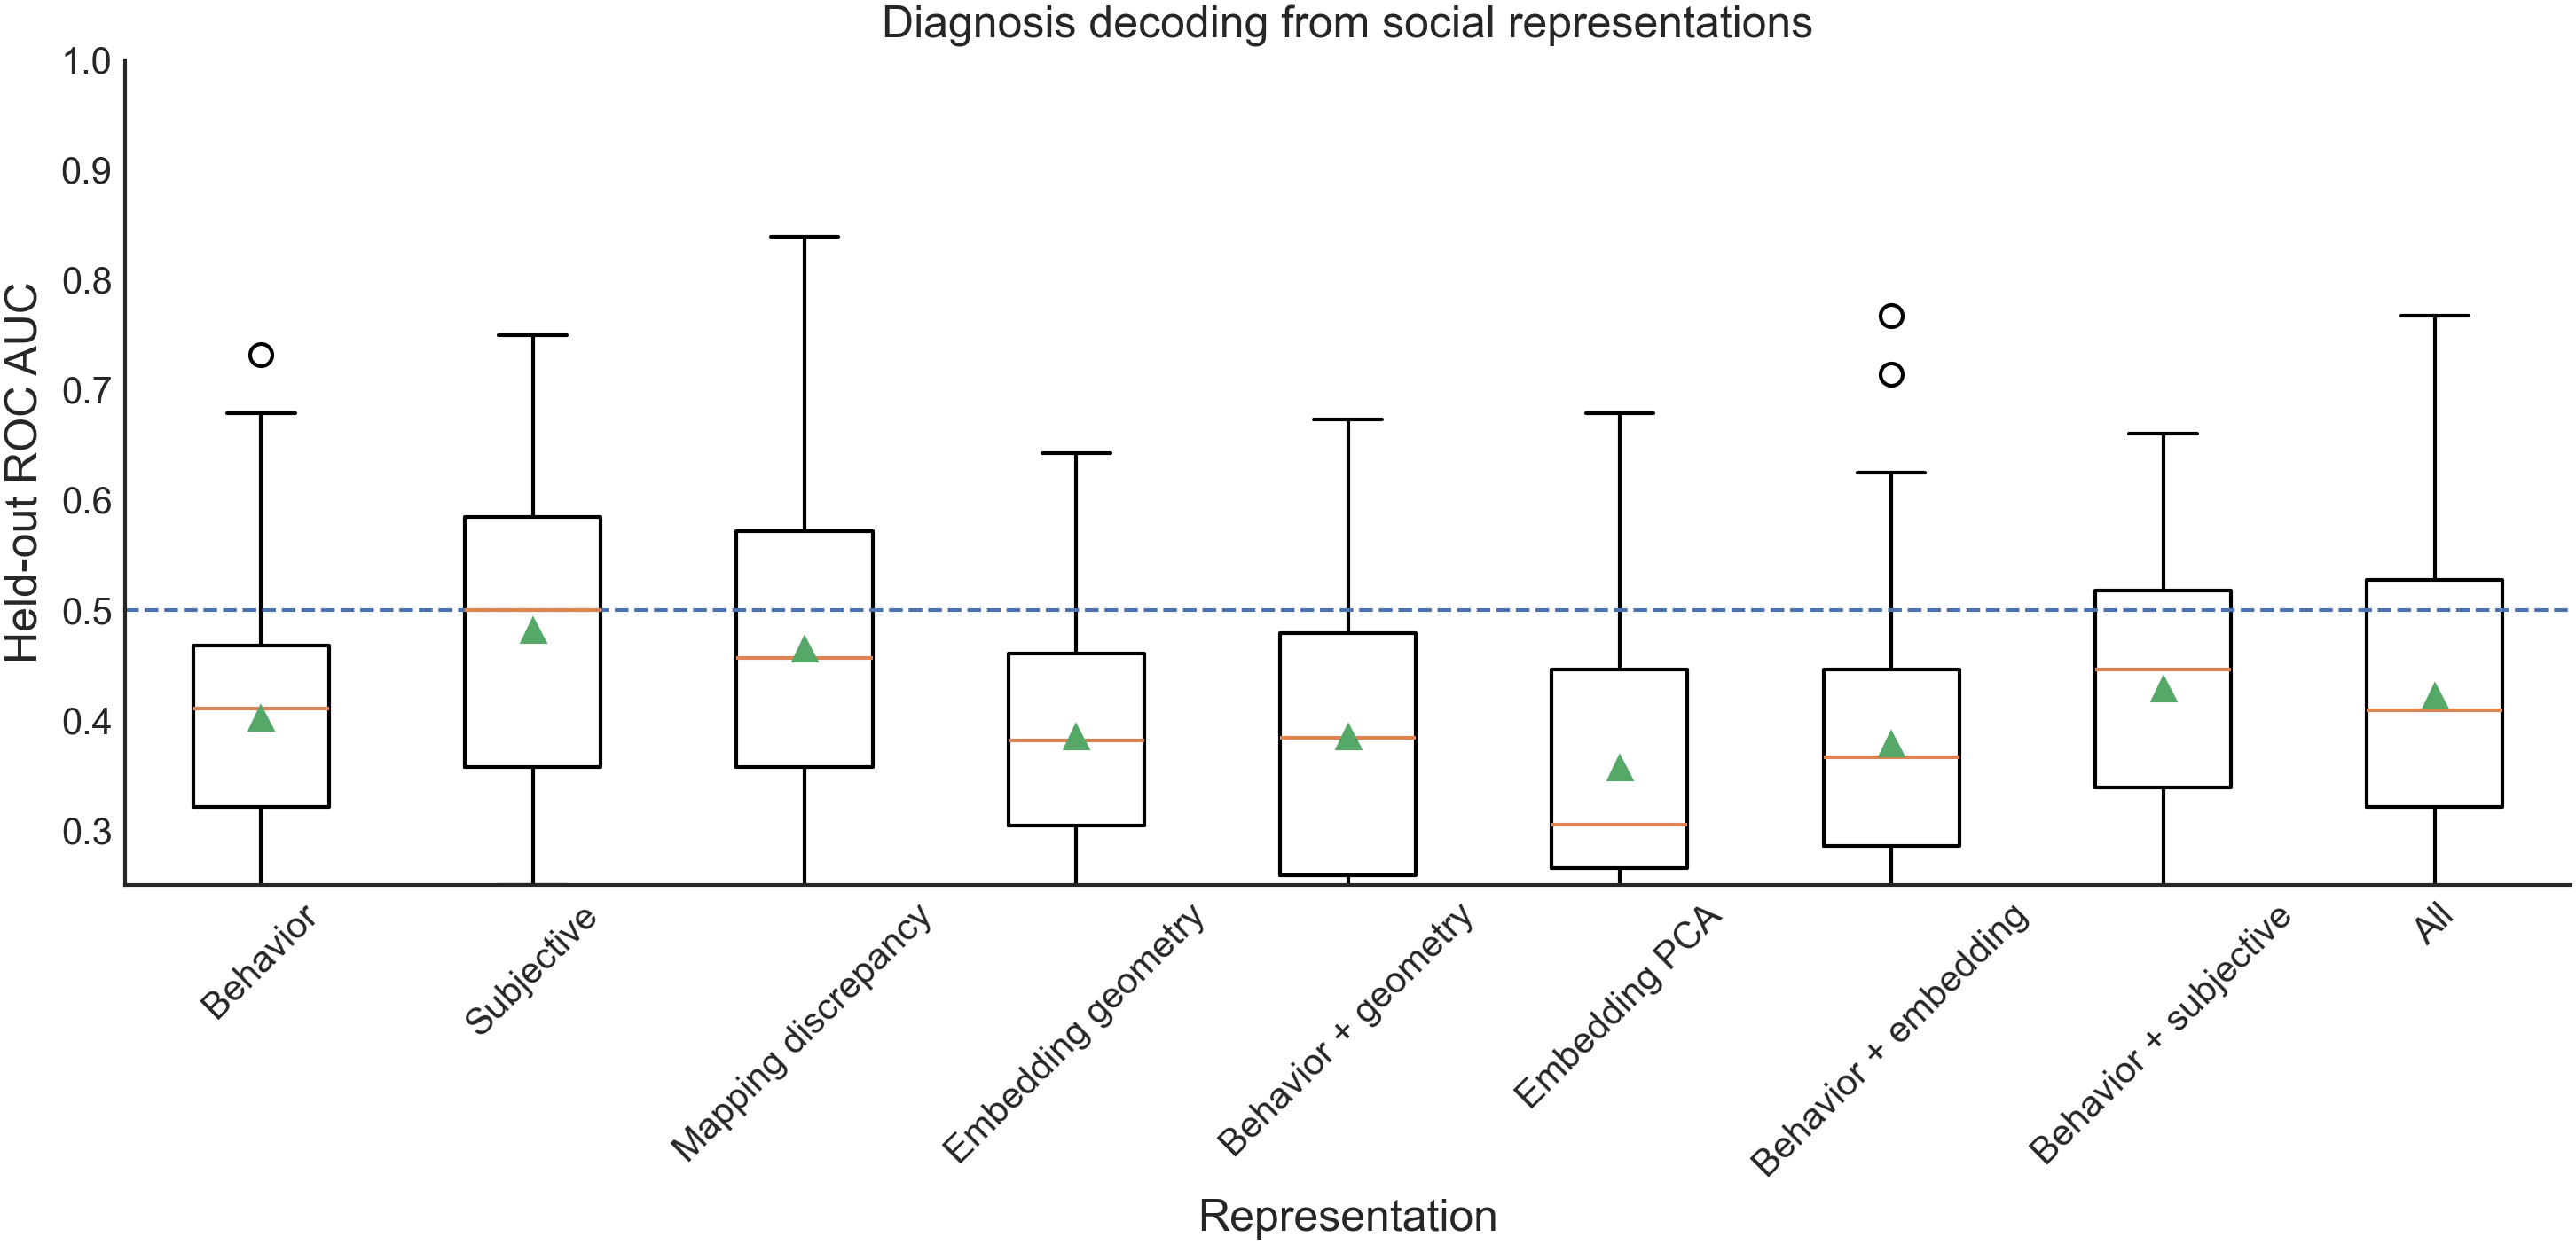

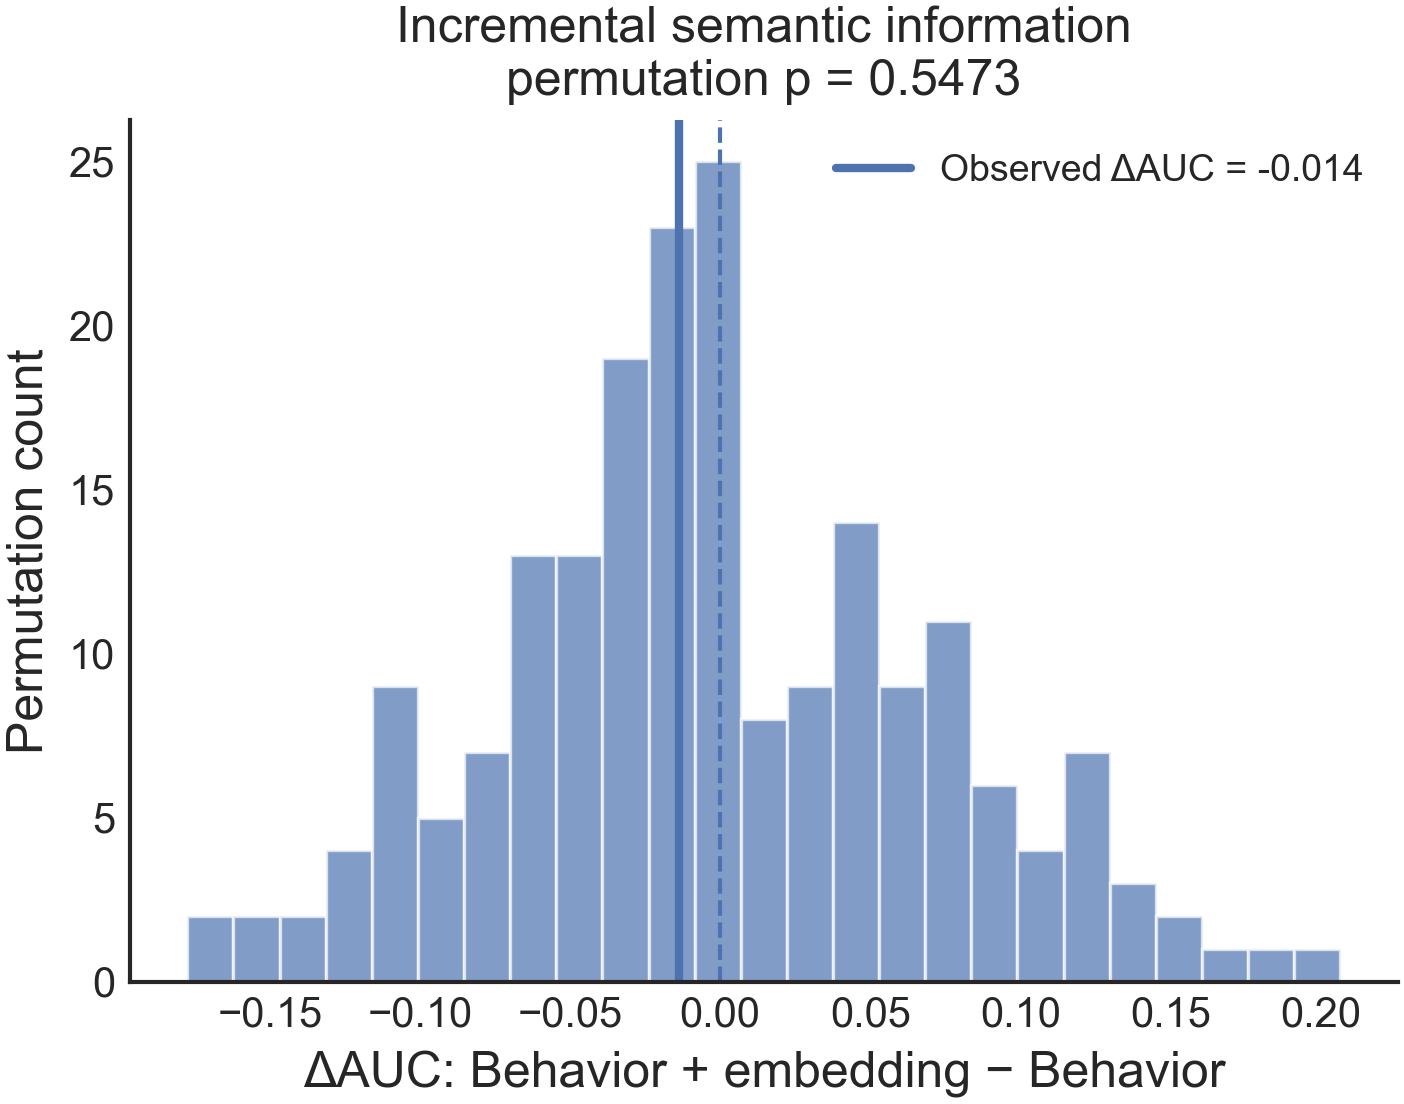

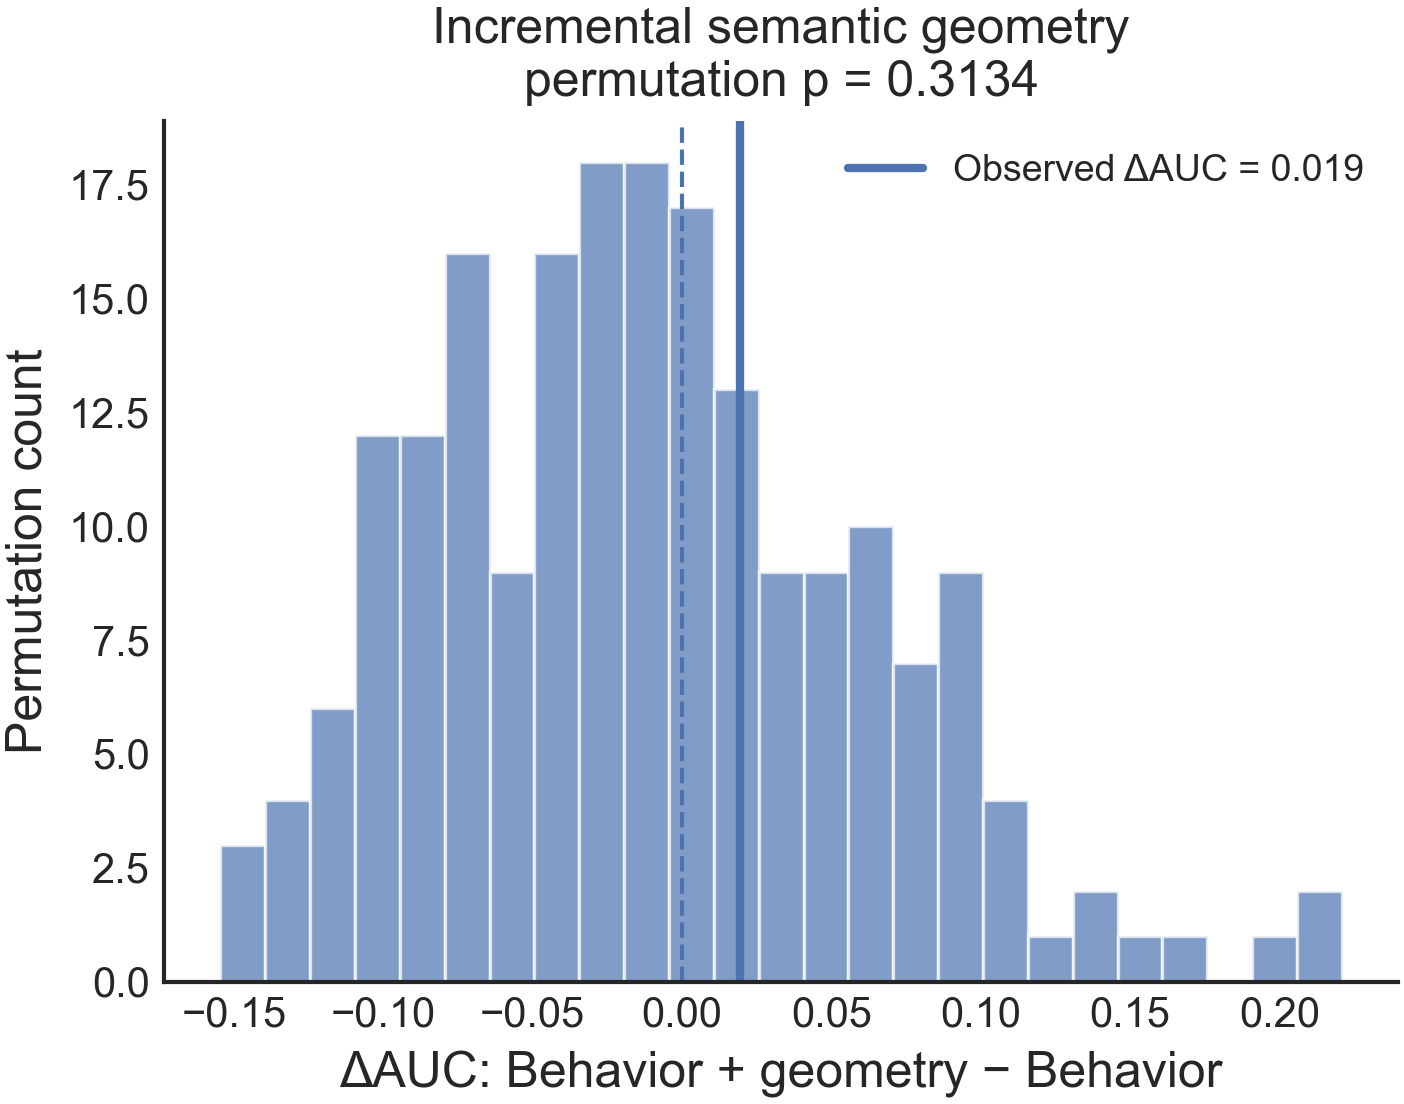

In [26]:
# =============================================================================
# DX DECODING FROM SOCIAL REPRESENTATIONS
# =============================================================================

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
)


# =============================================================================
# SETTINGS
# =============================================================================

DX_COL = "dx"

N_SPLITS = 5
N_REPEATS = 10
RANDOM_STATE = 42

# Keep embedding dimensionality modest for this first-pass analysis.
N_EMBED_PCS = 10

# Start here for speed. Increase to 1000+ for final inference.
N_PERM = 200


# =============================================================================
# PREPARE OUTCOME
# =============================================================================

keep = data_incl[DX_COL].notna().to_numpy()

data_dx = (
    data_incl
    .loc[keep]
    .reset_index(drop=True)
    .copy()
)

behavior = np.asarray(
    behavioral_locations[keep],
    dtype=float,
)

subjective = np.asarray(
    subjective_locations[keep],
    dtype=float,
)

embedding = np.asarray(
    embedding_locations[keep],
    dtype=float,
)

# Encode diagnosis as 0/1.
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    data_dx[DX_COL].astype(str)
)

if len(label_encoder.classes_) != 2:
    raise ValueError(
        f"{DX_COL!r} must contain exactly two classes; "
        f"found {label_encoder.classes_.tolist()}."
    )

print("DX encoding:")
for value, label in enumerate(label_encoder.classes_):
    print(f"  {value}: {label}")

print("\nN =", len(y))
print(
    "Class counts:",
    dict(
        zip(
            label_encoder.classes_,
            np.bincount(y),
        )
    ),
)


# =============================================================================
# VALIDATE INPUTS
# =============================================================================

arrays_to_check = {
    "behavior": behavior,
    "subjective": subjective,
    "embedding": embedding,
}

for name, values in arrays_to_check.items():
    if len(values) != len(y):
        raise ValueError(
            f"{name}: {len(values)} rows, "
            f"but y has {len(y)}."
        )

    if not np.isfinite(values).all():
        raise ValueError(
            f"{name} contains NaN or infinite values."
        )


# =============================================================================
# FEATURE CONSTRUCTION
# =============================================================================

# -------------------------------------------------------------------------
# 1. Behavioral social-space locations
#
# participants × characters × 2
#       ->
# participants × 10
# -------------------------------------------------------------------------

X_behavior = behavior.reshape(
    len(y),
    -1,
)


# -------------------------------------------------------------------------
# 2. Subjective social-space locations
# -------------------------------------------------------------------------

X_subjective = subjective.reshape(
    len(y),
    -1,
)


# -------------------------------------------------------------------------
# 3. Behavioral-subjective discrepancy
# -------------------------------------------------------------------------

X_mapping_discrepancy = (
    subjective - behavior
).reshape(
    len(y),
    -1,
)


# -------------------------------------------------------------------------
# 4. Semantic geometry between characters
#
# 5 characters -> 10 unique pairwise cosine distances.
#
# This asks whether the RELATIVE semantic arrangement of the characters
# contains diagnostic information.
# -------------------------------------------------------------------------

def character_cosine_geometry(
    subject_embeddings,
):
    """
    Return upper-triangle cosine distances among character embeddings.

    Input
    -----
    subject_embeddings : characters × embedding_dims

    Output
    ------
    1D vector of pairwise distances.
    """
    subject_embeddings = np.asarray(
        subject_embeddings,
        dtype=float,
    )

    norms = np.linalg.norm(
        subject_embeddings,
        axis=1,
        keepdims=True,
    )

    if np.any(norms <= 0):
        raise ValueError(
            "Encountered a zero-length character embedding."
        )

    normalized = (
        subject_embeddings
        / norms
    )

    cosine_similarity = (
        normalized
        @ normalized.T
    )

    cosine_distance = (
        1.0
        - cosine_similarity
    )

    upper = np.triu_indices(
        len(subject_embeddings),
        k=1,
    )

    return cosine_distance[upper]


X_embedding_geometry = np.stack(
    [
        character_cosine_geometry(
            subject_embeddings
        )
        for subject_embeddings
        in embedding
    ]
)


# -------------------------------------------------------------------------
# 5. Full character embeddings
#
# Concatenate the 5 character representations.
# PCA will happen INSIDE cross-validation.
# -------------------------------------------------------------------------

X_embedding = embedding.reshape(
    len(y),
    -1,
)


print("\nFEATURE SHAPES")
print(
    "Behavior:",
    X_behavior.shape,
)
print(
    "Subjective:",
    X_subjective.shape,
)
print(
    "Mapping discrepancy:",
    X_mapping_discrepancy.shape,
)
print(
    "Embedding geometry:",
    X_embedding_geometry.shape,
)
print(
    "Full embeddings:",
    X_embedding.shape,
)


# =============================================================================
# MODEL BUILDERS
# =============================================================================

def make_logistic():
    """
    Simple L2-regularized binary classifier.
    """
    return LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE,
    )


def make_low_dim_model():
    """
    Standard model for compact feature sets.
    """
    return Pipeline(
        [
            (
                "scale",
                StandardScaler(),
            ),
            (
                "classifier",
                make_logistic(),
            ),
        ]
    )


def make_embedding_model(
    n_components=N_EMBED_PCS,
):
    """
    Embedding classifier.

    IMPORTANT:
    PCA is inside the pipeline, so it is fit using training subjects only.
    """
    return Pipeline(
        [
            (
                "scale",
                StandardScaler(),
            ),
            (
                "pca",
                PCA(
                    n_components=n_components,
                    svd_solver="randomized",
                    random_state=RANDOM_STATE,
                ),
            ),
            (
                "classifier",
                make_logistic(),
            ),
        ]
    )


def make_low_plus_embedding_model(
    n_low_features,
    n_components=N_EMBED_PCS,
):
    """
    Process low-dimensional features directly and embeddings through PCA.
    """
    low_slice = slice(
        0,
        n_low_features,
    )

    embedding_slice = slice(
        n_low_features,
        None,
    )

    preprocessing = ColumnTransformer(
        [
            (
                "low_dim",
                StandardScaler(),
                low_slice,
            ),
            (
                "embedding",
                Pipeline(
                    [
                        (
                            "scale",
                            StandardScaler(),
                        ),
                        (
                            "pca",
                            PCA(
                                n_components=n_components,
                                svd_solver="randomized",
                                random_state=RANDOM_STATE,
                            ),
                        ),
                    ]
                ),
                embedding_slice,
            ),
        ],
        remainder="drop",
    )

    return Pipeline(
        [
            (
                "features",
                preprocessing,
            ),
            (
                "classifier",
                make_logistic(),
            ),
        ]
    )


# =============================================================================
# DEFINE FEATURE SETS / MODELS
# =============================================================================

X_behavior_geometry = np.column_stack(
    [
        X_behavior,
        X_embedding_geometry,
    ]
)

X_behavior_subjective = np.column_stack(
    [
        X_behavior,
        X_subjective,
    ]
)

X_behavior_embedding = np.column_stack(
    [
        X_behavior,
        X_embedding,
    ]
)

X_all = np.column_stack(
    [
        X_behavior,
        X_subjective,
        X_embedding,
    ]
)


model_specs = {
    "Behavior": {
        "X": X_behavior,
        "model": make_low_dim_model(),
    },

    "Subjective": {
        "X": X_subjective,
        "model": make_low_dim_model(),
    },

    "Mapping discrepancy": {
        "X": X_mapping_discrepancy,
        "model": make_low_dim_model(),
    },

    "Embedding geometry": {
        "X": X_embedding_geometry,
        "model": make_low_dim_model(),
    },

    "Behavior + geometry": {
        "X": X_behavior_geometry,
        "model": make_low_dim_model(),
    },

    "Embedding PCA": {
        "X": X_embedding,
        "model": make_embedding_model(),
    },

    "Behavior + embedding": {
        "X": X_behavior_embedding,
        "model": make_low_plus_embedding_model(
            n_low_features=X_behavior.shape[1],
        ),
    },

    "Behavior + subjective": {
        "X": X_behavior_subjective,
        "model": make_low_dim_model(),
    },

    "All": {
        "X": X_all,
        "model": make_low_plus_embedding_model(
            n_low_features=(
                X_behavior.shape[1]
                + X_subjective.shape[1]
            ),
        ),
    },
}


# =============================================================================
# CROSS-VALIDATION
# =============================================================================

def evaluate_model(
    X,
    y,
    model,
    splits,
):
    """
    Return held-out ROC AUC for every CV split.
    """
    scores = []

    for train_idx, test_idx in splits:

        estimator = clone(model)

        estimator.fit(
            X[train_idx],
            y[train_idx],
        )

        probability = estimator.predict_proba(
            X[test_idx]
        )[:, 1]

        auc = roc_auc_score(
            y[test_idx],
            probability,
        )

        scores.append(
            auc
        )

    return np.asarray(
        scores,
        dtype=float,
    )


# Use EXACTLY the same outer folds for every representation.
cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE,
)

cv_splits = list(
    cv.split(
        np.zeros(len(y)),
        y,
    )
)


cv_results = {}

for name, spec in model_specs.items():

    print(
        f"Running: {name}"
    )

    scores = evaluate_model(
        X=spec["X"],
        y=y,
        model=spec["model"],
        splits=cv_splits,
    )

    cv_results[name] = scores


# =============================================================================
# SUMMARIZE
# =============================================================================

summary_rows = []

for name, scores in cv_results.items():

    summary_rows.append(
        {
            "model": name,
            "mean_auc": scores.mean(),
            "sd_auc": scores.std(ddof=1),
            "min_auc": scores.min(),
            "max_auc": scores.max(),
        }
    )

summary = pd.DataFrame(
    summary_rows
).sort_values(
    "mean_auc",
    ascending=False,
).reset_index(
    drop=True
)


print("\nCROSS-VALIDATED DECODING")
print(
    summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}",
    )
)


# =============================================================================
# PAIRED INCREMENTAL EFFECTS
# =============================================================================

# Because all models used exactly the same repeated folds,
# split-wise differences are directly paired.

delta_geometry = (
    cv_results["Behavior + geometry"]
    - cv_results["Behavior"]
)

delta_embedding = (
    cv_results["Behavior + embedding"]
    - cv_results["Behavior"]
)

delta_subjective = (
    cv_results["Behavior + subjective"]
    - cv_results["Behavior"]
)


print("\nINCREMENTAL AUC")

print(
    "Behavior + geometry - Behavior:",
    f"{delta_geometry.mean():.3f}",
)

print(
    "Behavior + embedding - Behavior:",
    f"{delta_embedding.mean():.3f}",
)

print(
    "Behavior + subjective - Behavior:",
    f"{delta_subjective.mean():.3f}",
)


# =============================================================================
# PERMUTATION TEST
#
# For speed, inference uses one stratified 5-fold CV rather than the
# repeated-CV procedure above.
#
# This produces:
#   1. p-values for individual model decoding
#   2. p-values for incremental information above behavior
#
# Increase N_PERM for final analyses.
# =============================================================================

primary_models = [
    "Behavior",
    "Subjective",
    "Embedding geometry",
    "Behavior + geometry",
    "Embedding PCA",
    "Behavior + embedding",
]


def make_5fold_splits(
    y_values,
    random_state=RANDOM_STATE,
):
    cv = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=random_state,
    )

    return list(
        cv.split(
            np.zeros(len(y_values)),
            y_values,
        )
    )


# -------------------------------------------------------------------------
# Observed statistic
# -------------------------------------------------------------------------

observed_splits = make_5fold_splits(
    y
)

observed_auc = {}

for name in primary_models:

    spec = model_specs[name]

    observed_auc[name] = evaluate_model(
        X=spec["X"],
        y=y,
        model=spec["model"],
        splits=observed_splits,
    ).mean()


observed_delta_geometry = (
    observed_auc["Behavior + geometry"]
    - observed_auc["Behavior"]
)

observed_delta_embedding = (
    observed_auc["Behavior + embedding"]
    - observed_auc["Behavior"]
)


# -------------------------------------------------------------------------
# Permute dx labels
# -------------------------------------------------------------------------

rng = np.random.default_rng(
    RANDOM_STATE
)

null_auc = {
    name: np.zeros(
        N_PERM,
        dtype=float,
    )
    for name in primary_models
}

null_delta_geometry = np.zeros(
    N_PERM,
    dtype=float,
)

null_delta_embedding = np.zeros(
    N_PERM,
    dtype=float,
)


for permutation in range(N_PERM):

    if (
        permutation % 25 == 0
        or permutation == N_PERM - 1
    ):
        print(
            f"Permutation "
            f"{permutation + 1}/{N_PERM}"
        )

    y_perm = rng.permutation(
        y
    )

    perm_splits = make_5fold_splits(
        y_perm,
        random_state=(
            RANDOM_STATE
            + permutation
            + 1
        ),
    )

    current_auc = {}

    for name in primary_models:

        spec = model_specs[name]

        current_auc[name] = evaluate_model(
            X=spec["X"],
            y=y_perm,
            model=spec["model"],
            splits=perm_splits,
        ).mean()

        null_auc[name][
            permutation
        ] = current_auc[name]

    null_delta_geometry[
        permutation
    ] = (
        current_auc["Behavior + geometry"]
        - current_auc["Behavior"]
    )

    null_delta_embedding[
        permutation
    ] = (
        current_auc["Behavior + embedding"]
        - current_auc["Behavior"]
    )


# =============================================================================
# PERMUTATION P-VALUES
# =============================================================================

def right_tailed_permutation_p(
    observed,
    null,
):
    return (
        1
        + np.sum(
            null >= observed
        )
    ) / (
        len(null) + 1
    )


permutation_rows = []

for name in primary_models:

    p_value = right_tailed_permutation_p(
        observed_auc[name],
        null_auc[name],
    )

    permutation_rows.append(
        {
            "model": name,
            "observed_auc": observed_auc[name],
            "null_mean": null_auc[name].mean(),
            "p_perm": p_value,
        }
    )


permutation_summary = pd.DataFrame(
    permutation_rows
)

print("\nPERMUTATION TESTS: DECODING")
print(
    permutation_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}",
    )
)


p_delta_geometry = right_tailed_permutation_p(
    observed_delta_geometry,
    null_delta_geometry,
)

p_delta_embedding = right_tailed_permutation_p(
    observed_delta_embedding,
    null_delta_embedding,
)


print("\nPERMUTATION TESTS: INCREMENTAL INFORMATION")

print(
    "Behavior + geometry > Behavior:"
)
print(
    f"  ΔAUC = {observed_delta_geometry:.3f}"
)
print(
    f"  p = {p_delta_geometry:.4f}"
)

print(
    "\nBehavior + embedding > Behavior:"
)
print(
    f"  ΔAUC = {observed_delta_embedding:.3f}"
)
print(
    f"  p = {p_delta_embedding:.4f}"
)


# =============================================================================
# PLOT 1: CROSS-VALIDATED DECODING PERFORMANCE
# =============================================================================

plot_order = [
    "Behavior",
    "Subjective",
    "Mapping discrepancy",
    "Embedding geometry",
    "Behavior + geometry",
    "Embedding PCA",
    "Behavior + embedding",
    "Behavior + subjective",
    "All",
]


fig, ax = plt.subplots(
    figsize=(10, 5),
)

plot_data = [
    cv_results[name]
    for name in plot_order
]

box = ax.boxplot(
    plot_data,
    labels=plot_order,
    showmeans=True,
    meanline=False,
)

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
)

ax.set_ylabel(
    "Held-out ROC AUC"
)

ax.set_xlabel(
    "Representation"
)

ax.set_title(
    "Diagnosis decoding from social representations"
)

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.set_ylim(
    0.25,
    1.0,
)

plt.tight_layout()
plt.show()


# =============================================================================
# PLOT 2: DOES THE FULL EMBEDDING ADD INFORMATION ABOVE BEHAVIOR?
# =============================================================================

fig, ax = plt.subplots(
    figsize=(5, 4),
)

ax.hist(
    null_delta_embedding,
    bins=25,
    alpha=0.7,
)

ax.axvline(
    observed_delta_embedding,
    linewidth=2,
    label=(
        f"Observed ΔAUC = "
        f"{observed_delta_embedding:.3f}"
    ),
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(
    "ΔAUC: Behavior + embedding − Behavior"
)

ax.set_ylabel(
    "Permutation count"
)

ax.set_title(
    f"Incremental semantic information\n"
    f"permutation p = {p_delta_embedding:.4f}"
)

ax.legend(
    frameon=False
)

plt.tight_layout()
plt.show()


# =============================================================================
# PLOT 3: DOES EMBEDDING GEOMETRY ADD INFORMATION ABOVE BEHAVIOR?
# =============================================================================

fig, ax = plt.subplots(
    figsize=(5, 4),
)

ax.hist(
    null_delta_geometry,
    bins=25,
    alpha=0.7,
)

ax.axvline(
    observed_delta_geometry,
    linewidth=2,
    label=(
        f"Observed ΔAUC = "
        f"{observed_delta_geometry:.3f}"
    ),
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel(
    "ΔAUC: Behavior + geometry − Behavior"
)

ax.set_ylabel(
    "Permutation count"
)

ax.set_title(
    f"Incremental semantic geometry\n"
    f"permutation p = {p_delta_geometry:.4f}"
)

ax.legend(
    frameon=False
)

plt.tight_layout()
plt.show()